In [1]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import glob

# Initialize BigQuery client
PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "hcm_analysis_scratch_updated"

client = bigquery.Client(project=PROJECT_ID)

# Create scratch dataset if it doesn't exist
scratch_dataset_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}"
scratch_dataset = bigquery.Dataset(scratch_dataset_id)
scratch_dataset.location = "US"

try:
    scratch_dataset = client.create_dataset(scratch_dataset, timeout=30)
    print(f" Created scratch dataset: {scratch_dataset_id}")
except Exception as e:
    if "Already Exists" in str(e):
        print(f" Scratch dataset already exists: {scratch_dataset_id}")
    else:
        print(f" Error creating dataset: {e}")
        
print(f"Working Configuration:")
print(f"  Project: {PROJECT_ID}")
print(f"  Scratch Dataset: {SCRATCH_DATASET_ID}")
print(f"  Location: US")

 Scratch dataset already exists: nb-tre-dev-2-483522.hcm_analysis_scratch_updated
Working Configuration:
  Project: nb-tre-dev-2-483522
  Scratch Dataset: hcm_analysis_scratch_updated
  Location: US


In [7]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import os

# 1. Load HCM diagnosis data (both carriers and non-carriers)
print(" Loading: age_at_hcm_diagnosis_three_groups.tsv")
df_hcm_diagnosis = pd.read_csv('/home/jupyter/Invitae_HCM/age_at_hcm_diagnosis_three_groups.tsv', sep='\t')
print(f"   Loaded: {len(df_hcm_diagnosis):,} rows, {len(df_hcm_diagnosis.columns)} columns")
print(f"   Columns: {list(df_hcm_diagnosis.columns)}")
print(f"   Cohort types: {df_hcm_diagnosis['cohort_type'].unique().tolist()}")

print("\n   Breakdown by cohort:")
cohort_counts = df_hcm_diagnosis.groupby('cohort_type').size()
for cohort, count in cohort_counts.items():
    print(f"     - {cohort}: {count}")

# 2. Load PRS scores for HCM cohort
print("\nLoading: prs_scores_hcm_cohort.tsv")
df_prs_hcm = pd.read_csv('/home/jupyter/prs_output/prs_scores_hcm_cohort.tsv', sep='\t')
print(f"   Loaded: {len(df_prs_hcm):,} rows, {len(df_prs_hcm.columns)} columns")
print(f"   Columns: {list(df_prs_hcm.columns)}")

# Rename IID to person_id, PRS to prs
df_prs_hcm = df_prs_hcm.rename(columns={'IID': 'person_id', 'PRS': 'prs'})
print(f"   Standardized columns to: {list(df_prs_hcm.columns)}")

# 3. Load variant information for HCM carriers
print("\n Loading: hcm_carriers_long_format.tsv")
df_hcm_variants = pd.read_csv('/home/jupyter/Invitae_HCM/hcm_carriers_long_format.tsv', sep='\t')
print(f"   Loaded: {len(df_hcm_variants):,} rows, {len(df_hcm_variants.columns)} columns")
print(f"   Columns: {list(df_hcm_variants.columns)}")
print(f"   Unique persons with variants: {df_hcm_variants['IID'].nunique()}")

#Rename IID to person_id
df_hcm_variants = df_hcm_variants.rename(columns={'IID': 'person_id'})
print(f"   Standardized columns to: {list(df_hcm_variants.columns)}")


# Do we have exactly 46 HCM Carriers?
n_hcm_carriers = len(df_hcm_diagnosis[df_hcm_diagnosis['cohort_type'] == 'HCM Cohort - Carriers'])
print(f" HCM Carriers in diagnosis file: {n_hcm_carriers} (expected: 46)")

# Do we have HCM Non-Carriers?
n_hcm_noncarriers = len(df_hcm_diagnosis[df_hcm_diagnosis['cohort_type'] == 'HCM Cohort - Non-Carriers'])
print(f"HCM Non-Carriers in diagnosis file: {n_hcm_noncarriers}")

# How many persons in variants file?
n_persons_with_variants = df_hcm_variants['person_id'].nunique()
print(f"Unique persons with variants: {n_persons_with_variants} (expected: 46)")

# Do all HCM Carriers have PRS scores?
hcm_carrier_ids = df_hcm_diagnosis[df_hcm_diagnosis['cohort_type'] == 'HCM Cohort - Carriers']['person_id'].unique()
prs_ids = df_prs_hcm['person_id'].unique()
n_carriers_with_prs = len(set(hcm_carrier_ids) & set(prs_ids))
print(f" HCM Carriers with PRS scores: {n_carriers_with_prs}/{n_hcm_carriers}")

# Do all HCM Non-Carriers have PRS scores?
hcm_noncarrier_ids = df_hcm_diagnosis[df_hcm_diagnosis['cohort_type'] == 'HCM Cohort - Non-Carriers']['person_id'].unique()
n_noncarriers_with_prs = len(set(hcm_noncarrier_ids) & set(prs_ids))
print(f" HCM Non-Carriers with PRS scores: {n_noncarriers_with_prs}/{n_hcm_noncarriers}")

# Missing data check
print(f"\nMissing data check:")
print(f"   - Diagnosis file missing age_at_diagnosis: {df_hcm_diagnosis['age_at_diagnosis'].isna().sum()}")
print(f"   - PRS file missing prs: {df_prs_hcm['prs'].isna().sum()}")
print(f"   - Variants file missing Gene: {df_hcm_variants['Gene'].isna().sum()}")


print("Uploading DFs to BigQuery...\n")

def upload_dataframe_to_bq(df, table_name, dataset_id, project_id):
    """Upload a pandas DataFrame to BigQuery"""
    table_id = f"{project_id}.{dataset_id}.{table_name}"
    
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",  # Overwrite if exists
        autodetect=True  # Auto-detect schema
    )
    
    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result() 
    
    table = client.get_table(table_id)
    print(f"    Uploaded to BigQuery: {table.num_rows:,} rows")
    return table_id


 Loading: age_at_hcm_diagnosis_three_groups.tsv
   Loaded: 475 rows, 8 columns
   Columns: ['person_id', 'first_hcm_date', 'first_hcm_code', 'birth_datetime', 'age_at_diagnosis', 'gender_concept_id', 'cohort_type', 'group_order']
   Cohort types: ['HCM Cohort - Carriers', 'HCM Cohort - Non-Carriers', 'General Population - Carriers']

   Breakdown by cohort:
     - General Population - Carriers: 144
     - HCM Cohort - Carriers: 46
     - HCM Cohort - Non-Carriers: 285

Loading: prs_scores_hcm_cohort.tsv
   Loaded: 331 rows, 3 columns
   Columns: ['FID', 'IID', 'PRS']
   Standardized columns to: ['FID', 'person_id', 'prs']

 Loading: hcm_carriers_long_format.tsv
   Loaded: 47 rows, 6 columns
   Columns: ['Gene', 'IID', 'FID', 'variant_id', 'dosage', 'genotype']
   Unique persons with variants: 46
   Standardized columns to: ['Gene', 'person_id', 'FID', 'variant_id', 'dosage', 'genotype']
 HCM Carriers in diagnosis file: 46 (expected: 46)
HCM Non-Carriers in diagnosis file: 285
Unique pe

In [8]:
# HCM diagnosis data
print("Uploading: age_hcm_diagnosis_three_groups")
table_id_diagnosis = upload_dataframe_to_bq(
    df_hcm_diagnosis,
    'age_hcm_diagnosis_three_groups',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)

#  PRS scores 
print("\n Uploading: prs_scores_hcm")
table_id_prs = upload_dataframe_to_bq(
    df_prs_hcm,
    'prs_scores_hcm',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)

# HCM carrier variants
print("\n Uploading: hcm_carriers_variants")
table_id_variants = upload_dataframe_to_bq(
    df_hcm_variants,
    'hcm_carriers_variants',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)


# Check HCM diagnosis breakdown
verify_diagnosis_query = f"""
SELECT 
  cohort_type,
  COUNT(*) as n,
  COUNT(DISTINCT person_id) as n_unique_persons,
  ROUND(AVG(age_at_diagnosis), 2) as avg_age_diagnosis,
  SUM(CASE WHEN gender_concept_id = 8507 THEN 1 ELSE 0 END) as n_male,
  SUM(CASE WHEN gender_concept_id = 8532 THEN 1 ELSE 0 END) as n_female
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.age_hcm_diagnosis_three_groups`
WHERE cohort_type IN ('HCM Cohort - Carriers', 'HCM Cohort - Non-Carriers')
GROUP BY cohort_type
ORDER BY cohort_type
"""

result = client.query(verify_diagnosis_query).to_dataframe()
print(" HCM Diagnosis Data (Carriers vs Non-Carriers only):")
print(result.to_string(index=False))

# Check PRS data
verify_prs_query = f"""
SELECT 
  COUNT(*) as n,
  COUNT(DISTINCT person_id) as n_unique_persons,
  ROUND(AVG(prs), 4) as avg_prs,
  ROUND(STDDEV(prs), 4) as stddev_prs,
  ROUND(MIN(prs), 4) as min_prs,
  ROUND(MAX(prs), 4) as max_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.prs_scores_hcm`
"""

result = client.query(verify_prs_query).to_dataframe()
print("\n PRS Scores Summary:")
print(result.to_string(index=False))

# Check variants data
verify_variants_query = f"""
SELECT 
  COUNT(*) as n_rows,
  COUNT(DISTINCT person_id) as n_persons_with_variants,
  COUNT(DISTINCT variant_id) as n_unique_variants,
  COUNT(DISTINCT Gene) as n_unique_genes
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_carriers_variants`
"""

result = client.query(verify_variants_query).to_dataframe()
print("\n Variant Data Summary:")
print(result.to_string(index=False))

print("\n Summary:")
print(f"   - HCM Carriers ready: {n_hcm_carriers}")
print(f"   - HCM Non-Carriers ready: {n_hcm_noncarriers}")
print(f"   - Total HCM cohort: {n_hcm_carriers + n_hcm_noncarriers}")

Uploading: age_hcm_diagnosis_three_groups
    Uploaded to BigQuery: 475 rows

 Uploading: prs_scores_hcm
    Uploaded to BigQuery: 331 rows

 Uploading: hcm_carriers_variants
    Uploaded to BigQuery: 47 rows
 HCM Diagnosis Data (Carriers vs Non-Carriers only):
              cohort_type   n  n_unique_persons  avg_age_diagnosis  n_male  n_female
    HCM Cohort - Carriers  46                46              43.04      23        23
HCM Cohort - Non-Carriers 285               285              53.89     152       133

 PRS Scores Summary:
  n  n_unique_persons  avg_prs  stddev_prs  min_prs  max_prs
331               331  -3.7097      0.6935  -5.5899  -1.0817

 Variant Data Summary:
 n_rows  n_persons_with_variants  n_unique_variants  n_unique_genes
     47                       46                 29               3

 Summary:
   - HCM Carriers ready: 46
   - HCM Non-Carriers ready: 285
   - Total HCM cohort: 331


In [9]:
print("Create HCM Carriers cohort table\n")

create_carriers_cohort_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers` AS

WITH carrier_variants AS (
  -- Get all variants for each carrier (one row per person-variant)
  SELECT 
    person_id,
    Gene,
    variant_id,
    dosage,
    genotype
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_carriers_variants`
),

carrier_variant_summary AS (
  -- Summarize variants per person
  SELECT 
    person_id,
    COUNT(DISTINCT variant_id) as n_variants,
    -- Concatenate all genes (in case someone has variants in multiple genes)
    STRING_AGG(DISTINCT Gene, ', ' ORDER BY Gene) as genes,
    -- Concatenate all variant IDs
    STRING_AGG(variant_id, '; ' ORDER BY variant_id) as variant_list
  FROM carrier_variants
  GROUP BY person_id
)

SELECT 
  d.person_id,
  d.first_hcm_date,
  d.age_at_diagnosis,
  d.birth_datetime,
  d.gender_concept_id,
  CASE 
    WHEN d.gender_concept_id = 8507 THEN 'Male'
    WHEN d.gender_concept_id = 8532 THEN 'Female'
    ELSE 'Other/Unknown'
  END as gender,
  
  -- PRS information
  p.prs,
  
  -- Variant information
  v.n_variants,
  v.genes,
  v.variant_list,
  
  -- Cohort identifier
  'HCM Carrier' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.age_hcm_diagnosis_three_groups` d

LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.prs_scores_hcm` p
  ON d.person_id = p.person_id

LEFT JOIN carrier_variant_summary v
  ON d.person_id = v.person_id

WHERE d.cohort_type = 'HCM Cohort - Carriers'
  AND p.prs IS NOT NULL  -- Ensure we have PRS score
  AND v.n_variants IS NOT NULL  -- Ensure we have variant info

ORDER BY d.age_at_diagnosis
"""

client.query(create_carriers_cohort_query).result()
print(" Created table: model1_hcm_carriers")

# Verify carriers table
verify_carriers_query = f"""
SELECT 
  COUNT(*) as n_total,
  COUNT(DISTINCT person_id) as n_unique_persons,
  ROUND(AVG(age_at_diagnosis), 2) as avg_age_diagnosis,
  ROUND(STDDEV(age_at_diagnosis), 2) as sd_age_diagnosis,
  ROUND(MIN(age_at_diagnosis), 2) as min_age,
  ROUND(MAX(age_at_diagnosis), 2) as max_age,
  SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) as n_male,
  SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) as n_female,
  ROUND(AVG(prs), 4) as avg_prs,
  ROUND(STDDEV(prs), 4) as sd_prs,
  ROUND(AVG(n_variants), 2) as avg_n_variants,
  ROUND(MAX(n_variants), 0) as max_n_variants
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
"""

result = client.query(verify_carriers_query).to_dataframe()
print("\n HCM Carriers Cohort Summary:")
print(result.to_string(index=False))

gene_dist_query = f"""
SELECT 
  genes,
  COUNT(*) as n_persons,
  ROUND(AVG(age_at_diagnosis), 2) as avg_age_diagnosis,
  ROUND(AVG(prs), 4) as avg_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
GROUP BY genes
ORDER BY n_persons DESC
"""

result = client.query(gene_dist_query).to_dataframe()
print("\n Carriers by Gene:")
print(result.to_string(index=False))


print("Create HCM Non-Carriers cohort table...\n")

create_noncarriers_cohort_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers` AS

SELECT 
  d.person_id,
  d.first_hcm_date,
  d.age_at_diagnosis,
  d.birth_datetime,
  d.gender_concept_id,
  CASE 
    WHEN d.gender_concept_id = 8507 THEN 'Male'
    WHEN d.gender_concept_id = 8532 THEN 'Female'
    ELSE 'Other/Unknown'
  END as gender,
  
  -- PRS information
  p.prs,
  
  -- No variant information for non-carriers (keep as INT64 to match carriers table)
  CAST(0 AS INT64) as n_variants,
  CAST(NULL AS STRING) as genes,
  CAST(NULL AS STRING) as variant_list,
  
  -- Cohort identifier
  'HCM Non-Carrier' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.age_hcm_diagnosis_three_groups` d

LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.prs_scores_hcm` p
  ON d.person_id = p.person_id

WHERE d.cohort_type = 'HCM Cohort - Non-Carriers'
  AND p.prs IS NOT NULL  -- Ensure we have PRS score

ORDER BY d.age_at_diagnosis
"""

client.query(create_noncarriers_cohort_query).result()
print(" Created table: model1_hcm_noncarriers")

verify_noncarriers_query = f"""
SELECT 
  COUNT(*) as n_total,
  COUNT(DISTINCT person_id) as n_unique_persons,
  ROUND(AVG(age_at_diagnosis), 2) as avg_age_diagnosis,
  ROUND(STDDEV(age_at_diagnosis), 2) as sd_age_diagnosis,
  ROUND(MIN(age_at_diagnosis), 2) as min_age,
  ROUND(MAX(age_at_diagnosis), 2) as max_age,
  SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) as n_male,
  SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) as n_female,
  ROUND(AVG(prs), 4) as avg_prs,
  ROUND(STDDEV(prs), 4) as sd_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
"""

result = client.query(verify_noncarriers_query).to_dataframe()
print("\n HCM Non-Carriers Cohort Summary:")
print(result.to_string(index=False))

print("Comparing Carriers vs Non-Carriers...\n")

comparison_query = f"""
SELECT 
  cohort,
  COUNT(*) as n,
  ROUND(AVG(age_at_diagnosis), 2) as avg_age_diagnosis,
  ROUND(STDDEV(age_at_diagnosis), 2) as sd_age_diagnosis,
  ROUND(MIN(age_at_diagnosis), 2) as min_age_diagnosis,
  ROUND(MAX(age_at_diagnosis), 2) as max_age_diagnosis,
  SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) as n_male,
  SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) as n_female,
  ROUND(AVG(prs), 4) as avg_prs,
  ROUND(STDDEV(prs), 4) as sd_prs,
  ROUND(MIN(prs), 4) as min_prs,
  ROUND(MAX(prs), 4) as max_prs
FROM (
  SELECT 
    person_id, 
    age_at_diagnosis, 
    gender, 
    prs, 
    cohort
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id, 
    age_at_diagnosis, 
    gender, 
    prs, 
    cohort
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
)
GROUP BY cohort
ORDER BY cohort
"""

result = client.query(comparison_query).to_dataframe()
print(" Carriers vs Non-Carriers Comparison:")
print(result.to_string(index=False))

Create HCM Carriers cohort table

 Created table: model1_hcm_carriers

 HCM Carriers Cohort Summary:
 n_total  n_unique_persons  avg_age_diagnosis  sd_age_diagnosis  min_age  max_age  n_male  n_female  avg_prs  sd_prs  avg_n_variants  max_n_variants
      46                46              43.04             19.32     10.0     82.0      23        23  -3.6669  0.6887            1.02             2.0

 Carriers by Gene:
        genes  n_persons  avg_age_diagnosis  avg_prs
       MYBPC3         25              43.48  -3.5383
         MYH7         20              43.65  -3.8185
ALPK3, MYBPC3          1              20.00  -3.8483
Create HCM Non-Carriers cohort table...

 Created table: model1_hcm_noncarriers

 HCM Non-Carriers Cohort Summary:
 n_total  n_unique_persons  avg_age_diagnosis  sd_age_diagnosis  min_age  max_age  n_male  n_female  avg_prs  sd_prs
     285               285              53.89             20.71      0.0     87.0     152       133  -3.7166  0.6953
Comparing Carriers v

In [15]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"
SCRATCH_DATASET_ID = "hcm_analysis_scratch_updated"

# PART 1: Search CONDITION concepts
search_condition_concepts_query = f"""
WITH hcm_cohort AS (
  -- Get all HCM patients (carriers + non-carriers)
  -- Cast first_hcm_date from STRING to DATE
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
),

cardiac_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([
    -- Heart Failure
    STRUCT('Heart failure' AS search_term, 'Heart Failure' AS event_category),
    STRUCT('Cardiac failure' AS search_term, 'Heart Failure' AS event_category),
    STRUCT('Congestive heart failure' AS search_term, 'Heart Failure' AS event_category),
    
    -- Ventricular Arrhythmias
    STRUCT('Ventricular tachycardia' AS search_term, 'Ventricular Arrhythmia' AS event_category),
    STRUCT('Ventricular fibrillation' AS search_term, 'Ventricular Arrhythmia' AS event_category),
    STRUCT('Cardiac arrest' AS search_term, 'Cardiac Arrest' AS event_category),
    STRUCT('Sudden cardiac death' AS search_term, 'Sudden Cardiac Death' AS event_category),
    
    -- Atrial Fibrillation
    STRUCT('Atrial fibrillation' AS search_term, 'Atrial Fibrillation' AS event_category),
    STRUCT('Atrial flutter' AS search_term, 'Atrial Fibrillation' AS event_category),
    
    -- Cardiogenic Shock
    STRUCT('Cardiogenic shock' AS search_term, 'Cardiogenic Shock' AS event_category),
    
    -- Stroke
    STRUCT('Stroke' AS search_term, 'Stroke' AS event_category),
    STRUCT('Cerebrovascular accident' AS search_term, 'Stroke' AS event_category),
    STRUCT('Cerebral infarction' AS search_term, 'Stroke' AS event_category)
  ])
),

cohort_conditions AS (
  -- Get conditions that occurred AFTER HCM diagnosis in our cohort
  SELECT 
    co.person_id,
    co.condition_concept_id,
    co.condition_start_date,
    hcm.first_hcm_date
  FROM `{OMOP_DATASET_ID}.condition_occurrence` co
  INNER JOIN hcm_cohort hcm
    ON co.person_id = hcm.person_id
  WHERE co.condition_start_date >= hcm.first_hcm_date  -- Only events AFTER HCM diagnosis
)

SELECT 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category,
  COUNT(DISTINCT cc.person_id) as n_hcm_persons_with_event,
  COUNT(*) as n_occurrences,
  MIN(DATE_DIFF(cc.condition_start_date, cc.first_hcm_date, DAY)) as min_days_after_hcm,
  ROUND(AVG(DATE_DIFF(cc.condition_start_date, cc.first_hcm_date, DAY)), 0) as avg_days_after_hcm,
  MAX(DATE_DIFF(cc.condition_start_date, cc.first_hcm_date, DAY)) as max_days_after_hcm
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN cardiac_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
INNER JOIN cohort_conditions cc
  ON c.concept_id = cc.condition_concept_id
WHERE c.domain_id = 'Condition'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
GROUP BY 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category
HAVING COUNT(DISTINCT cc.person_id) >= 1
ORDER BY 
  s.event_category,
  n_hcm_persons_with_event DESC,
  c.concept_name
"""

print(" Searching condition concepts in HCM cohort...\n")
conditions_df = client.query(search_condition_concepts_query).to_dataframe()

print(f" Found {len(conditions_df)} condition concepts occurring after HCM diagnosis\n")

# Print with better formatting
if len(conditions_df) > 0:
    for category in sorted(conditions_df['event_category'].unique()):
        cat_df = conditions_df[conditions_df['event_category'] == category]
        print(f"\n  {category.upper()} (n={len(cat_df)} concepts)")
        
        for _, row in cat_df.head(15).iterrows():
            print(f"  Concept ID: {row['concept_id']:>10} | "
                  f"N persons: {row['n_hcm_persons_with_event']:>5} | "
                  f"N events: {row['n_occurrences']:>6} | "
                  f"Avg days after HCM: {row['avg_days_after_hcm']:>6.0f} | "
                  f"{row['concept_name']}")
        
        if len(cat_df) > 15:
            print(f"  ... and {len(cat_df) - 15} more concepts")
else:
    print("    No condition concepts found!")

conditions_df.to_csv('cardiac_condition_concepts_hcm_cohort.csv', index=False)
print("\n Saved to: cardiac_condition_concepts_hcm_cohort.csv")

# Search procedure concepts

search_procedure_concepts_query = f"""
WITH hcm_cohort AS (
  -- Get all HCM patients (carriers + non-carriers)
  -- Cast first_hcm_date from STRING to DATE
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
),

procedure_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([
    -- ICD/Device Implantation
    STRUCT('defibrillator' AS search_term, 'ICD Implantation' AS event_category),
    STRUCT('cardioverter' AS search_term, 'ICD Implantation' AS event_category),
    STRUCT('pacemaker' AS search_term, 'Pacemaker/Device' AS event_category),
    
    -- Heart Transplant
    STRUCT('heart transplant' AS search_term, 'Heart Transplant' AS event_category),
    STRUCT('cardiac transplant' AS search_term, 'Heart Transplant' AS event_category),
    STRUCT('transplantation of heart' AS search_term, 'Heart Transplant' AS event_category),
    
    -- Ablation
    STRUCT('cardiac ablation' AS search_term, 'Cardiac Ablation' AS event_category),
    STRUCT('catheter ablation' AS search_term, 'Cardiac Ablation' AS event_category),
    STRUCT('ablation of heart' AS search_term, 'Cardiac Ablation' AS event_category),
    
    -- Septal Reduction
    STRUCT('septal myectomy' AS search_term, 'Septal Reduction' AS event_category),
    STRUCT('septal ablation' AS search_term, 'Septal Reduction' AS event_category),
    STRUCT('myectomy' AS search_term, 'Septal Reduction' AS event_category),
    
    -- LVAD
    STRUCT('ventricular assist device' AS search_term, 'LVAD/VAD' AS event_category),
    STRUCT('LVAD' AS search_term, 'LVAD/VAD' AS event_category),
    STRUCT('mechanical circulatory support' AS search_term, 'LVAD/VAD' AS event_category)
  ])
),

cohort_procedures AS (
  -- Get procedures that occurred AFTER HCM diagnosis in our cohort
  SELECT 
    po.person_id,
    po.procedure_concept_id,
    po.procedure_date,
    hcm.first_hcm_date
  FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
  INNER JOIN hcm_cohort hcm
    ON po.person_id = hcm.person_id
  WHERE po.procedure_date >= hcm.first_hcm_date  -- Only procedures AFTER HCM diagnosis
)

SELECT 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category,
  COUNT(DISTINCT cp.person_id) as n_hcm_persons_with_procedure,
  COUNT(*) as n_occurrences,
  MIN(DATE_DIFF(cp.procedure_date, cp.first_hcm_date, DAY)) as min_days_after_hcm,
  ROUND(AVG(DATE_DIFF(cp.procedure_date, cp.first_hcm_date, DAY)), 0) as avg_days_after_hcm,
  MAX(DATE_DIFF(cp.procedure_date, cp.first_hcm_date, DAY)) as max_days_after_hcm
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN procedure_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
INNER JOIN cohort_procedures cp
  ON c.concept_id = cp.procedure_concept_id
WHERE c.domain_id = 'Procedure'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
GROUP BY 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category
HAVING COUNT(DISTINCT cp.person_id) >= 1
ORDER BY 
  s.event_category,
  n_hcm_persons_with_procedure DESC,
  c.concept_name
"""

print("Searching procedure concepts in HCM cohort...\n")
procedures_df = client.query(search_procedure_concepts_query).to_dataframe()

print(f" Found {len(procedures_df)} procedure concepts occurring after HCM diagnosis\n")

# Print with better formatting
if len(procedures_df) > 0:
    for category in sorted(procedures_df['event_category'].unique()):
        cat_df = procedures_df[procedures_df['event_category'] == category]
        print(f"\n  {category.upper()} (n={len(cat_df)} concepts)")
        
        for _, row in cat_df.head(15).iterrows():
            print(f"  Concept ID: {row['concept_id']:>10} | "
                  f"N persons: {row['n_hcm_persons_with_procedure']:>5} | "
                  f"N events: {row['n_occurrences']:>6} | "
                  f"Avg days after HCM: {row['avg_days_after_hcm']:>6.0f} | "
                  f"{row['concept_name']}")
        
        if len(cat_df) > 15:
            print(f"  ... and {len(cat_df) - 15} more concepts")
else:
    print("    No procedure concepts found!")

procedures_df.to_csv('cardiac_procedure_concepts_hcm_cohort.csv', index=False)
print("\n Saved to: cardiac_procedure_concepts_hcm_cohort.csv")

#Check DEATH in HCM cohort

check_death_query = f"""
WITH hcm_cohort AS (
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id, 
    CAST(first_hcm_date AS DATE) AS first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
)

SELECT 
  COUNT(DISTINCT d.person_id) as n_deaths_in_cohort,
  COUNT(DISTINCT CASE WHEN d.death_date >= hcm.first_hcm_date THEN d.person_id END) as n_deaths_after_hcm,
  ROUND(AVG(CASE WHEN d.death_date >= hcm.first_hcm_date 
            THEN DATE_DIFF(d.death_date, hcm.first_hcm_date, DAY) END), 0) as avg_days_hcm_to_death
FROM `{OMOP_DATASET_ID}.death` d
INNER JOIN hcm_cohort hcm
  ON d.person_id = hcm.person_id
"""

print(" Checking death in HCM cohort...\n")
death_df = client.query(check_death_query).to_dataframe()

print(" Death Summary in HCM Cohort:")
print(death_df.to_string(index=False))

# ==========================================
# SUMMARY
# ==========================================

print(f"   Condition concepts (after HCM): {len(conditions_df)}")
print(f"   Procedure concepts (after HCM): {len(procedures_df)}")
if len(death_df) > 0 and death_df['n_deaths_after_hcm'].iloc[0] > 0:
    print(f"   Deaths after HCM diagnosis: {death_df['n_deaths_after_hcm'].iloc[0]}")
    print(f"   Avg days HCM to death: {death_df['avg_days_hcm_to_death'].iloc[0]:.0f}")

 Searching condition concepts in HCM cohort...

 Found 60 condition concepts occurring after HCM diagnosis


  ATRIAL FIBRILLATION (n=9 concepts)
  Concept ID:     313217 | N persons:   118 | N events:   2500 | Avg days after HCM:   1564 | Atrial fibrillation
  Concept ID:    4154290 | N persons:   101 | N events:   3924 | Avg days after HCM:   2087 | Paroxysmal atrial fibrillation
  Concept ID:     314665 | N persons:    53 | N events:    573 | Avg days after HCM:   1684 | Atrial flutter
  Concept ID:    4232697 | N persons:    47 | N events:   1571 | Avg days after HCM:   2159 | Persistent atrial fibrillation
  Concept ID:    4141360 | N persons:    28 | N events:    185 | Avg days after HCM:   1203 | Chronic atrial fibrillation
  Concept ID:   36714994 | N persons:    24 | N events:    270 | Avg days after HCM:   1877 | Typical atrial flutter
  Concept ID:   36712986 | N persons:    17 | N events:    244 | Avg days after HCM:   2415 | Atypical atrial flutter
  Concept ID:   45768480

In [3]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"
SCRATCH_DATASET_ID = "hcm_analysis_scratch_updated"

client = bigquery.Client(project=PROJECT_ID)

# Load CSVs
conditions_df = pd.read_csv('/home/jupyter/cardiac_condition_concepts_hcm_cohort.csv')
procedures_df = pd.read_csv('/home/jupyter/cardiac_procedure_concepts_hcm_cohort.csv')

conditions_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions"
procedures_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures"


job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)

client.load_table_from_dataframe(
    conditions_df, 
    conditions_table_id, 
    job_config=job_config
).result()

print(f" Uploaded {len(conditions_df)} condition concepts to {conditions_table_id}")

# Upload procedures
client.load_table_from_dataframe(
    procedures_df, 
    procedures_table_id, 
    job_config=job_config
).result()

print(f" Uploaded {len(procedures_df)} procedure concepts to {procedures_table_id}")

 Uploaded 60 condition concepts to nb-tre-dev-2-483522.hcm_analysis_scratch_updated.staging_cardiac_conditions
 Uploaded 83 procedure concepts to nb-tre-dev-2-483522.hcm_analysis_scratch_updated.staging_cardiac_procedures


In [4]:
mapping_table_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_event_mapping` AS

-- Conditions for MACE model (exclude 8 concepts)
SELECT 
  concept_id,
  concept_name,
  domain_id,
  vocabulary_id,
  concept_class_id,
  event_category,
  'MACE' AS model_type,
  'condition' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions`
WHERE concept_id NOT IN (
  37398951, 319034, 313502, 43530742, 37163753, 40482301, 4112026, 40481354
)

UNION ALL

-- Procedures for Intervention model (exclude 30 concepts)
SELECT 
  concept_id,
  concept_name,
  domain_id,
  vocabulary_id,
  concept_class_id,
  event_category,
  'Intervention' AS model_type,
  'procedure' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures`
WHERE concept_id NOT IN (
  43528005, 43528006, 2313863, 2313862, 44783769, 2313935, 4228672, 2107046,
  46257716, 42739970, 42739971, 2313937, 46257677, 2787807, 2107022, 2107005,
  4144100, 43527922, 40756824, 2313861, 4078453, 42872818, 2313855,
  2107027, 2107029, 4215909, 42738819, 2313948, 2787806
)
"""

# Execute query
job = client.query(mapping_table_query)
job.result()

print("complete")

complete


In [9]:
# Extract condition events (MACE)
print("Extracting condition events")
condition_query = f"""
SELECT 
  co.person_id,
  co.condition_start_date AS event_date,
  em.event_category,
  em.model_type,
  em.source_type,
  em.concept_id,
  em.concept_name
FROM `{OMOP_DATASET_ID}.condition_occurrence` co
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_event_mapping` em
  ON co.condition_concept_id = em.concept_id
WHERE em.model_type = 'MACE'
"""
condition_events_df = client.query(condition_query).to_dataframe()
print(f" Extracted {len(condition_events_df)} condition events")

# Extract procedure events (Interventions)
print("Extracting procedure events")
procedure_query = f"""
SELECT 
  po.person_id,
  po.procedure_date AS event_date,
  em.event_category,
  em.model_type,
  em.source_type,
  em.concept_id,
  em.concept_name
FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_event_mapping` em
  ON po.procedure_concept_id = em.concept_id
WHERE em.model_type = 'Intervention'
"""
procedure_events_df = client.query(procedure_query).to_dataframe()
print(f" Extracted {len(procedure_events_df)} procedure events")

# Extract death events
print("Extracting death events")
death_query = f"""
SELECT 
  d.person_id,
  d.death_date AS event_date,
  'Death' AS event_category,
  'Death' AS model_type,
  'death' AS source_type,
  CAST(d.cause_concept_id AS INT64) AS concept_id,
  'All-cause mortality' AS concept_name
FROM `{OMOP_DATASET_ID}.death` d
"""
death_events_df = client.query(death_query).to_dataframe()
print(f" Extracted {len(death_events_df)} death events")

# Get cohort with carrier status
print("Getting cohort with carrier status")
cohort_query = f"""
SELECT 
  person_id,
  first_hcm_date,
  TRUE AS is_carrier
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`

UNION ALL

SELECT 
  person_id,
  first_hcm_date,
  FALSE AS is_carrier
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
"""
cohort_df = client.query(cohort_query).to_dataframe()
print(f" Extracted {len(cohort_df)} HCM patients")

Extracting condition events
 Extracted 10219069 condition events
Extracting procedure events
 Extracted 241459 procedure events
Extracting death events
 Extracted 336865 death events
Getting cohort with carrier status
 Extracted 331 HCM patients


In [12]:
print("Extracting composite events for HCM cohort...")

query = f"""
WITH cohort_with_carrier_status AS (
  SELECT 
    person_id,
    CAST(first_hcm_date AS DATE) AS first_hcm_date,
    TRUE AS is_carrier
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id,
    CAST(first_hcm_date AS DATE) AS first_hcm_date,
    FALSE AS is_carrier
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
),

-- Get condition events (MACE) for HCM cohort only
condition_events AS (
  SELECT 
    co.person_id,
    co.condition_start_date AS event_date,
    em.event_category,
    em.model_type,
    em.source_type,
    em.concept_id,
    em.concept_name
  FROM `{OMOP_DATASET_ID}.condition_occurrence` co
  INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_event_mapping` em
    ON co.condition_concept_id = em.concept_id
  INNER JOIN cohort_with_carrier_status cs
    ON co.person_id = cs.person_id
  WHERE em.model_type = 'MACE'
    AND co.condition_start_date >= cs.first_hcm_date
),

-- Get procedure events (Interventions) for HCM cohort only
procedure_events AS (
  SELECT 
    po.person_id,
    po.procedure_date AS event_date,
    em.event_category,
    em.model_type,
    em.source_type,
    em.concept_id,
    em.concept_name
  FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
  INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_event_mapping` em
    ON po.procedure_concept_id = em.concept_id
  INNER JOIN cohort_with_carrier_status cs
    ON po.person_id = cs.person_id
  WHERE em.model_type = 'Intervention'
    AND po.procedure_date >= cs.first_hcm_date
),

-- Get death events for HCM cohort only
death_events AS (
  SELECT 
    d.person_id,
    d.death_date AS event_date,
    'Death' AS event_category,
    'Death' AS model_type,
    'death' AS source_type,
    d.cause_concept_id AS concept_id,
    'All-cause mortality' AS concept_name
  FROM `{OMOP_DATASET_ID}.death` d
  INNER JOIN cohort_with_carrier_status cs
    ON d.person_id = cs.person_id
  WHERE d.death_date >= cs.first_hcm_date
),

-- Union all events
all_events AS (
  SELECT * FROM condition_events
  UNION ALL
  SELECT * FROM procedure_events
  UNION ALL
  SELECT * FROM death_events
)

-- Final result with carrier status
SELECT 
  ae.*,
  cs.is_carrier,
  cs.first_hcm_date
FROM all_events ae
INNER JOIN cohort_with_carrier_status cs
  ON ae.person_id = cs.person_id
ORDER BY ae.person_id, ae.event_date
"""

# Extract to pandas
composite_events_df = client.query(query).to_dataframe()

print(f" Extracted {len(composite_events_df)} events")
print(f"   {composite_events_df['person_id'].nunique()} unique patients")

print("\n Summary by model type and carrier status:")
print(composite_events_df.groupby(['model_type', 'is_carrier']).agg({
    'person_id': 'nunique',
    'event_date': 'count'
}).rename(columns={'person_id': 'n_persons', 'event_date': 'n_events'}))

print(composite_events_df.head(10))

Extracting composite events for HCM cohort (filtered in SQL)...
 Extracted 21179 events
   245 unique patients

 Summary by model type and carrier status:
                         n_persons  n_events
model_type   is_carrier                     
Death        False              38        38
             True                5         5
Intervention False              91       535
             True               27       177
MACE         False             191     16809
             True               34      3615
    person_id  event_date event_category model_type source_type  concept_id  \
0  R200217983  2018-03-28  Heart Failure       MACE   condition      444101   
1  R200217983  2018-03-28  Heart Failure       MACE   condition      316139   
2  R200217983  2018-03-30  Heart Failure       MACE   condition      444101   
3  R200217983  2018-03-30  Heart Failure       MACE   condition      316139   
4  R200217983  2018-03-30  Heart Failure       MACE   condition      444101   
5  R2002179

In [13]:
#Upload composite events to BigQuery

table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)

print(f"Uploading {len(composite_events_df)} events to BigQuery...")
client.load_table_from_dataframe(
    composite_events_df,
    table_id,
    job_config=job_config
).result()

print(f" Created {table_id}")
print(f"   {composite_events_df['person_id'].nunique()} unique patients")
print(f"   {len(composite_events_df)} total events")

Uploading 21179 events to BigQuery...
 Created nb-tre-dev-2-483522.hcm_analysis_scratch_updated.hcm_all_composite_events
   245 unique patients
   21179 total events


In [14]:
# Validation queries
#  Overall summary
print(" Overall Summary")
query1 = f"""
SELECT 
  model_type,
  source_type,
  is_carrier,
  COUNT(*) as n_events,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(DISTINCT event_category) as n_event_categories
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY model_type, source_type, is_carrier
ORDER BY model_type, is_carrier
"""

summary_df = client.query(query1).to_dataframe()
print(summary_df)

# Event category breakdown
print(" Event Categories by Carrier Status")

query2 = f"""
SELECT 
  model_type,
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY model_type, event_category, is_carrier
ORDER BY model_type, event_category, is_carrier
"""

categories_df = client.query(query2).to_dataframe()
print(categories_df)

# Check for events before HCM diagnosis (should be 0)
print(" Events Before HCM Diagnosis (should be 0)")

query3 = f"""
SELECT COUNT(*) as n_events_before_diagnosis
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE event_date < first_hcm_date
"""

before_dx_df = client.query(query3).to_dataframe()
print(before_dx_df)
if before_dx_df['n_events_before_diagnosis'][0] == 0:
    print(" All events are after HCM diagnosis!")
else:
    print(" Warning: Some events occur before HCM diagnosis")

# Date range check
print("Date Ranges")

query4 = f"""
SELECT 
  model_type,
  is_carrier,
  MIN(event_date) as earliest_event,
  MAX(event_date) as latest_event,
  MIN(first_hcm_date) as earliest_diagnosis,
  MAX(first_hcm_date) as latest_diagnosis
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY model_type, is_carrier
ORDER BY model_type, is_carrier
"""

dates_df = client.query(query4).to_dataframe()
print(dates_df)

#  Check for duplicates
print("VALIDATION 5: Duplicate Events Check")

query5 = f"""
SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  COUNT(*) as n_occurrences
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY person_id, event_date, event_category, concept_id
HAVING COUNT(*) > 1
ORDER BY n_occurrences DESC
LIMIT 10
"""

duplicates_df = client.query(query5).to_dataframe()
if len(duplicates_df) == 0:
    print(" No duplicate events found!")
else:
    print(f" Found {len(duplicates_df)} duplicate event patterns:")
    print(duplicates_df)

#  Sample of actual data
print("VALIDATION 6: Sample Data")

query6 = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
ORDER BY person_id, event_date
LIMIT 10
"""

sample_df = client.query(query6).to_dataframe()
print(sample_df)


 Overall Summary
     model_type source_type  is_carrier  n_events  n_persons  \
0         Death       death       False        38         38   
1         Death       death        True         5          5   
2  Intervention   procedure       False       535         91   
3  Intervention   procedure        True       177         27   
4          MACE   condition       False     16809        191   
5          MACE   condition        True      3615         34   

   n_event_categories  
0                   1  
1                   1  
2                   6  
3                   6  
4                   6  
5                   6  
 Event Categories by Carrier Status
      model_type          event_category  is_carrier  n_persons  n_events
0          Death                   Death       False         38        38
1          Death                   Death        True          5         5
2   Intervention        Cardiac Ablation       False         19        56
3   Intervention        Cardiac Ab

In [15]:
# Deduplicate - Keep only first occurrence of each event category per person
print("Deduplicating events ")

query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events` AS

WITH ranked_events AS (
  SELECT 
    *,
    ROW_NUMBER() OVER (
      PARTITION BY person_id, event_category 
      ORDER BY event_date ASC, concept_id ASC
    ) as rn
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
)

SELECT 
  person_id,
  event_date,
  event_category,
  model_type,
  source_type,
  concept_id,
  concept_name,
  is_carrier,
  first_hcm_date
FROM ranked_events
WHERE rn = 1
ORDER BY person_id, event_date
"""

job = client.query(query)
job.result()
print(" Deduplicated events table")

Deduplicating events 
 Deduplicated events table


In [16]:
# Re-run validations after deduplication
print("POST-DEDUPLICATION VALIDATION")

#  Overall summary
query1 = f"""
SELECT 
  model_type,
  source_type,
  is_carrier,
  COUNT(*) as n_events,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(DISTINCT event_category) as n_event_categories
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY model_type, source_type, is_carrier
ORDER BY model_type, is_carrier
"""

summary_df = client.query(query1).to_dataframe()
print("\n Overall Summary:")
print(summary_df)

# Validation 2: Check for duplicates (should be 0 now)
query2 = f"""
SELECT 
  person_id,
  event_category,
  COUNT(*) as n_occurrences
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY person_id, event_category
HAVING COUNT(*) > 1
"""

duplicates_df = client.query(query2).to_dataframe()
if len(duplicates_df) == 0:
    print("\n No duplicate event categories per person!")
else:
    print(f"\n Still found {len(duplicates_df)} duplicates:")
    print(duplicates_df.head())

# Event category breakdown
query3 = f"""
SELECT 
  model_type,
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons_with_event,
  COUNT(*) as n_first_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY model_type, event_category, is_carrier
ORDER BY model_type, event_category, is_carrier
"""

categories_df = client.query(query3).to_dataframe()
print("\n Event Categories (First Occurrence Only):")
print(categories_df)

# Validation 4: Sample data
query4 = f"""
SELECT 
  person_id,
  event_date,
  event_category,
  concept_name,
  is_carrier
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
ORDER BY person_id, event_date
LIMIT 15
"""

sample_df = client.query(query4).to_dataframe()
print("\n Sample Data :")
print(sample_df)

print(" DEDUPLICATION COMPLETE")

POST-DEDUPLICATION VALIDATION

 Overall Summary:
     model_type source_type  is_carrier  n_events  n_persons  \
0         Death       death       False        38         38   
1         Death       death        True         5          5   
2  Intervention   procedure       False       138         91   
3  Intervention   procedure        True        45         27   
4          MACE   condition       False       378        191   
5          MACE   condition        True        74         34   

   n_event_categories  
0                   1  
1                   1  
2                   6  
3                   6  
4                   6  
5                   6  

 No duplicate event categories per person!

 Event Categories (First Occurrence Only):
      model_type          event_category  is_carrier  n_persons_with_event  \
0          Death                   Death       False                    38   
1          Death                   Death        True                     5   
2   Interven

In [17]:
#Create MACE Model Table (Conditions only)

print("Creating MACE model table")
query_mace = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_mace_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  first_hcm_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'MACE'
ORDER BY person_id, event_date
"""

job = client.query(query_mace)
job.result()
print("Created hcm_mace_events table")

# Validation
query_mace_summary = f"""
SELECT 
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_mace_events`
GROUP BY event_category, is_carrier
ORDER BY event_category, is_carrier
"""

mace_summary = client.query(query_mace_summary).to_dataframe()
print("\n MACE Events Summary:")
print(mace_summary)

Creating MACE model table
Created hcm_mace_events table

 MACE Events Summary:
            event_category  is_carrier  n_persons  n_events
0      Atrial Fibrillation       False        117       117
1      Atrial Fibrillation        True         20        20
2           Cardiac Arrest       False         16        16
3           Cardiac Arrest        True          2         2
4        Cardiogenic Shock       False         10        10
5        Cardiogenic Shock        True          3         3
6            Heart Failure       False        134       134
7            Heart Failure        True         21        21
8                   Stroke       False         26        26
9                   Stroke        True          6         6
10  Ventricular Arrhythmia       False         75        75
11  Ventricular Arrhythmia        True         22        22


In [18]:
print("Creating Intervention model table")
query_intervention = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_intervention_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  first_hcm_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'Intervention'
ORDER BY person_id, event_date
"""

job = client.query(query_intervention)
job.result()
print(" Created hcm_intervention_events table")

# Validation
query_intervention_summary = f"""
SELECT 
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_intervention_events`
GROUP BY event_category, is_carrier
ORDER BY event_category, is_carrier
"""

intervention_summary = client.query(query_intervention_summary).to_dataframe()
print("\n Intervention Events Summary:")
print(intervention_summary)

Creating Intervention model table
 Created hcm_intervention_events table

 Intervention Events Summary:
      event_category  is_carrier  n_persons  n_events
0   Cardiac Ablation       False         19        19
1   Cardiac Ablation        True          6         6
2   Heart Transplant       False          6         6
3   Heart Transplant        True          3         3
4   ICD Implantation       False         41        41
5   ICD Implantation        True         20        20
6           LVAD/VAD       False          2         2
7           LVAD/VAD        True          1         1
8   Pacemaker/Device       False         38        38
9   Pacemaker/Device        True          7         7
10  Septal Reduction       False         32        32
11  Septal Reduction        True          8         8


In [19]:
# Create Death Model Table (All-cause mortality)

print("Creating Death model table")
query_death = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_death_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  first_hcm_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'Death'
ORDER BY person_id, event_date
"""

job = client.query(query_death)
job.result()
print(" Created hcm_death_events table")

# Validation
query_death_summary = f"""
SELECT 
  is_carrier,
  COUNT(DISTINCT person_id) as n_deaths,
  MIN(event_date) as earliest_death,
  MAX(event_date) as latest_death
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_death_events`
GROUP BY is_carrier
"""

death_summary = client.query(query_death_summary).to_dataframe()
print("\n Death Events Summary:")
print(death_summary)

Creating Death model table
 Created hcm_death_events table

 Death Events Summary:
   is_carrier  n_deaths earliest_death latest_death
0       False        38     2013-06-26   2025-10-12
1        True         5     2021-10-06   2025-03-11


In [20]:
# Create Combined Composite Outcome Table
# This table has any event (MACE, Intervention, or Death) - for overall composite endpoint
print("Creating combined composite outcome table...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_composite_outcome` AS

WITH first_event_per_person AS (
  SELECT 
    person_id,
    MIN(event_date) as first_event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
  GROUP BY person_id
)

SELECT 
  e.person_id,
  e.event_date as first_event_date,
  e.event_category as first_event_category,
  e.model_type as first_event_type,
  e.concept_name as first_event_name,
  e.is_carrier,
  e.first_hcm_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events` e
INNER JOIN first_event_per_person f
  ON e.person_id = f.person_id 
  AND e.event_date = f.first_event_date
ORDER BY e.person_id
"""

job = client.query(query_composite)
job.result()
print(" Created hcm_composite_outcome table")

# Validation
query_composite_summary = f"""
SELECT 
  first_event_type,
  first_event_category,
  is_carrier,
  COUNT(*) as n_persons
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_composite_outcome`
GROUP BY first_event_type, first_event_category, is_carrier
ORDER BY first_event_type, first_event_category, is_carrier
"""

composite_summary = client.query(query_composite_summary).to_dataframe()
print("\n First Event Type Distribution:")
print(composite_summary)

Creating combined composite outcome table...
 Created hcm_composite_outcome table

 First Event Type Distribution:
   first_event_type    first_event_category  is_carrier  n_persons
0             Death                   Death       False          5
1             Death                   Death        True          1
2      Intervention        Heart Transplant       False          1
3      Intervention        ICD Implantation       False         10
4      Intervention        ICD Implantation        True          9
5      Intervention        Pacemaker/Device       False         11
6      Intervention        Pacemaker/Device        True          2
7      Intervention        Septal Reduction       False         10
8      Intervention        Septal Reduction        True          2
9              MACE     Atrial Fibrillation       False         78
10             MACE     Atrial Fibrillation        True         13
11             MACE          Cardiac Arrest       False         11
12            

In [22]:
# Add PRS quartiles to HCM cohort tables

print("Adding PRS quartiles to HCM carrier/non-carrier tables")

# get PRS quartile cutoffs within HCM cohort only
query_quartiles = f"""
WITH hcm_cohort AS (
  SELECT person_id, prs FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  UNION ALL
  SELECT person_id, prs FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
)

SELECT 
  APPROX_QUANTILES(prs, 4) as quartile_cutoffs,
  MIN(prs) as min_prs,
  MAX(prs) as max_prs,
  AVG(prs) as mean_prs,
  STDDEV(prs) as sd_prs
FROM hcm_cohort
WHERE prs IS NOT NULL
"""

quartile_info = client.query(query_quartiles).to_dataframe()
print("\n PRS Distribution in HCM Cohort:")
print(quartile_info)

cutoffs = quartile_info['quartile_cutoffs'][0]
print(f"\nQuartile cutoffs: {cutoffs}")

Adding PRS quartiles to HCM carrier/non-carrier tables

 PRS Distribution in HCM Cohort:
                                    quartile_cutoffs   min_prs   max_prs  \
0  [-5.589894999999999, -4.209516999999999, -3.77... -5.589895 -1.081679   

   mean_prs    sd_prs  
0 -3.709726  0.693534  

Quartile cutoffs: [-5.589895 -4.209517 -3.772232 -3.286926 -1.081679]


In [23]:
print("\nAdding PRS quartile to composite events")

query_add_prs = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events` AS

WITH hcm_cohort_prs AS (
  SELECT person_id, prs, TRUE as is_carrier FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  UNION ALL
  SELECT person_id, prs, FALSE as is_carrier FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
),

prs_with_quartiles AS (
  SELECT 
    person_id,
    prs,
    is_carrier,
    NTILE(4) OVER (ORDER BY prs) as prs_quartile
  FROM hcm_cohort_prs
  WHERE prs IS NOT NULL
)

SELECT 
  e.*,
  p.prs,
  p.prs_quartile
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events` e
LEFT JOIN prs_with_quartiles p
  ON e.person_id = p.person_id
ORDER BY e.person_id, e.event_date
"""

job = client.query(query_add_prs)
job.result()
print(" Added PRS quartiles to hcm_all_composite_events")

# Validate
query_validate = f"""
SELECT 
  is_carrier,
  prs_quartile,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events,
  AVG(prs) as mean_prs,
  MIN(prs) as min_prs,
  MAX(prs) as max_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
GROUP BY is_carrier, prs_quartile
ORDER BY is_carrier, prs_quartile
"""

validation = client.query(query_validate).to_dataframe()
print("\n PRS Quartiles by Carrier Status:")
print(validation)


Adding PRS quartile to composite events
 Added PRS quartiles to hcm_all_composite_events

 PRS Quartiles by Carrier Status:
   is_carrier  prs_quartile  n_persons  n_events  mean_prs   min_prs   max_prs
0       False             1         55       139 -4.557254 -5.589895 -4.210762
1       False             2         49       121 -3.931504 -4.167945 -3.747389
2       False             3         53       153 -3.559844 -3.746020 -3.278112
3       False             4         50       141 -2.807681 -3.274700 -1.081679
4        True             1         10        27 -4.570779 -4.994865 -4.233087
5        True             2          8        30 -3.957980 -4.166229 -3.840045
6        True             3         11        39 -3.526684 -3.723894 -3.286926
7        True             4          9        28 -2.889921 -3.246124 -2.135574


In [25]:
print("\nUpdating model-specific tables with PRS quartiles")

# Update MACE table
query_update_mace = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_mace_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'MACE'
"""
client.query(query_update_mace).result()
print(" Updated hcm_mace_events")

# Update Intervention table
query_update_intervention = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_intervention_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'Intervention'
"""
client.query(query_update_intervention).result()
print("Updated hcm_intervention_events")

# Update Death table
query_update_death = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_death_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
WHERE model_type = 'Death'
"""
client.query(query_update_death).result()
print(" Updated hcm_death_events")

# Update Composite outcome table
query_update_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_composite_outcome` AS

WITH first_event_per_person AS (
  SELECT 
    person_id,
    MIN(event_date) as first_event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events`
  GROUP BY person_id
)

SELECT 
  e.person_id,
  e.event_date as first_event_date,
  e.event_category as first_event_category,
  e.model_type as first_event_type,
  e.concept_name as first_event_name,
  e.is_carrier,
  e.first_hcm_date,
  e.prs,
  e.prs_quartile
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_all_composite_events` e
INNER JOIN first_event_per_person f
  ON e.person_id = f.person_id 
  AND e.event_date = f.first_event_date
ORDER BY e.person_id
"""
client.query(query_update_composite).result()
print(" Updated hcm_composite_outcome")


Updating model-specific tables with PRS quartiles
 Updated hcm_mace_events
Updated hcm_intervention_events
 Updated hcm_death_events
 Updated hcm_composite_outcome


In [30]:
# Extract visit data for HCM cohort, then upload

# Get HCM cohort person IDs
query_hcm_persons = f"""
SELECT DISTINCT person_id 
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
UNION DISTINCT
SELECT DISTINCT person_id 
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
"""

hcm_persons = client.query(query_hcm_persons).to_dataframe()
print(f" Found {len(hcm_persons)} HCM patients")

# Convert to list for filtering
hcm_person_ids = hcm_persons['person_id'].tolist()
print(f"Converting to list for filtering")

 Found 331 HCM patients
Converting to list for filtering


In [32]:
#Query visit_occurrence filtered to HCM cohort

print("\nQuerying visit_occurrence for HCM cohort...")

person_id_list = ','.join([f"'{pid}'" for pid in hcm_person_ids])

query_visits = f"""
SELECT 
  person_id,
  visit_end_date
FROM `{OMOP_DATASET_ID}.visit_occurrence`
WHERE person_id IN ({person_id_list})
"""

# Extract to pandas
visits_df = client.query(query_visits).to_dataframe()
print(f" Extracted {len(visits_df)} visit records for HCM cohort")
print(f"\nSample:")
print(visits_df.head())


Querying visit_occurrence for HCM cohort...
 Extracted 49488 visit records for HCM cohort

Sample:
    person_id visit_end_date
0  R260890835     2016-06-18
1  R210016238     2017-05-18
2  R280582341     2012-05-19
3  R242764954     2016-09-24
4  R288319557     2011-04-21


In [33]:
# Get last visit date per person in pandas
print("\nComputing last visit date per person...")

last_visits = visits_df.groupby('person_id')['visit_end_date'].max().reset_index()
last_visits.columns = ['person_id', 'last_visit_date']

print(f" Computed last visit dates for {len(last_visits)} persons")
print("\nSample:")
print(last_visits.head())
print(f"\nDate range: {last_visits['last_visit_date'].min()} to {last_visits['last_visit_date'].max()}")


Computing last visit date per person...
 Computed last visit dates for 331 persons

Sample:
    person_id last_visit_date
0  R200217983      2025-02-26
1  R200580511      2018-04-14
2  R200839111      2013-12-08
3  R200913176      2025-06-24
4  R201249647      2009-09-24

Date range: 2007-11-01 to 2026-02-11


In [34]:
#  Upload last visit dates to BigQuery
print("\n Uploading last visit dates")

table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_last_visit_dates"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("person_id", "STRING"), 
        bigquery.SchemaField("last_visit_date", "DATE"),
    ]
)

job = client.load_table_from_dataframe(
    last_visits, 
    table_id, 
    job_config=job_config
)
job.result()

print(f" Uploaded to {table_id}")

# Validate
query_validate = f"""
SELECT 
  COUNT(*) as n_persons,
  MIN(last_visit_date) as earliest_last_visit,
  MAX(last_visit_date) as latest_last_visit
FROM `{table_id}`
"""
validation = client.query(query_validate).to_dataframe()
print("\n Validation:")
print(validation)


 Uploading last visit dates
 Uploaded to nb-tre-dev-2-483522.hcm_analysis_scratch_updated.hcm_last_visit_dates

 Validation:
   n_persons earliest_last_visit latest_last_visit
0        331          2007-11-01        2026-02-11


In [49]:
print("Creating survival analysis dataset (one row per person, multiple outcome columns)...")

query_survival = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_survival_data` AS

WITH cohort_base AS (
  SELECT 
    person_id,
    prs,
    TRUE as is_carrier,
    CAST(first_hcm_date AS DATE) as first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT 
    person_id,
    prs,
    FALSE as is_carrier,
    CAST(first_hcm_date AS DATE) as first_hcm_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_hcm_noncarriers`
),

cohort_dedup AS (
  SELECT 
    person_id,
    ANY_VALUE(prs) as prs,
    ANY_VALUE(is_carrier) as is_carrier,
    ANY_VALUE(first_hcm_date) as first_hcm_date
  FROM cohort_base
  GROUP BY person_id
),

cohort_with_prs AS (
  SELECT 
    person_id,
    prs,
    is_carrier,
    first_hcm_date,
    NTILE(4) OVER (ORDER BY prs) as prs_quartile
  FROM cohort_dedup
  WHERE prs IS NOT NULL
),

mace_events AS (
  SELECT 
    person_id,
    MIN(event_date) as mace_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_mace_events`
  GROUP BY person_id
),

intervention_events AS (
  SELECT 
    person_id,
    MIN(event_date) as intervention_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_intervention_events`
  GROUP BY person_id
),

death_events AS (
  SELECT 
    person_id,
    event_date as death_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_death_events`
)

SELECT 
  c.person_id,
  c.is_carrier,
  c.prs,
  c.prs_quartile,
  c.first_hcm_date,
  v.last_visit_date,
  
  -- MACE outcome
  CASE WHEN m.mace_date IS NOT NULL THEN 1 ELSE 0 END as mace_event,
  m.mace_date,
  COALESCE(
    DATE_DIFF(m.mace_date, c.first_hcm_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.first_hcm_date, DAY)
  ) as mace_time_days,
  
  -- Intervention outcome
  CASE WHEN i.intervention_date IS NOT NULL THEN 1 ELSE 0 END as intervention_event,
  i.intervention_date,
  COALESCE(
    DATE_DIFF(i.intervention_date, c.first_hcm_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.first_hcm_date, DAY)
  ) as intervention_time_days,
  
  -- Death outcome
  CASE WHEN d.death_date IS NOT NULL THEN 1 ELSE 0 END as death_event,
  d.death_date,
  COALESCE(
    DATE_DIFF(d.death_date, c.first_hcm_date, DAY),
    DATE_DIFF(v.last_visit_date, c.first_hcm_date, DAY)
  ) as death_time_days

FROM cohort_with_prs c
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_last_visit_dates` v 
  ON c.person_id = v.person_id
LEFT JOIN mace_events m ON c.person_id = m.person_id
LEFT JOIN intervention_events i ON c.person_id = i.person_id
LEFT JOIN death_events d ON c.person_id = d.person_id

WHERE c.prs IS NOT NULL
ORDER BY c.person_id
"""

job = client.query(query_survival)
job.result()
print(" Created hcm_survival_data table")

# Verify and show sample
query_verify = f"""
SELECT 
  COUNT(*) as total_rows,
  COUNT(DISTINCT person_id) as unique_persons
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_survival_data`
"""

verify_df = client.query(query_verify).to_dataframe()
print(f"\n Verification:")
print(f"Total rows: {verify_df['total_rows'].values[0]}")
print(f"Unique persons: {verify_df['unique_persons'].values[0]}")
print(f"Match: {' YES' if verify_df['total_rows'].values[0] == verify_df['unique_persons'].values[0] else ' NO'}")

# Show sample with multiple outcomes
query_sample = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_survival_data`
WHERE mace_event = 1 OR intervention_event = 1 OR death_event = 1
LIMIT 10
"""

sample_df = client.query(query_sample).to_dataframe()
print("\n Sample rows with events:")
display(sample_df)

Creating survival analysis dataset (one row per person, multiple outcome columns)...
 Created hcm_survival_data table

 Verification:
Total rows: 331
Unique persons: 331
Match:  YES

 Sample rows with events:


,person_id,is_carrier,prs,prs_quartile,first_hcm_date,last_visit_date,mace_event,mace_date,mace_time_days,intervention_event,intervention_date,intervention_time_days,death_event,death_date,death_time_days
0,R200217983,False,-4.380551,1,2018-03-28,2025-02-26,1,2018-03-28,0,0,NaT,2527,1,2025-02-02,2503
1,R200580511,False,-3.662117,3,2010-07-05,2018-04-14,1,2016-12-23,2363,0,NaT,2840,1,2018-05-21,2877
2,R200839111,False,-3.634761,3,2009-11-18,2013-12-08,1,2009-12-24,36,1,2009-12-24,36,0,NaT,1481
3,R200913176,False,-4.402258,1,2019-05-04,2025-06-24,1,2022-05-24,1116,1,2021-12-20,961,0,NaT,2243
4,R201249647,False,-5.098710,1,2008-04-19,2009-09-24,1,2008-04-19,0,0,NaT,523,0,NaT,523
5,R201781846,True,-3.428076,3,2014-03-24,2026-02-02,1,2016-03-25,732,1,2017-09-03,1259,0,NaT,4333
6,R201853785,False,-4.288897,1,2017-11-04,2025-09-04,1,2017-11-04,0,0,NaT,2861,1,2025-09-16,2873
7,R202328019,False,-3.891118,2,2016-12-07,2025-07-30,1,2023-10-16,2504,0,NaT,3157,0,NaT,3157
8,R202797122,False,-4.303304,1,2017-08-14,2025-04-27,1,2018-12-08,481,0,NaT,2813,0,NaT,2813
9,R203338716,False,-3.257475,4,2022-01-15,2025-02-25,1,2022-03-07,51,1,2022-03-13,57,0,NaT,1137


In [45]:
!pip install lifelines -q

Cleaning survival data...
Original rows: 399

Checking for missing values:
mace_time_days            102
mace_event                  0
intervention_time_days    201
intervention_event          0
death_time_days             0
death_event                 0
dtype: int64

Cleaned rows:
  MACE: 297 (removed 102)
  Intervention: 198 (removed 201)
  Death: 399 (removed 0)

CREATING STRATIFIED KAPLAN-MEIER CURVES (BY PRS QUARTILE)

------------------------------------------------------------
MACE - Major Adverse Cardiovascular Events
------------------------------------------------------------


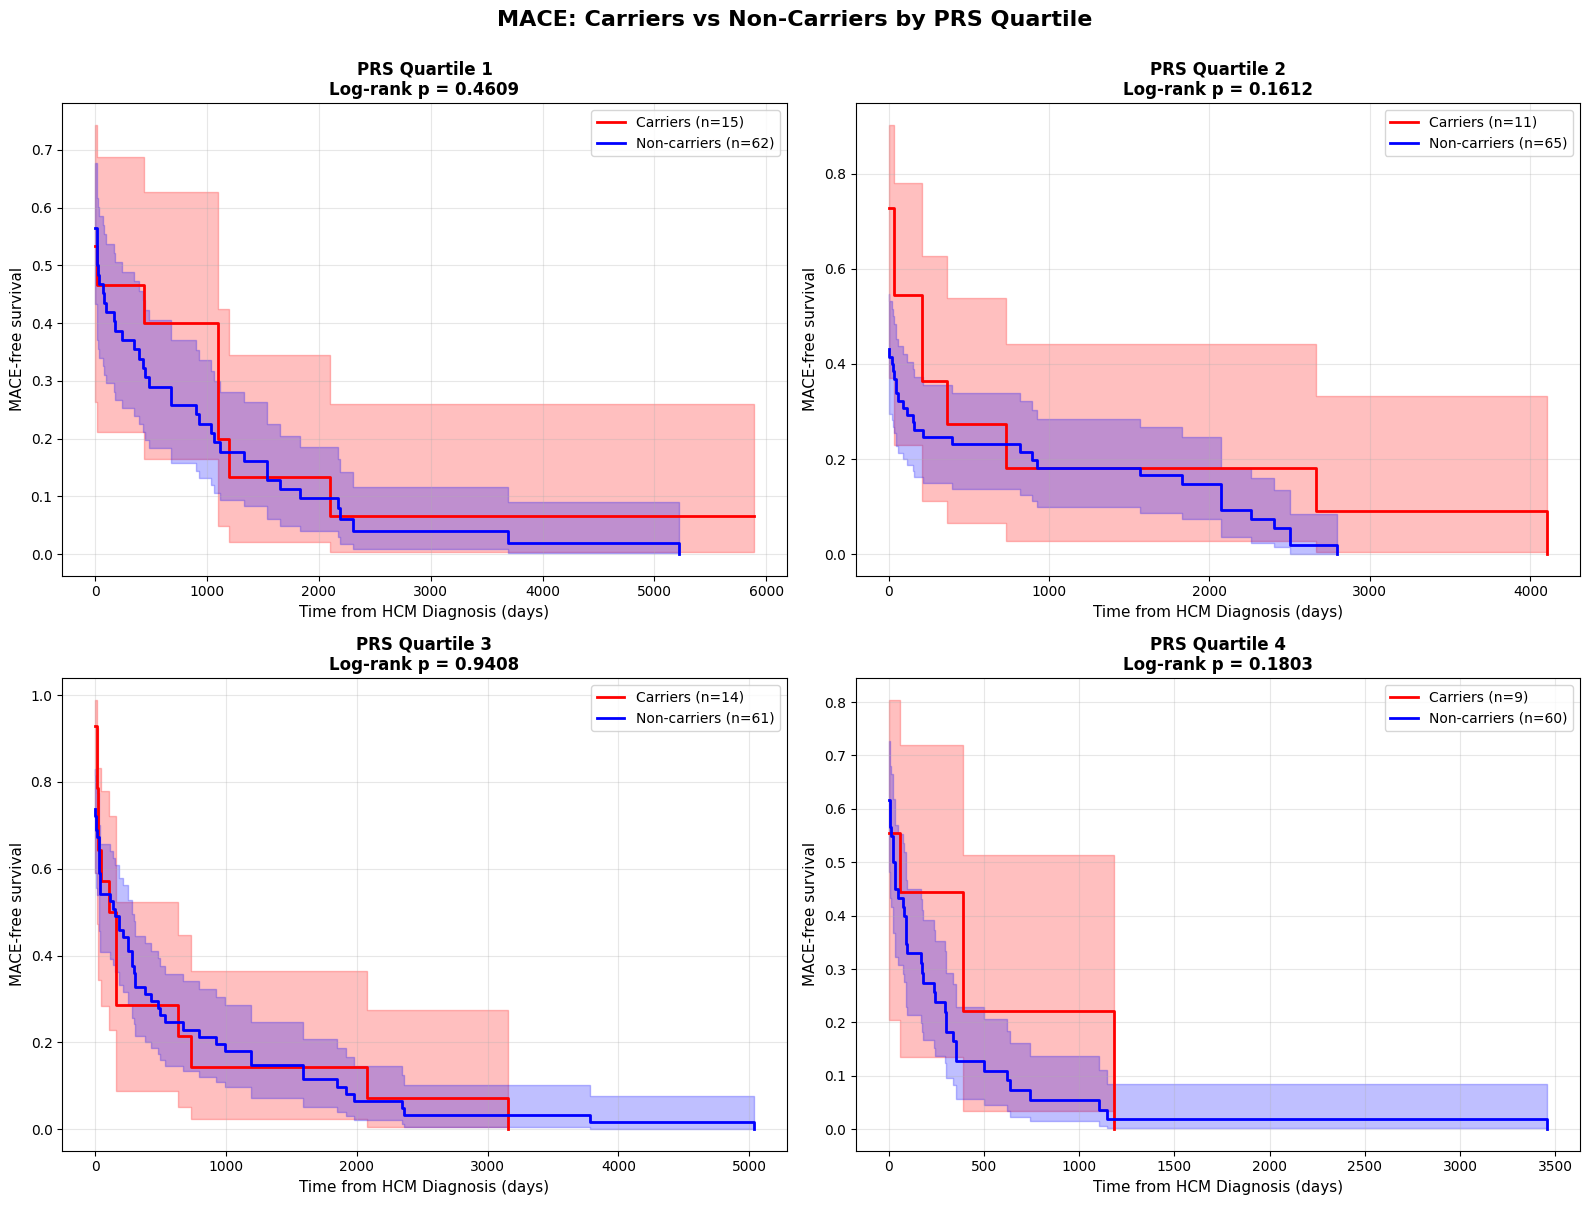


MACE Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,15,14,62,61,0.460868,0.543785
1,2,11,11,65,63,0.161185,1.963072
2,3,14,14,61,61,0.940787,0.005518
3,4,9,9,60,58,0.180346,1.794774



------------------------------------------------------------
Cardiac Interventions
------------------------------------------------------------


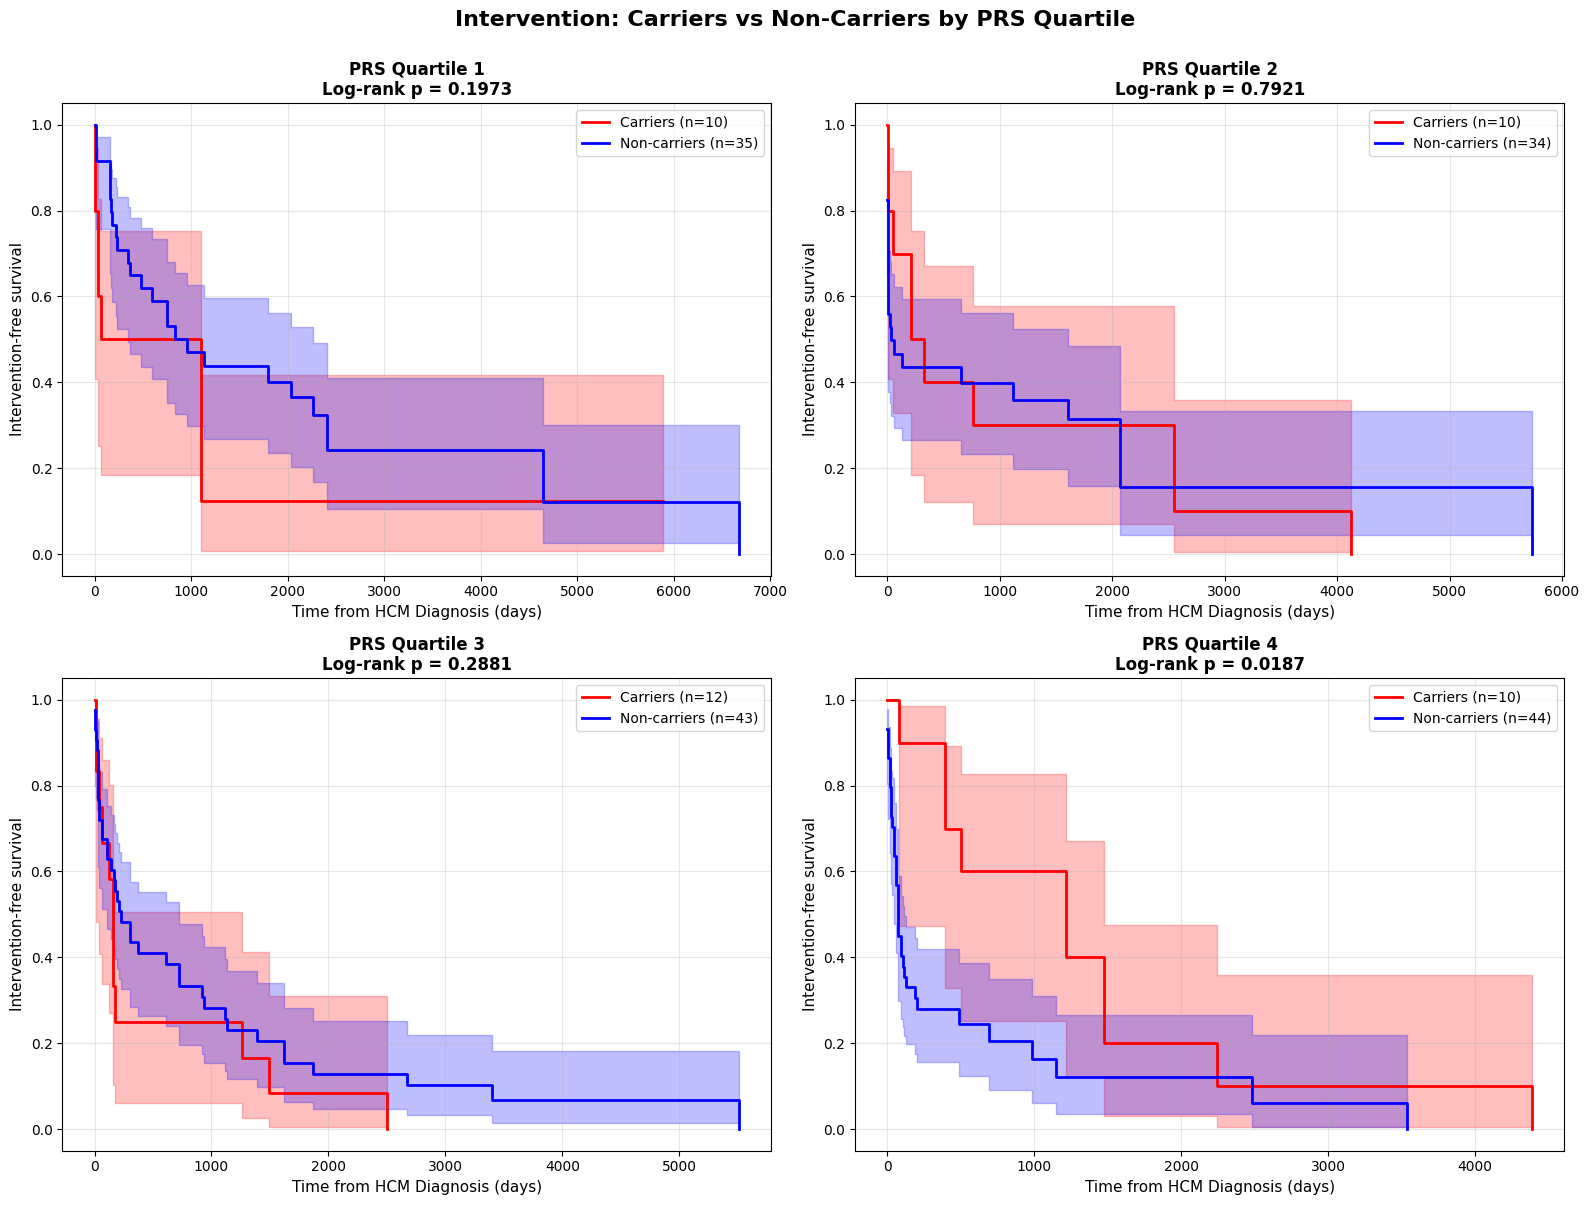


Intervention Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,10,8,35,27,0.197306,1.662202
1,2,10,10,34,26,0.792137,0.069452
2,3,12,12,43,39,0.288104,1.128462
3,4,10,10,44,37,0.018684,5.530811



------------------------------------------------------------
All-Cause Mortality
------------------------------------------------------------


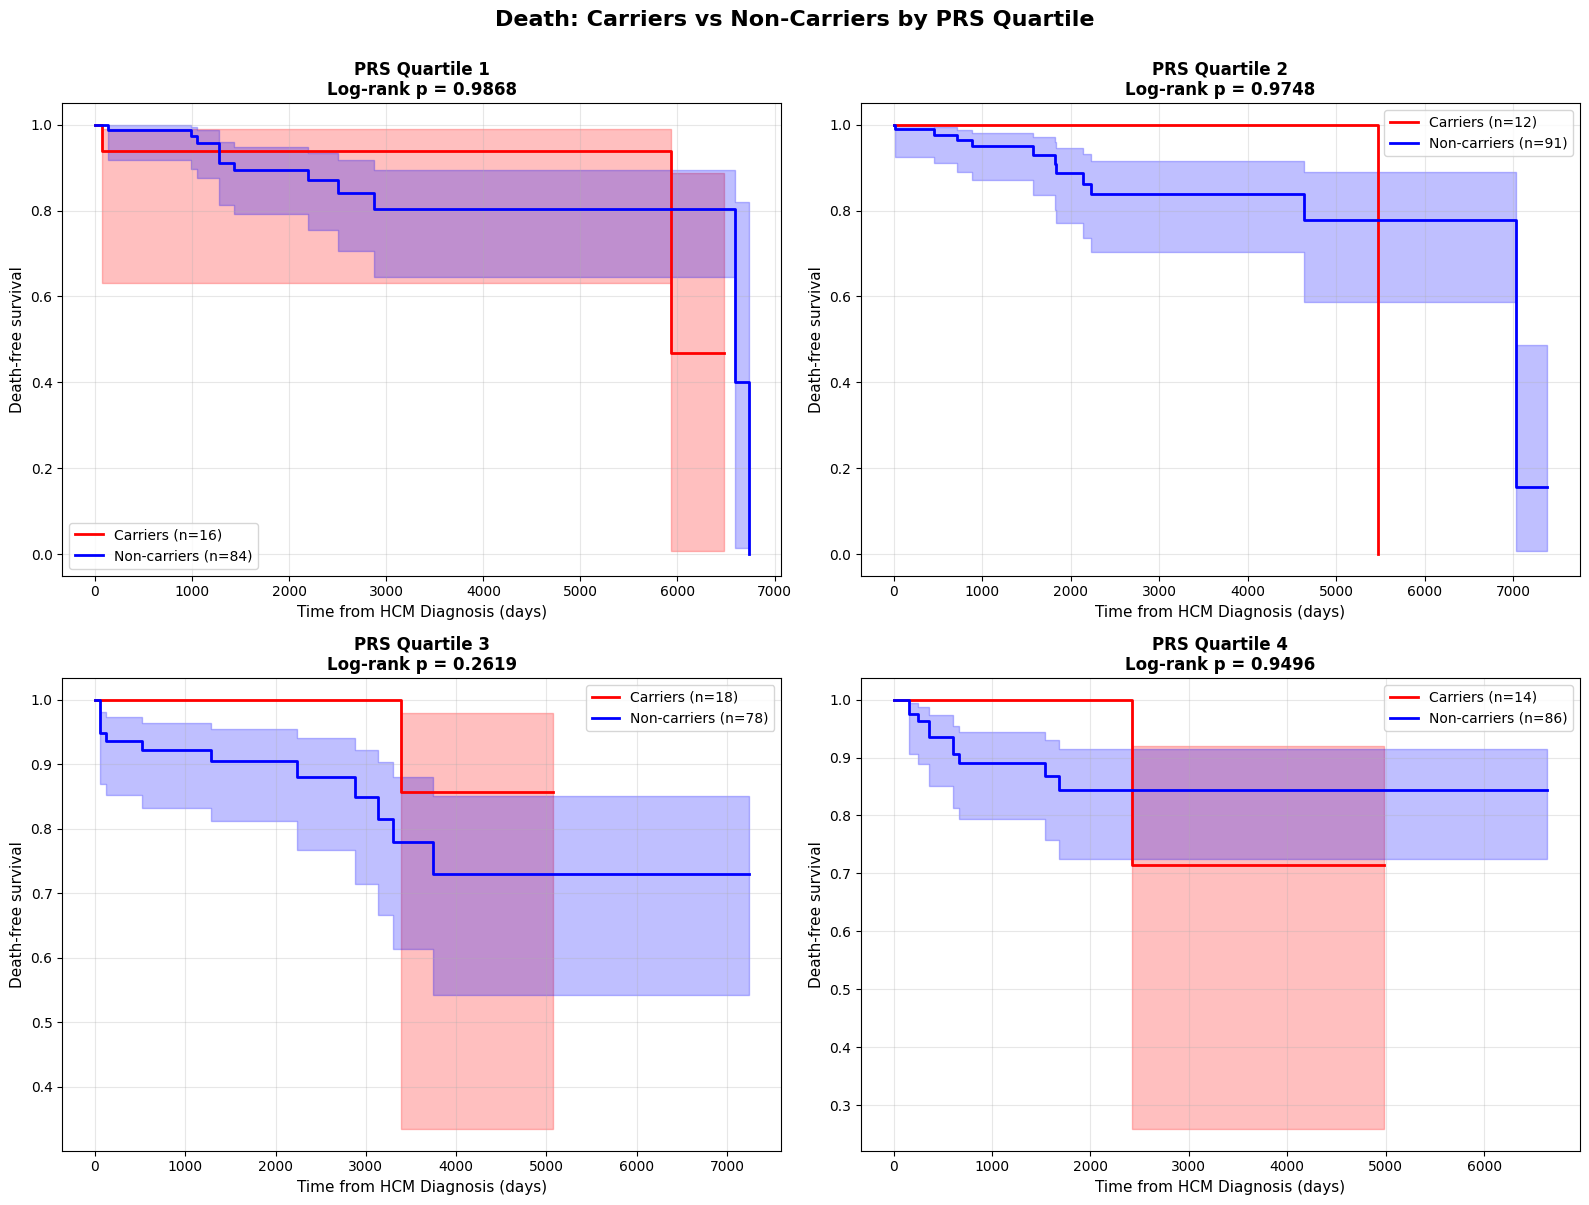


Death Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,16,2,84,12,0.986821,0.000273
1,2,12,2,91,14,0.974753,0.001002
2,3,18,1,78,12,0.261939,1.258480
3,4,14,2,86,10,0.949649,0.003988



 All stratified Kaplan-Meier curves generated!


In [51]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clean the data first 
print("Cleaning survival data...")
print(f"Original rows: {len(survival_df)}")

# Check for NaNs
print("\nChecking for missing values:")
print(survival_df[['mace_time_days', 'mace_event', 
                   'intervention_time_days', 'intervention_event',
                   'death_time_days', 'death_event']].isnull().sum())

# Create separate clean datasets for each outcome

survival_mace_clean = survival_df[
    (survival_df['mace_time_days'].notna()) & 
    (survival_df['mace_time_days'] >= 0) &
    (survival_df['mace_event'].notna())
].copy()

survival_intervention_clean = survival_df[
    (survival_df['intervention_time_days'].notna()) & 
    (survival_df['intervention_time_days'] >= 0) &
    (survival_df['intervention_event'].notna())
].copy()

survival_death_clean = survival_df[
    (survival_df['death_time_days'].notna()) & 
    (survival_df['death_time_days'] >= 0) &
    (survival_df['death_event'].notna())
].copy()

print(f"\nCleaned rows:")
print(f"  MACE: {len(survival_mace_clean)} (removed {len(survival_df) - len(survival_mace_clean)})")
print(f"  Intervention: {len(survival_intervention_clean)} (removed {len(survival_df) - len(survival_intervention_clean)})")
print(f"  Death: {len(survival_death_clean)} (removed {len(survival_df) - len(survival_death_clean)})")

# Function to create KM plots stratified by PRS quartile
def plot_km_curve_by_quartile(df, time_col, event_col, outcome_name):
    """
    Create Kaplan-Meier survival curves comparing carriers vs non-carriers
    stratified by PRS quartile \
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    kmf = KaplanMeierFitter()
    
    all_results = []
    
    for q in range(1, 5):
        ax = axes[q-1]
        
        # Filter to this quartile
        q_data = df[df['prs_quartile'] == q].copy()
        
        # Fit for carriers in this quartile
        carrier_data = q_data[q_data['is_carrier']].copy()
        if len(carrier_data) > 0:
            kmf.fit(
                durations=carrier_data[time_col], 
                event_observed=carrier_data[event_col],
                label=f'Carriers (n={len(carrier_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color='red', linewidth=2)
        
        # Fit for non-carriers in this quartile
        noncarrier_data = q_data[~q_data['is_carrier']].copy()
        if len(noncarrier_data) > 0:
            kmf.fit(
                durations=noncarrier_data[time_col], 
                event_observed=noncarrier_data[event_col],
                label=f'Non-carriers (n={len(noncarrier_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color='blue', linewidth=2)
        
        # Log-rank test for this quartile
        if len(carrier_data) > 0 and len(noncarrier_data) > 0:
            results = logrank_test(
                carrier_data[time_col], 
                noncarrier_data[time_col],
                carrier_data[event_col], 
                noncarrier_data[event_col]
            )
            p_val = results.p_value
            
            all_results.append({
                'quartile': q,
                'carriers_n': len(carrier_data),
                'carriers_events': int(carrier_data[event_col].sum()),
                'noncarriers_n': len(noncarrier_data),
                'noncarriers_events': int(noncarrier_data[event_col].sum()),
                'p_value': p_val,
                'test_statistic': results.test_statistic
            })
        else:
            p_val = np.nan
        
        # Formatting
        ax.set_xlabel('Time from HCM Diagnosis (days)', fontsize=11)
        ax.set_ylabel(f'{outcome_name}-free survival', fontsize=11)
        ax.set_title(f'PRS Quartile {q}\nLog-rank p = {p_val:.4f}', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{outcome_name}: Carriers vs Non-Carriers by PRS Quartile', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    return fig, all_results


# Create stratified KM curves for each outcome
print("CREATING STRATIFIED KAPLAN-MEIER CURVES (BY PRS QUARTILE)")

# 1. MACE outcome
print("\n" + "-"*60)
print("MACE - Major Adverse Cardiovascular Events")
print("-"*60)
fig1, mace_results = plot_km_curve_by_quartile(
    survival_mace_clean, 
    'mace_time_days', 
    'mace_event',
    'MACE'
)
plt.show()

# Print MACE results table
print("\nMACE Results by PRS Quartile:")
mace_df = pd.DataFrame(mace_results)
display(mace_df)

# 2. Intervention outcome
print("\n" + "-"*60)
print("Cardiac Interventions")
print("-"*60)
fig2, intervention_results = plot_km_curve_by_quartile(
    survival_intervention_clean, 
    'intervention_time_days', 
    'intervention_event',
    'Intervention'
)
plt.show()

# Print Intervention results table
print("\nIntervention Results by PRS Quartile:")
intervention_df = pd.DataFrame(intervention_results)
display(intervention_df)

# 3. Death outcome
print("\n" + "-"*60)
print("All-Cause Mortality")
print("-"*60)
fig3, death_results = plot_km_curve_by_quartile(
    survival_death_clean, 
    'death_time_days', 
    'death_event',
    'Death'
)
plt.show()

# Print Death results table
print("\nDeath Results by PRS Quartile:")
death_df = pd.DataFrame(death_results)
display(death_df)

print("\n All stratified Kaplan-Meier curves generated!")

In [1]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "hcm_analysis_scratch_updated"

client = bigquery.Client(project=PROJECT_ID)
query = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_survival_data`
"""

survival_df = client.query(query).to_dataframe()

print(f" Loaded {len(survival_df)} rows from hcm_survival_data")
print(f"\nColumns: {list(survival_df.columns)}")
print(f"\nFirst few rows:")
print(survival_df.head())

 Loaded 331 rows from hcm_survival_data

Columns: ['person_id', 'is_carrier', 'prs', 'prs_quartile', 'first_hcm_date', 'last_visit_date', 'mace_event', 'mace_date', 'mace_time_days', 'intervention_event', 'intervention_date', 'intervention_time_days', 'death_event', 'death_date', 'death_time_days']

First few rows:
    person_id  is_carrier       prs  prs_quartile first_hcm_date  \
0  R200217983       False -4.380551             1     2018-03-28   
1  R200580511       False -3.662117             3     2010-07-05   
2  R200839111       False -3.634761             3     2009-11-18   
3  R200913176       False -4.402258             1     2019-05-04   
4  R201249647       False -5.098710             1     2008-04-19   

  last_visit_date  mace_event   mace_date  mace_time_days  intervention_event  \
0      2025-02-26           1  2018-03-28               0                   0   
1      2018-04-14           1  2016-12-23            2363                   0   
2      2013-12-08           1  

Cleaning survival data...
Original rows: 331

Checking for missing values:
mace_time_days            0
mace_event                0
intervention_time_days    0
intervention_event        0
death_time_days           0
death_event               0
dtype: int64

Cleaned rows (INCLUDING censored patients):
  MACE: 331 (removed 0)
  Intervention: 331 (removed 0)
  Death: 331 (removed 0)

Event counts:
  MACE: 225 events, 106 censored
  Intervention: 118 events, 213 censored
  Death: 43 events, 288 censored
CREATING STRATIFIED KAPLAN-MEIER CURVES (BY PRS QUARTILE)
MACE - Major Adverse Cardiovascular Events


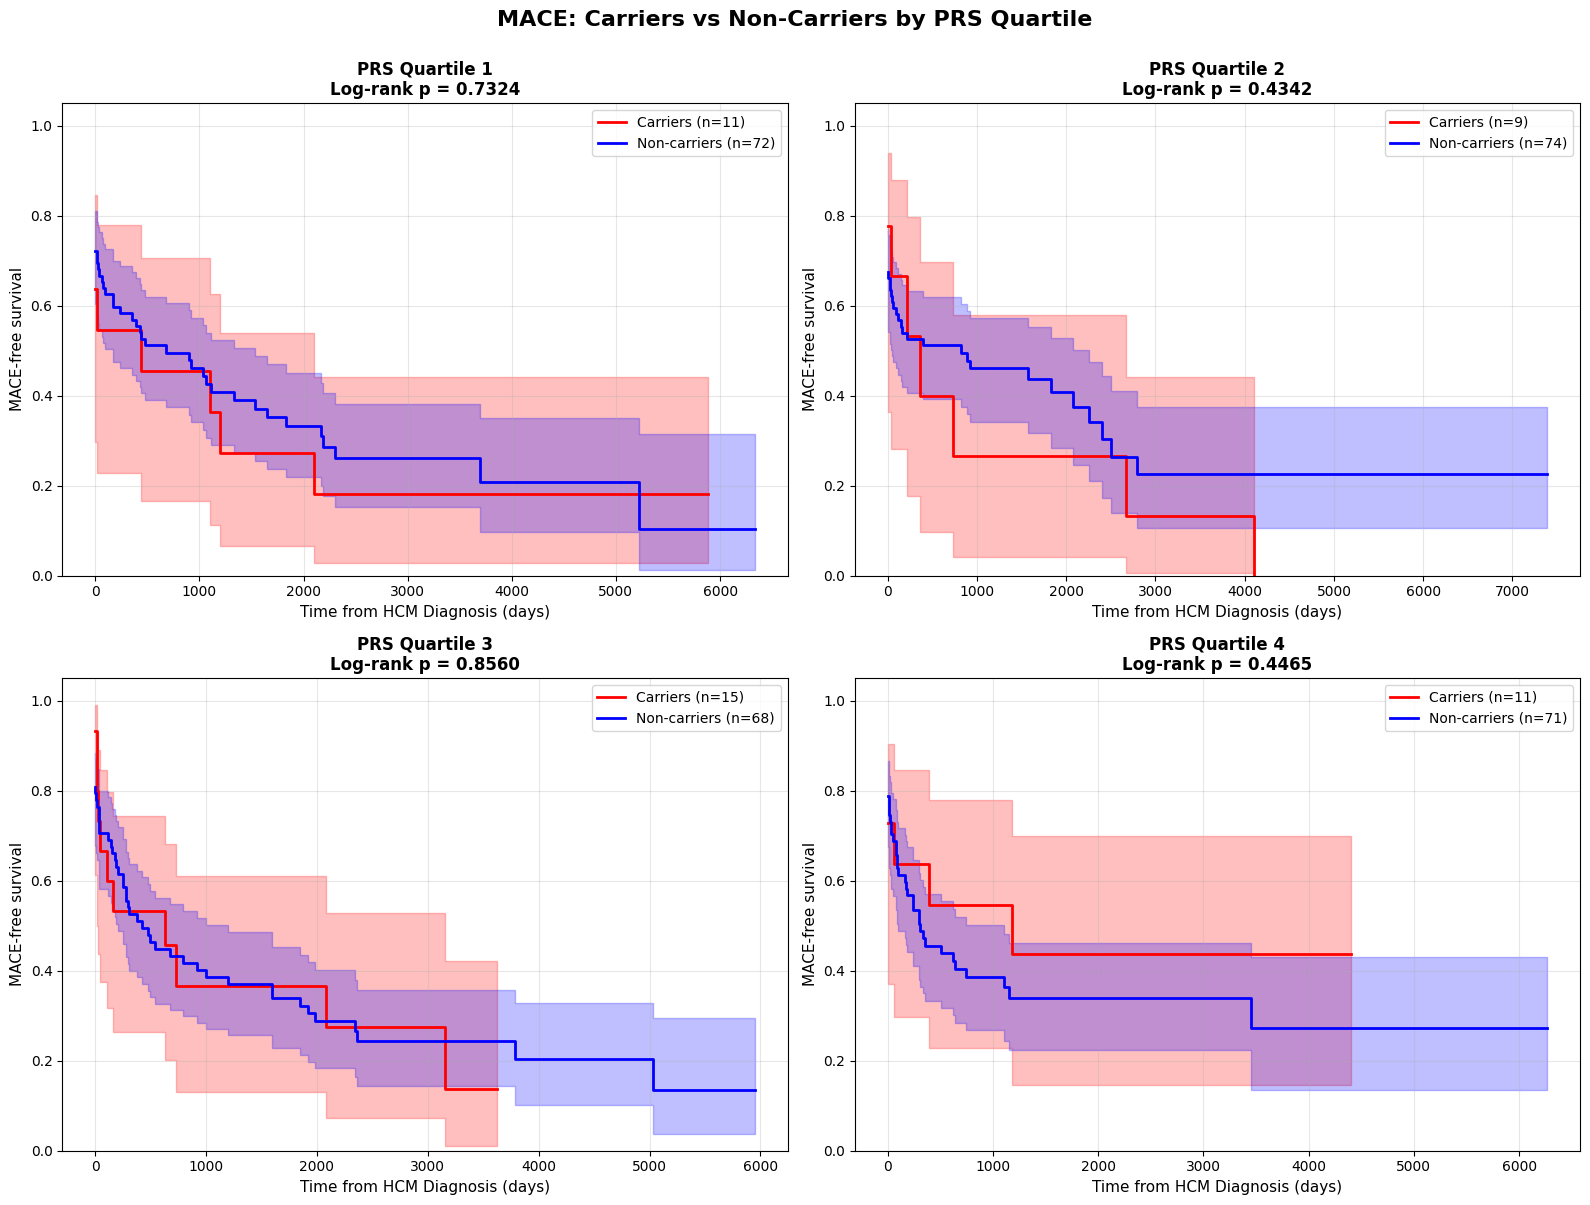


MACE Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,11,9,72,50,0.732401,0.116918
1,2,9,8,74,46,0.434180,0.611617
2,3,15,11,68,51,0.855952,0.032953
3,4,11,6,71,44,0.446504,0.579512


Cardiac Interventions


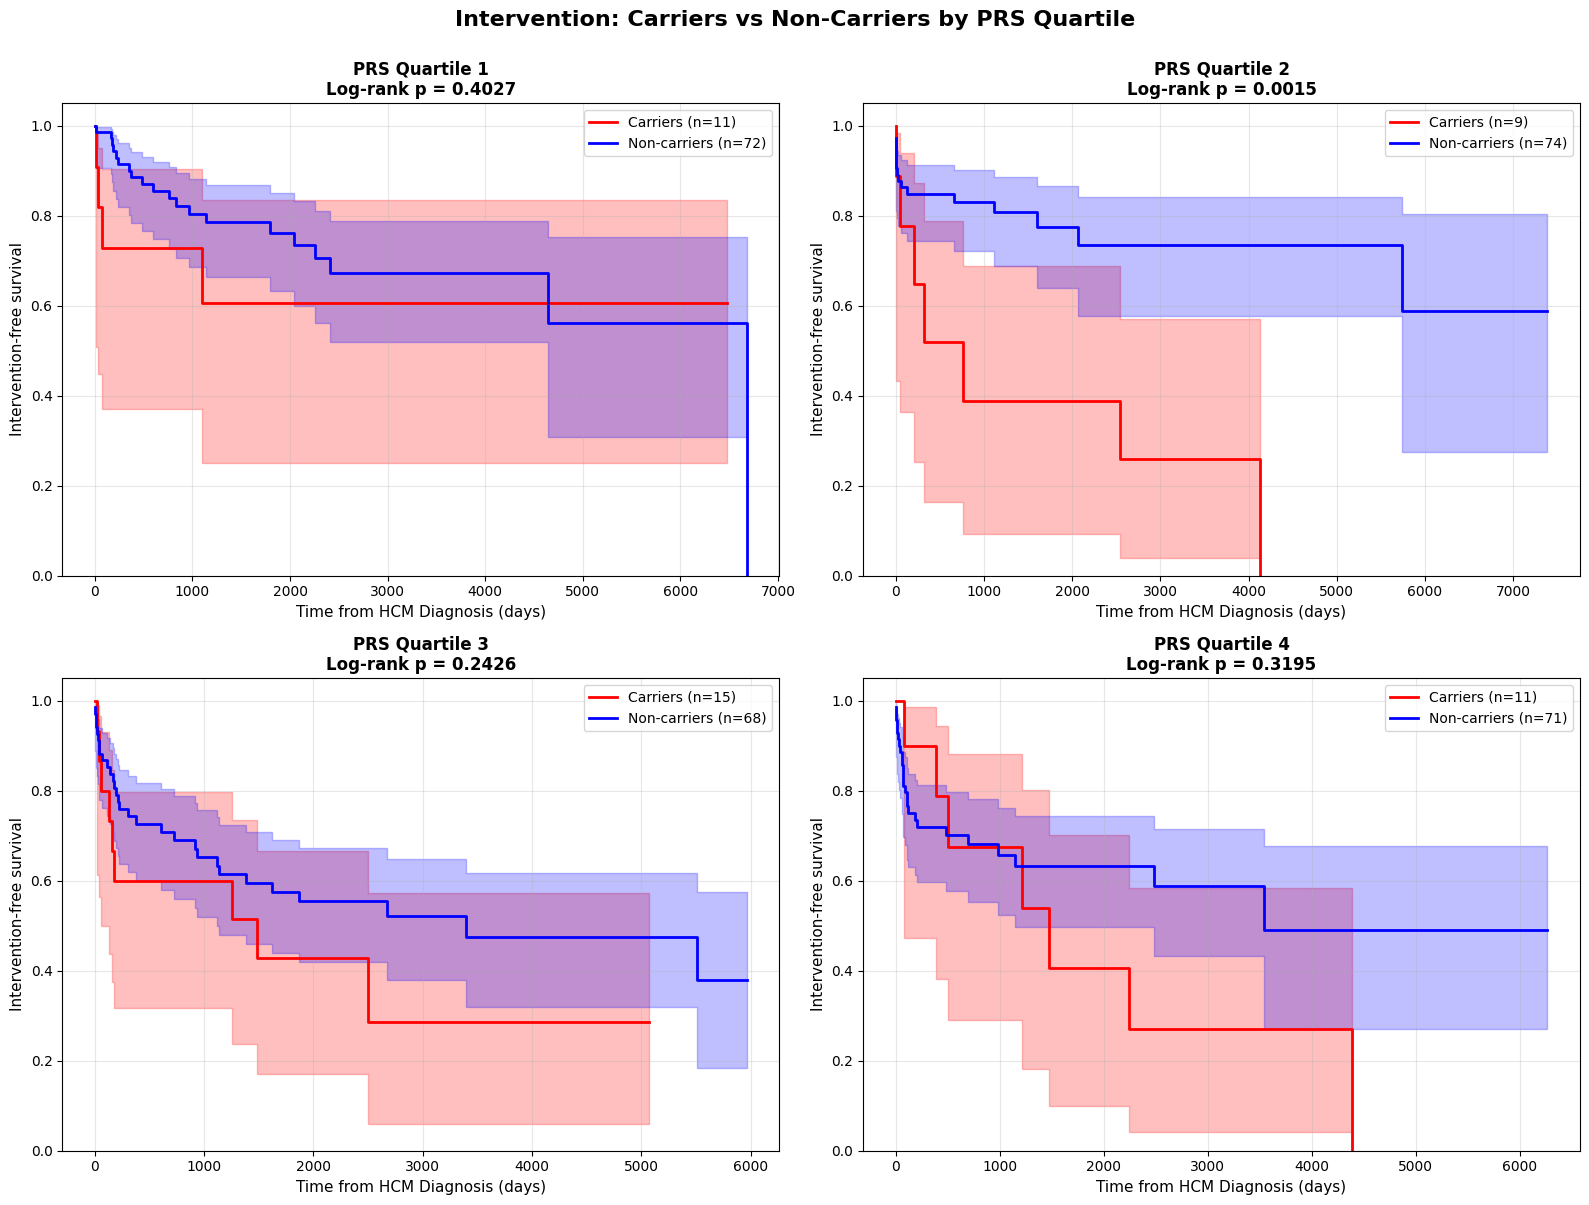


Intervention Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,11,4,72,20,0.402681,0.700306
1,2,9,7,74,16,0.001519,10.054959
2,3,15,9,68,30,0.242635,1.365219
3,4,11,7,71,25,0.319495,0.991013


All-Cause Mortality


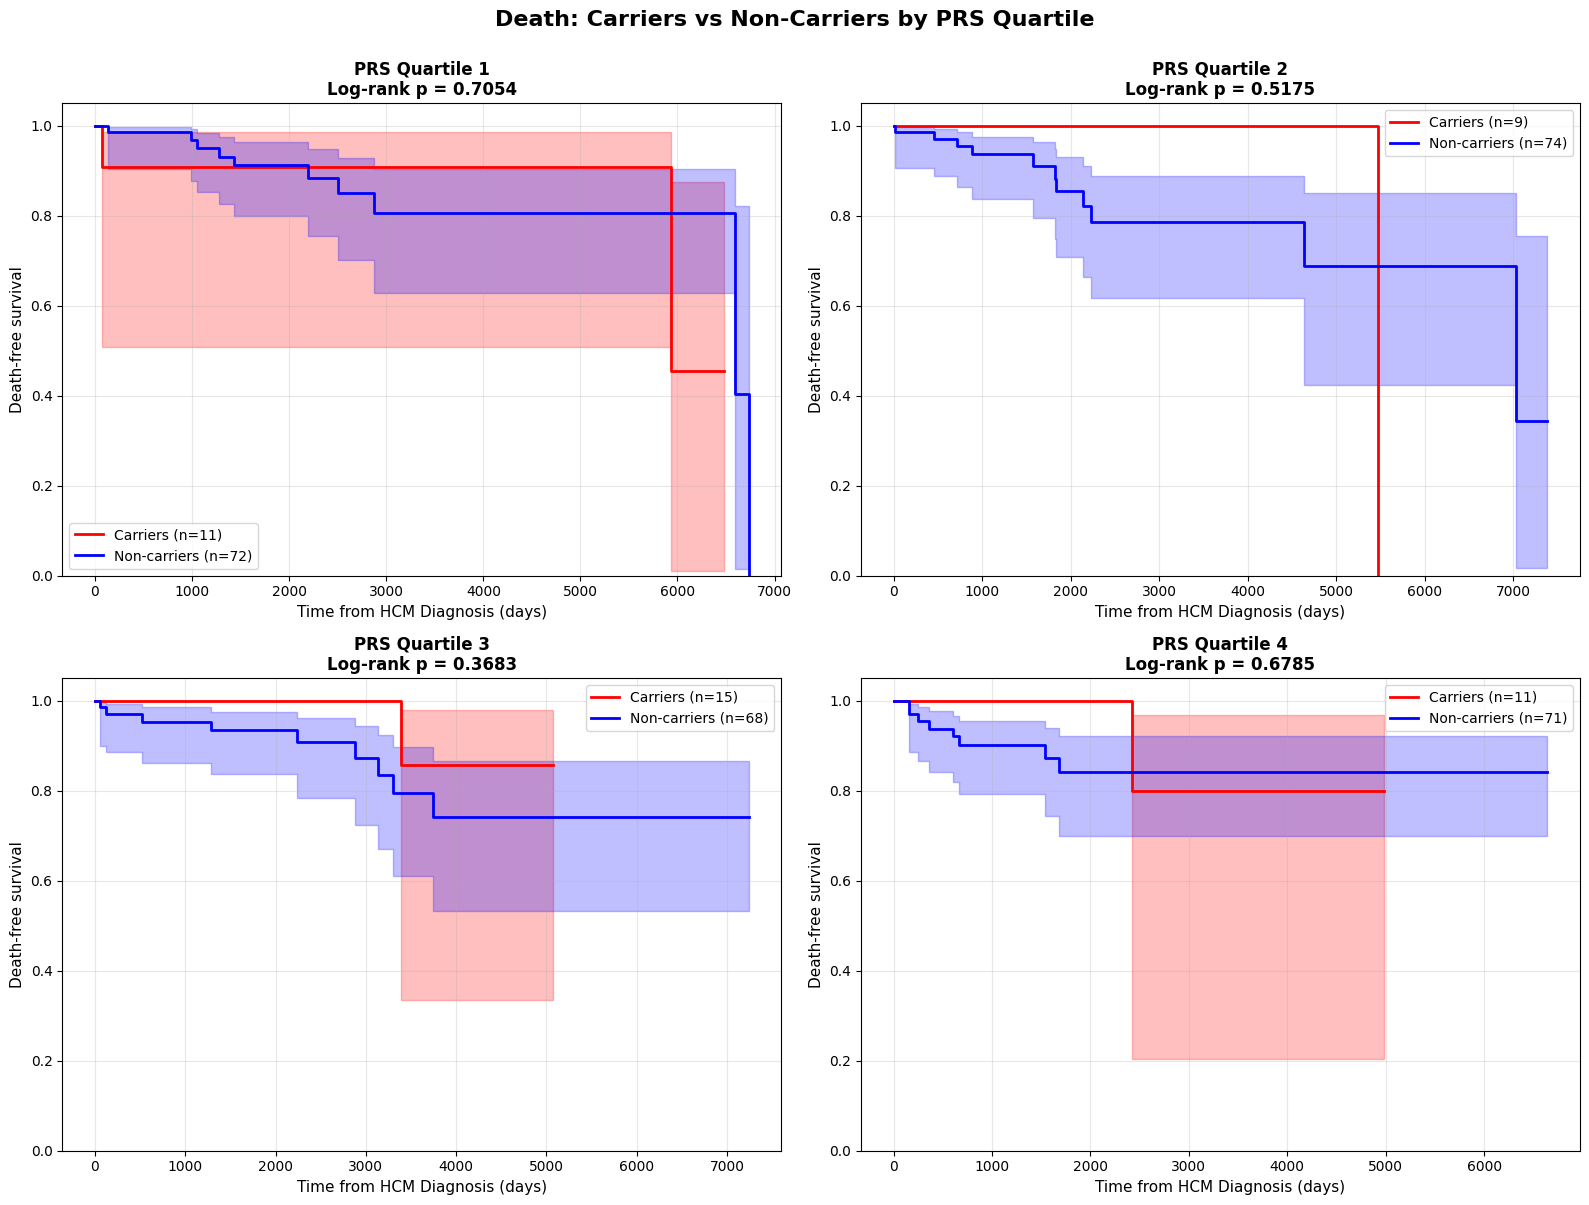


Death Results by PRS Quartile:


,quartile,carriers_n,carriers_events,noncarriers_n,noncarriers_events,p_value,test_statistic
0,1,11,2,72,10,0.705409,0.142906
1,2,9,1,74,11,0.517462,0.418948
2,3,15,1,68,9,0.368292,0.809418
3,4,11,1,71,8,0.678512,0.171806


In [2]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clean the data - include all patients (with and without events)
print("Cleaning survival data...")
print(f"Original rows: {len(survival_df)}")

# Check for NaNs
print("\nChecking for missing values:")
print(survival_df[['mace_time_days', 'mace_event', 
                   'intervention_time_days', 'intervention_event',
                   'death_time_days', 'death_event']].isnull().sum())

# Create separate clean datasets for each outcome

survival_mace_clean = survival_df[
    (survival_df['mace_time_days'].notna()) & 
    (survival_df['mace_time_days'] >= 0) &
    (survival_df['mace_event'].notna()) &
    (survival_df['mace_event'].isin([0, 1]))  # ← Keep both events (1) and censored (0)
].copy()

survival_intervention_clean = survival_df[
    (survival_df['intervention_time_days'].notna()) & 
    (survival_df['intervention_time_days'] >= 0) &
    (survival_df['intervention_event'].notna()) &
    (survival_df['intervention_event'].isin([0, 1]))  # ← Keep both events and censored
].copy()

survival_death_clean = survival_df[
    (survival_df['death_time_days'].notna()) & 
    (survival_df['death_time_days'] >= 0) &
    (survival_df['death_event'].notna()) &
    (survival_df['death_event'].isin([0, 1]))  #  Keep both events and censored
].copy()

print(f"\nCleaned rows (INCLUDING censored patients):")
print(f"  MACE: {len(survival_mace_clean)} (removed {len(survival_df) - len(survival_mace_clean)})")
print(f"  Intervention: {len(survival_intervention_clean)} (removed {len(survival_df) - len(survival_intervention_clean)})")
print(f"  Death: {len(survival_death_clean)} (removed {len(survival_df) - len(survival_death_clean)})")

# Check event rates
print(f"\nEvent counts:")
print(f"  MACE: {survival_mace_clean['mace_event'].sum()} events, {(survival_mace_clean['mace_event']==0).sum()} censored")
print(f"  Intervention: {survival_intervention_clean['intervention_event'].sum()} events, {(survival_intervention_clean['intervention_event']==0).sum()} censored")
print(f"  Death: {survival_death_clean['death_event'].sum()} events, {(survival_death_clean['death_event']==0).sum()} censored")

# Function to create KM plots stratified by PRS quartile
def plot_km_curve_by_quartile(df, time_col, event_col, outcome_name):
    """
    Create Kaplan-Meier survival curves comparing carriers vs non-carriers
    stratified by PRS quartile
    
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    kmf = KaplanMeierFitter()
    
    all_results = []
    
    for q in range(1, 5):
        ax = axes[q-1]
        
        # Filter to this quartile
        q_data = df[df['prs_quartile'] == q].copy()
        
        # Fit for carriers in this quartile
        carrier_data = q_data[q_data['is_carrier']].copy()
        if len(carrier_data) > 0:
            kmf.fit(
                durations=carrier_data[time_col], 
                event_observed=carrier_data[event_col],
                label=f'Carriers (n={len(carrier_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color='red', linewidth=2)
        
        # Fit for non-carriers in this quartile
        noncarrier_data = q_data[~q_data['is_carrier']].copy()
        if len(noncarrier_data) > 0:
            kmf.fit(
                durations=noncarrier_data[time_col], 
                event_observed=noncarrier_data[event_col],
                label=f'Non-carriers (n={len(noncarrier_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color='blue', linewidth=2)
        
        # Log-rank test for this quartile
        if len(carrier_data) > 0 and len(noncarrier_data) > 0:
            results = logrank_test(
                carrier_data[time_col], 
                noncarrier_data[time_col],
                carrier_data[event_col], 
                noncarrier_data[event_col]
            )
            p_val = results.p_value
            
            all_results.append({
                'quartile': q,
                'carriers_n': len(carrier_data),
                'carriers_events': int(carrier_data[event_col].sum()),
                'noncarriers_n': len(noncarrier_data),
                'noncarriers_events': int(noncarrier_data[event_col].sum()),
                'p_value': p_val,
                'test_statistic': results.test_statistic
            })
        else:
            p_val = np.nan
        
        # Formatting
        ax.set_xlabel('Time from HCM Diagnosis (days)', fontsize=11)
        ax.set_ylabel(f'{outcome_name}-free survival', fontsize=11)
        ax.set_title(f'PRS Quartile {q}\nLog-rank p = {p_val:.4f}', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])  # ← Ensure y-axis starts at 0
    
    plt.suptitle(f'{outcome_name}: Carriers vs Non-Carriers by PRS Quartile', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    return fig, all_results


# Create stratified KM curves for each outcome
print("CREATING STRATIFIED KAPLAN-MEIER CURVES (BY PRS QUARTILE)")

# 1. MACE outcome
print("MACE - Major Adverse Cardiovascular Events")
fig1, mace_results = plot_km_curve_by_quartile(
    survival_mace_clean, 
    'mace_time_days', 
    'mace_event',
    'MACE'
)
plt.show()

# Print MACE results table
print("\nMACE Results by PRS Quartile:")
mace_df = pd.DataFrame(mace_results)
display(mace_df)

# 2. Intervention outcome
print("Cardiac Interventions")
fig2, intervention_results = plot_km_curve_by_quartile(
    survival_intervention_clean, 
    'intervention_time_days', 
    'intervention_event',
    'Intervention'
)
plt.show()

# Print Intervention results table
print("\nIntervention Results by PRS Quartile:")
intervention_df = pd.DataFrame(intervention_results)
display(intervention_df)

# 3. Death outcome
print("All-Cause Mortality")
fig3, death_results = plot_km_curve_by_quartile(
    survival_death_clean, 
    'death_time_days', 
    'death_event',
    'Death'
)
plt.show()

# Print Death results table
print("\nDeath Results by PRS Quartile:")
death_df = pd.DataFrame(death_results)
display(death_df)

In [1]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "hcm_analysis_scratch_updated"

client = bigquery.Client(project=PROJECT_ID)
query = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_survival_data`
"""

survival_df = client.query(query).to_dataframe()

print(f" Loaded {len(survival_df)} rows from hcm_survival_data")
print(f"\nColumns: {list(survival_df.columns)}")
print(f"\nFirst few rows:")
print(survival_df.head())

 Loaded 331 rows from hcm_survival_data

Columns: ['person_id', 'is_carrier', 'prs', 'prs_quartile', 'first_hcm_date', 'last_visit_date', 'mace_event', 'mace_date', 'mace_time_days', 'intervention_event', 'intervention_date', 'intervention_time_days', 'death_event', 'death_date', 'death_time_days']

First few rows:
    person_id  is_carrier       prs  prs_quartile first_hcm_date  \
0  R200217983       False -4.380551             1     2018-03-28   
1  R200580511       False -3.662117             3     2010-07-05   
2  R200839111       False -3.634761             3     2009-11-18   
3  R200913176       False -4.402258             1     2019-05-04   
4  R201249647       False -5.098710             1     2008-04-19   

  last_visit_date  mace_event   mace_date  mace_time_days  intervention_event  \
0      2025-02-26           1  2018-03-28               0                   0   
1      2018-04-14           1  2016-12-23            2363                   0   
2      2013-12-08           1  

CREATING composite outcome E: Time to First Event (MACE/Death/Intervention)

Calculating time to first event (composite outcome)...
Total patients: 331
Total composite events: 245
Censored patients: 86

Breakdown of first events:
first_event_type
MACE            214
Intervention     25
Death             6
Name: count, dtype: int64


HCM CARRIERS ONLY:
Total HCM carriers: 46
Total composite events: 38
Censored: 8

First event types among HCM carriers:
first_event_type
MACE            31
Intervention     6
Death            1
Name: count, dtype: int64

By PRS Quartile:
  Q1: n=11, events=10
  Q2: n=9, events=8
  Q3: n=15, events=11
  Q4: n=11, events=9

Creating Kaplan-Meier curve...

Overall log-rank test:
  Test statistic: 0.31
  P-value: 0.9580

Pairwise log-rank tests:
     test_statistic         p  -log2(p)
1 2        0.209481  0.647175  0.627773
  3        0.076996  0.781410  0.355849
  4        0.004015  0.949474  0.074800
2 3        0.020461  0.886256  0.174204
  4        0.304989

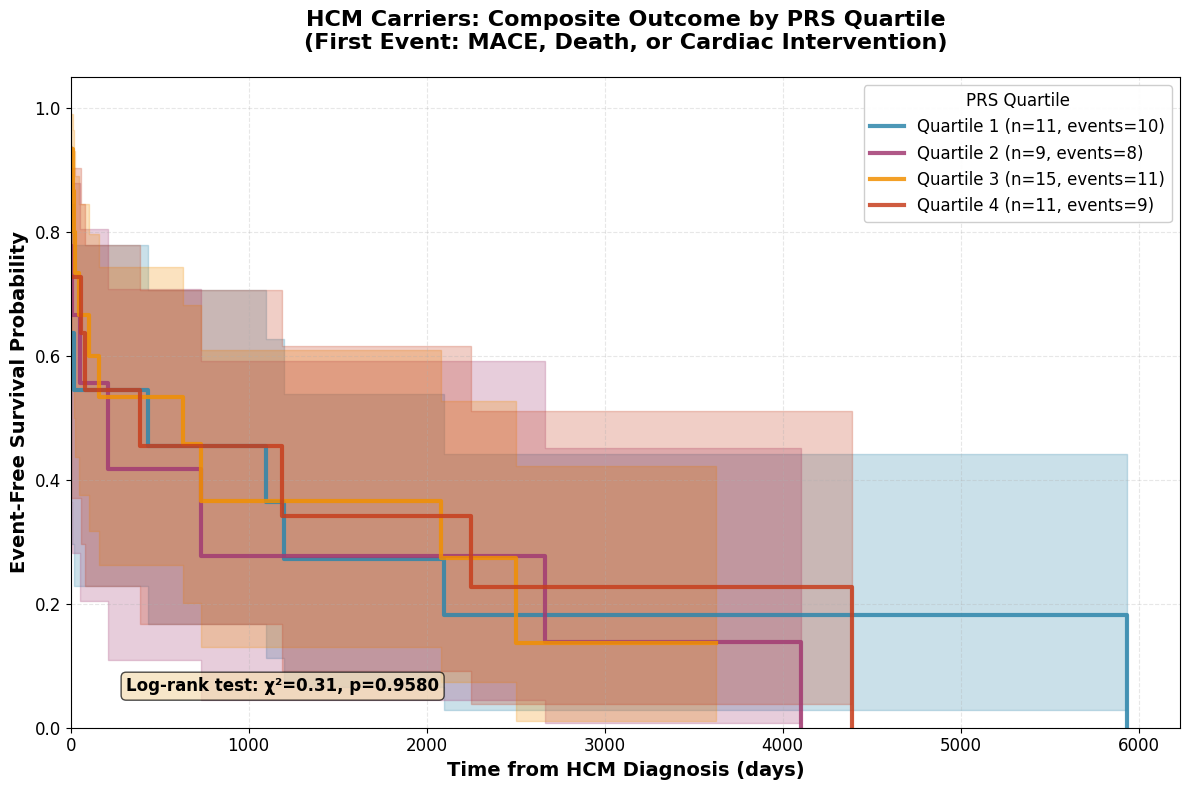

SUMMARY STATISTICS BY PRS QUARTILE


,Quartile,N,Events,Event_Rate_%,Median_Followup_Days,Median_Survival_Days,Event_Rate_per_100PY
0,1,11,10,90.9%,437.0,437,24.44
1,2,9,8,88.9%,126.0,211,36.98
2,3,15,11,73.3%,493.0,630,30.10
3,4,11,9,81.8%,392.0,392,27.89


FIRST EVENT TYPE BY PRS QUARTILE


Quartile,1,2,3,4
Event_Type,,,,
Death,1,0,0,0
Intervention,0,2,1,3
MACE,9,6,10,6


In [3]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("CREATING composite outcome E: Time to First Event (MACE/Death/Intervention)")

# Start with the full survival dataframe
composite_df = survival_df.copy()

# For each patient, find the FIRST event across all three outcomes
print("\nCalculating time to first event (composite outcome)...")

# Create composite event indicator and time
composite_df['composite_event'] = 0
composite_df['composite_time_days'] = np.nan

# Initialize with a list to track which events occurred first
event_times = []

for idx, row in composite_df.iterrows():
    times = []
    
    # Collect all event times (only if event actually occurred)
    if pd.notna(row['mace_time_days']) and row['mace_event'] == 1:
        times.append(('MACE', row['mace_time_days']))
    
    if pd.notna(row['intervention_time_days']) and row['intervention_event'] == 1:
        times.append(('Intervention', row['intervention_time_days']))
    
    if pd.notna(row['death_time_days']) and row['death_event'] == 1:
        times.append(('Death', row['death_time_days']))
    
    # If any event occurred, take the earliest one
    if len(times) > 0:
        times.sort(key=lambda x: x[1])  # Sort by time
        first_event = times[0]
        composite_df.at[idx, 'composite_event'] = 1
        composite_df.at[idx, 'composite_time_days'] = first_event[1]
        composite_df.at[idx, 'first_event_type'] = first_event[0]
    else:
        # No event - use maximum follow-up time
        max_followup = max(
            row['mace_time_days'] if pd.notna(row['mace_time_days']) else 0,
            row['intervention_time_days'] if pd.notna(row['intervention_time_days']) else 0,
            row['death_time_days'] if pd.notna(row['death_time_days']) else 0
        )
        composite_df.at[idx, 'composite_event'] = 0
        composite_df.at[idx, 'composite_time_days'] = max_followup
        composite_df.at[idx, 'first_event_type'] = 'Censored'

# Clean the composite data
composite_clean = composite_df[
    (composite_df['composite_time_days'].notna()) & 
    (composite_df['composite_time_days'] >= 0) &
    (composite_df['composite_event'].notna()) &
    (composite_df['composite_event'].isin([0, 1]))
].copy()

print(f"Total patients: {len(composite_clean)}")
print(f"Total composite events: {composite_clean['composite_event'].sum()}")
print(f"Censored patients: {(composite_clean['composite_event']==0).sum()}")

# Breakdown of first event types
print("\nBreakdown of first events:")
event_breakdown = composite_clean[composite_clean['composite_event']==1]['first_event_type'].value_counts()
print(event_breakdown)

# Filter to HCM carriers only
carriers_composite = composite_clean[composite_clean['is_carrier'] == True].copy()

print(f"\n\nHCM CARRIERS ONLY:")
print(f"Total HCM carriers: {len(carriers_composite)}")
print(f"Total composite events: {carriers_composite['composite_event'].sum()}")
print(f"Censored: {(carriers_composite['composite_event']==0).sum()}")

print("\nFirst event types among HCM carriers:")
carrier_event_breakdown = carriers_composite[carriers_composite['composite_event']==1]['first_event_type'].value_counts()
print(carrier_event_breakdown)

print("\nBy PRS Quartile:")
for q in range(1, 5):
    q_data = carriers_composite[carriers_composite['prs_quartile'] == q]
    n = len(q_data)
    events = q_data['composite_event'].sum()
    print(f"  Q{q}: n={n}, events={events}")

# Define colors for quartiles
quartile_colors = {
    1: '#2E86AB',  # Blue (lowest risk)
    2: '#A23B72',  # Purple  
    3: '#F18F01',  # Orange
    4: '#C73E1D'   # Red (highest risk)
}

# Create the plot
print("\nCreating Kaplan-Meier curve...")

fig, ax = plt.subplots(figsize=(12, 8))

kmf = KaplanMeierFitter()

quartile_stats = []

# Plot each quartile
for q in range(1, 5):
    q_data = carriers_composite[carriers_composite['prs_quartile'] == q].copy()
    
    if len(q_data) > 0:
        n = len(q_data)
        events = int(q_data['composite_event'].sum())
        
        # Calculate median survival time if possible
        kmf.fit(
            durations=q_data['composite_time_days'], 
            event_observed=q_data['composite_event'],
            label=f'Quartile {q} (n={n}, events={events})'
        )
        
        # Get median survival time
        try:
            median_survival = kmf.median_survival_time_
            median_survival_str = f"{median_survival:.0f}" if not np.isnan(median_survival) else "Not reached"
        except:
            median_survival_str = "Not reached"
        
        # Plot
        kmf.plot_survival_function(
            ax=ax, 
            ci_show=True, 
            color=quartile_colors[q], 
            linewidth=3,
            alpha=0.85
        )
        
        # Calculate statistics
        median_followup = q_data['composite_time_days'].median()
        person_time = q_data['composite_time_days'].sum()
        event_rate = (events / person_time * 365.25 * 100) if person_time > 0 else 0
        
        quartile_stats.append({
            'Quartile': q,
            'N': n,
            'Events': events,
            'Event_Rate_%': f"{(events/n*100):.1f}%",
            'Median_Followup_Days': round(median_followup, 1),
            'Median_Survival_Days': median_survival_str,
            'Event_Rate_per_100PY': round(event_rate, 2)
        })

# Perform overall log-rank test
try:
    results = multivariate_logrank_test(
        carriers_composite['composite_time_days'],
        carriers_composite['prs_quartile'],
        carriers_composite['composite_event']
    )
    overall_p = results.p_value
    test_stat = results.test_statistic
    
    # Add to plot
    ax.text(
        0.05, 0.05, 
        f'Log-rank test: χ²={test_stat:.2f}, p={overall_p:.4f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=12,
        verticalalignment='bottom',
        fontweight='bold'
    )
    
    print(f"\nOverall log-rank test:")
    print(f"  Test statistic: {test_stat:.2f}")
    print(f"  P-value: {overall_p:.4f}")
    
except Exception as e:
    print(f"Could not compute log-rank test: {e}")
    overall_p = None

# Pairwise comparisons
print("\nPairwise log-rank tests:")
try:
    pairwise_results = pairwise_logrank_test(
        carriers_composite['composite_time_days'],
        carriers_composite['prs_quartile'],
        carriers_composite['composite_event']
    )
    print(pairwise_results.summary)
except Exception as e:
    print(f"Could not compute pairwise tests: {e}")

# Formatting
ax.set_xlabel('Time from HCM Diagnosis (days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Event-Free Survival Probability', fontsize=14, fontweight='bold')
ax.set_title('HCM Carriers: Composite Outcome by PRS Quartile\n(First Event: MACE, Death, or Cardiac Intervention)', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=12, framealpha=0.95, title='PRS Quartile', title_fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])
ax.set_xlim(left=0)
ax.tick_params(labelsize=12)

plt.tight_layout()

# Save
filename = 'km_hcm_carriers_composite_outcome_by_prs.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"\n Saved: {filename}")

plt.show()

# Display summary table
print("SUMMARY STATISTICS BY PRS QUARTILE")
stats_df = pd.DataFrame(quartile_stats)
display(stats_df)

# Event type breakdown by quartile
print("FIRST EVENT TYPE BY PRS QUARTILE")

event_type_summary = []
for q in range(1, 5):
    q_data = carriers_composite[carriers_composite['prs_quartile'] == q]
    q_events = q_data[q_data['composite_event'] == 1]
    
    for event_type in ['MACE', 'Intervention', 'Death']:
        count = (q_events['first_event_type'] == event_type).sum()
        event_type_summary.append({
            'Quartile': q,
            'Event_Type': event_type,
            'Count': count,
            'Percent_of_Q_Events': f"{(count/len(q_events)*100):.1f}%" if len(q_events) > 0 else "0%"
        })

event_type_df = pd.DataFrame(event_type_summary)
display(event_type_df.pivot(index='Event_Type', columns='Quartile', values='Count'))

In [5]:
SCRATCH_DATASET_ID_HCM = "hcm_analysis_scratch_updated"

In [8]:
SCRATCH_DATASET_ID= "gen_pop_carriers"

In [7]:
query_create_hcm_age_based = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based` AS

WITH demographics AS (
  -- Get demographics from both carrier and non-carrier tables
  SELECT person_id, birth_datetime, gender, first_hcm_date, age_at_diagnosis
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.model1_hcm_carriers`
  
  UNION ALL
  
  SELECT person_id, birth_datetime, gender, first_hcm_date, age_at_diagnosis
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.model1_hcm_noncarriers`
),

base_data AS (
  SELECT 
    h.*,
    d.birth_datetime,
    d.gender,
    d.age_at_diagnosis
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_survival_data` h
  LEFT JOIN demographics d
    ON h.person_id = d.person_id
)

SELECT
  person_id,
  is_carrier,
  prs,
  prs_quartile,
  DATE(birth_datetime) as birth_date,
  first_hcm_date as entry_date,
  first_hcm_date,
  last_visit_date,
  
  -- Age at HCM diagnosis (entry) - use pre-calculated age_at_diagnosis
  age_at_diagnosis as age_at_entry,
  
  -- MACE outcomes
  mace_event,
  mace_date,
  mace_time_days,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(mace_date, DATE(birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_mace,
  CAST(FLOOR(mace_time_days / 365.25) AS INT64) as mace_followup_years,
  
  -- Intervention outcomes
  intervention_event,
  intervention_date,
  intervention_time_days,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(intervention_date, DATE(birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CAST(FLOOR(intervention_time_days / 365.25) AS INT64) as intervention_followup_years,
  
  -- Death outcomes
  death_event,
  death_date,
  death_time_days,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(death_date, DATE(birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_death,
  CAST(FLOOR(death_time_days / 365.25) AS INT64) as death_followup_years,
  
  -- Cohort identifier
  'HCM' as cohort,
  
  -- Composite outcome (any MACE, intervention, or death)
  CASE 
    WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 THEN 1 
    ELSE 0 
  END as composite_event,
  
  -- Composite follow-up years (time to first event or censoring)
  CAST(FLOOR(
    LEAST(
      COALESCE(mace_time_days, 999999),
      COALESCE(intervention_time_days, 999999),
      COALESCE(death_time_days, 999999)
    ) / 365.25
  ) AS INT64) as composite_followup_years,
  
  -- First event type
  CASE 
    WHEN mace_event = 0 AND intervention_event = 0 AND death_event = 0 THEN NULL
    WHEN COALESCE(mace_time_days, 999999) <= COALESCE(intervention_time_days, 999999) 
         AND COALESCE(mace_time_days, 999999) <= COALESCE(death_time_days, 999999) THEN 'MACE'
    WHEN COALESCE(intervention_time_days, 999999) <= COALESCE(death_time_days, 999999) THEN 'Intervention'
    ELSE 'Death'
  END as first_event_type,
  
  -- PRS binary group
  CASE 
    WHEN prs_quartile = 4 THEN 'Q4 (Highest)'
    ELSE 'Q1-Q3 (Lower)'
  END as prs_binary_group,
  
  -- Age at end of follow-up for each outcome type
  CASE 
    WHEN mace_event = 1 THEN DATE_DIFF(mace_date, DATE(birth_datetime), YEAR)
    ELSE DATE_DIFF(last_visit_date, DATE(birth_datetime), YEAR)
  END as age_at_mace_end,
  
  CASE 
    WHEN intervention_event = 1 THEN DATE_DIFF(intervention_date, DATE(birth_datetime), YEAR)
    ELSE DATE_DIFF(last_visit_date, DATE(birth_datetime), YEAR)
  END as age_at_intervention_end,
  
  CASE 
    WHEN death_event = 1 THEN DATE_DIFF(death_date, DATE(birth_datetime), YEAR)
    ELSE DATE_DIFF(last_visit_date, DATE(birth_datetime), YEAR)
  END as age_at_death_end,
  
  -- Age at composite event or censoring
  DATE_DIFF(
    COALESCE(
      CASE 
        WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 
        THEN LEAST(
          COALESCE(mace_date, DATE '9999-12-31'),
          COALESCE(intervention_date, DATE '9999-12-31'),
          COALESCE(death_date, DATE '9999-12-31')
        )
      END,
      last_visit_date
    ),
    DATE(birth_datetime),
    YEAR
  ) as age_at_composite_end

FROM base_data
ORDER BY person_id
"""

# Execute the query
print("Creating hcm_composite_outcome_age_based table...")

job = client.query(query_create_hcm_age_based)
job.result()

print(" Table created successfully!")
print()

# Verify the table
query_verify = f"""
SELECT 
  COUNT(*) as total_rows,
  SUM(CASE WHEN is_carrier THEN 1 ELSE 0 END) as n_carriers,
  SUM(CASE WHEN NOT is_carrier THEN 1 ELSE 0 END) as n_noncarriers,
  SUM(composite_event) as n_with_composite_event,
  ROUND(AVG(age_at_entry), 1) as avg_age_at_hcm_diagnosis,
  MIN(age_at_entry) as min_age_at_diagnosis,
  MAX(age_at_entry) as max_age_at_diagnosis
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
"""

df_verify = client.query(query_verify).to_dataframe()
print(" TABLE SUMMARY:")
print(df_verify.to_string(index=False))
print()

# Show sample rows
query_sample = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
LIMIT 5
"""

df_sample = client.query(query_sample).to_dataframe()
print("\n SAMPLE ROWS:")
print(df_sample.to_string(index=False))
print()

# Check age groups distribution
query_age_groups = f"""
SELECT 
  CASE 
    WHEN age_at_entry < 20 THEN 'Pediatric/Young (<20)'
    WHEN age_at_entry BETWEEN 20 AND 50 THEN 'Adult (20-50)'
    WHEN age_at_entry > 50 THEN 'Late-onset (>50)'
  END as age_group,
  COUNT(*) as n_patients,
  SUM(CASE WHEN is_carrier THEN 1 ELSE 0 END) as n_carriers,
  SUM(CASE WHEN NOT is_carrier THEN 1 ELSE 0 END) as n_noncarriers,
  SUM(composite_event) as n_events,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as event_rate_pct
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
GROUP BY age_group
ORDER BY 
  CASE age_group
    WHEN 'Pediatric/Young (<20)' THEN 1
    WHEN 'Adult (20-50)' THEN 2
    WHEN 'Late-onset (>50)' THEN 3
  END
"""

df_age_groups = client.query(query_age_groups).to_dataframe()
print("\nAGE GROUP DISTRIBUTION:")
print(df_age_groups.to_string(index=False))

print(" HCM age-based composite outcome table is ready for 3-group RMST analysis")

Creating hcm_composite_outcome_age_based table...
 Table created successfully!

 TABLE SUMMARY:
 total_rows  n_carriers  n_noncarriers  n_with_composite_event  avg_age_at_hcm_diagnosis  min_age_at_diagnosis  max_age_at_diagnosis
        331          46            285                     245                      52.4                     0                    87


 SAMPLE ROWS:
 person_id  is_carrier       prs  prs_quartile birth_date entry_date first_hcm_date last_visit_date  age_at_entry  mace_event  mace_date  mace_time_days  age_at_mace  mace_followup_years  intervention_event intervention_date  intervention_time_days  age_at_intervention  intervention_followup_years  death_event death_date  death_time_days  age_at_death  death_followup_years cohort  composite_event  composite_followup_years first_event_type prs_binary_group  age_at_mace_end  age_at_intervention_end  age_at_death_end  age_at_composite_end
R200217983       False -4.380551             1 1953-04-23 2018-03-28     2018-03

In [9]:
print("LOADING 3 GROUPS FOR RMST TIMING ANALYSIS")

# GROUP 1: GenPop Carriers (from carriers_composite_outcome_age_based)
query_genpop_carriers = f"""
SELECT 
  person_id,
  birth_date,
  entry_date,
  age_at_entry,
  composite_event,
  age_at_composite_end,
  composite_followup_years,
  first_event_type,
  mace_event,
  age_at_mace_end,
  intervention_event,
  age_at_intervention_end,
  death_event,
  age_at_death_end,
  prs,
  prs_quartile,
  prs_binary_group,
  cohort,
  'GenPop_Carrier' as group_label
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based`
WHERE cohort != 'HCM'
"""

print("\n Loading GenPop Carriers...")
df_genpop_carriers = client.query(query_genpop_carriers).to_dataframe()
print(f" Loaded {len(df_genpop_carriers)} GenPop carriers")

# GROUP 2: HCM Carriers
query_hcm_carriers = f"""
SELECT 
  person_id,
  birth_date,
  entry_date,
  age_at_entry,
  composite_event,
  age_at_composite_end,
  composite_followup_years,
  first_event_type,
  mace_event,
  age_at_mace_end,
  intervention_event,
  age_at_intervention_end,
  death_event,
  age_at_death_end,
  prs,
  prs_quartile,
  prs_binary_group,
  cohort,
  'HCM_Carrier' as group_label
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
WHERE is_carrier = TRUE
"""

print("\n Loading HCM Carriers...")
df_hcm_carriers = client.query(query_hcm_carriers).to_dataframe()
print(f" Loaded {len(df_hcm_carriers)} HCM carriers")

# GROUP 3: HCM Non-Carriers
query_hcm_noncarriers = f"""
SELECT 
  person_id,
  birth_date,
  entry_date,
  age_at_entry,
  composite_event,
  age_at_composite_end,
  composite_followup_years,
  first_event_type,
  mace_event,
  age_at_mace_end,
  intervention_event,
  age_at_intervention_end,
  death_event,
  age_at_death_end,
  prs,
  prs_quartile,
  prs_binary_group,
  cohort,
  'HCM_NonCarrier' as group_label
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
WHERE is_carrier = FALSE
"""

print("\n Loading HCM Non-Carriers...")
df_hcm_noncarriers = client.query(query_hcm_noncarriers).to_dataframe()
print(f" Loaded {len(df_hcm_noncarriers)} HCM non-carriers")

print("SUMMARY STATISTICS BY GROUP")

# Create age groups for all dataframes
def add_age_groups(df):
    df['age_group'] = pd.cut(
        df['age_at_entry'],
        bins=[0, 20, 50, 100],
        labels=['Pediatric/Young (<20)', 'Adult (20-50)', 'Late-onset (>50)'],
        right=False
    )
    return df

df_genpop_carriers = add_age_groups(df_genpop_carriers)
df_hcm_carriers = add_age_groups(df_hcm_carriers)
df_hcm_noncarriers = add_age_groups(df_hcm_noncarriers)

# Summary function
def get_group_summary(df, group_name):
    summary = {
        'Group': group_name,
        'N': len(df),
        'N_Events': df['composite_event'].sum(),
        'Event_Rate_%': round(100 * df['composite_event'].mean(), 1),
        'Mean_Age_Entry': round(df['age_at_entry'].mean(), 1),
        'SD_Age_Entry': round(df['age_at_entry'].std(), 1),
        'Mean_Age_Event': round(df[df['composite_event']==1]['age_at_composite_end'].mean(), 1) if df['composite_event'].sum() > 0 else None,
        'Mean_Followup_Years': round(df['composite_followup_years'].mean(), 1),
        'Median_Followup_Years': round(df['composite_followup_years'].median(), 1),
    }
    return summary

# Get summaries for all 3 groups
summary_list = [
    get_group_summary(df_genpop_carriers, 'GenPop Carriers'),
    get_group_summary(df_hcm_carriers, 'HCM Carriers'),
    get_group_summary(df_hcm_noncarriers, 'HCM Non-Carriers')
]

df_summary = pd.DataFrame(summary_list)
print("\n OVERALL SUMMARY:")
print(df_summary.to_string(index=False))

# Age group stratified summaries
print("AGE-STRATIFIED SUMMARY")

def get_age_stratified_summary(df, group_name):
    results = []
    for age_grp in ['Pediatric/Young (<20)', 'Adult (20-50)', 'Late-onset (>50)']:
        subset = df[df['age_group'] == age_grp]
        if len(subset) > 0:
            results.append({
                'Group': group_name,
                'Age_Group': age_grp,
                'N': len(subset),
                'N_Events': subset['composite_event'].sum(),
                'Event_Rate_%': round(100 * subset['composite_event'].mean(), 1),
                'Mean_Age_Entry': round(subset['age_at_entry'].mean(), 1),
                'Mean_Age_Event': round(subset[subset['composite_event']==1]['age_at_composite_end'].mean(), 1) if subset['composite_event'].sum() > 0 else None,
                'Mean_Followup_Years': round(subset['composite_followup_years'].mean(), 1),
            })
    return results

age_strat_list = []
age_strat_list.extend(get_age_stratified_summary(df_genpop_carriers, 'GenPop Carriers'))
age_strat_list.extend(get_age_stratified_summary(df_hcm_carriers, 'HCM Carriers'))
age_strat_list.extend(get_age_stratified_summary(df_hcm_noncarriers, 'HCM Non-Carriers'))

df_age_summary = pd.DataFrame(age_strat_list)
print("\n BY AGE GROUP:")
print(df_age_summary.to_string(index=False))

# Event type breakdown
print("FIRST EVENT TYPE BREAKDOWN")

def get_event_breakdown(df, group_name):
    events = df[df['composite_event'] == 1]['first_event_type'].value_counts()
    total_events = len(df[df['composite_event'] == 1])
    breakdown = {
        'Group': group_name,
        'Total_Events': total_events,
        'MACE_n': events.get('MACE', 0),
        'MACE_%': round(100 * events.get('MACE', 0) / total_events, 1) if total_events > 0 else 0,
        'Intervention_n': events.get('Intervention', 0),
        'Intervention_%': round(100 * events.get('Intervention', 0) / total_events, 1) if total_events > 0 else 0,
        'Death_n': events.get('Death', 0),
        'Death_%': round(100 * events.get('Death', 0) / total_events, 1) if total_events > 0 else 0,
    }
    return breakdown

event_breakdown_list = [
    get_event_breakdown(df_genpop_carriers, 'GenPop Carriers'),
    get_event_breakdown(df_hcm_carriers, 'HCM Carriers'),
    get_event_breakdown(df_hcm_noncarriers, 'HCM Non-Carriers')
]

df_event_breakdown = pd.DataFrame(event_breakdown_list)
print("\n EVENT TYPES:")
print(df_event_breakdown.to_string(index=False))

# Store in dictionary for easy access
groups_dict = {
    'GenPop_Carriers': df_genpop_carriers,
    'HCM_Carriers': df_hcm_carriers,
    'HCM_NonCarriers': df_hcm_noncarriers
}

LOADING 3 GROUPS FOR RMST TIMING ANALYSIS

 Loading GenPop Carriers...
 Loaded 1368 GenPop carriers

 Loading HCM Carriers...
 Loaded 46 HCM carriers

 Loading HCM Non-Carriers...
 Loaded 285 HCM non-carriers
SUMMARY STATISTICS BY GROUP

 OVERALL SUMMARY:
           Group    N  N_Events  Event_Rate_%  Mean_Age_Entry  SD_Age_Entry  Mean_Age_Event  Mean_Followup_Years  Median_Followup_Years
 GenPop Carriers 1368       457          33.4            20.0           0.0            56.6                 32.7                   34.0
    HCM Carriers   46        38          82.6            43.0          19.3            47.4                  2.6                    0.5
HCM Non-Carriers  285       207          72.6            53.9          20.7            56.3                  2.2                    0.0
AGE-STRATIFIED SUMMARY

 BY AGE GROUP:
           Group             Age_Group    N  N_Events  Event_Rate_%  Mean_Age_Entry  Mean_Age_Event  Mean_Followup_Years
 GenPop Carriers         Adult (20-50) 1

In [11]:
# Filter all groups to age_at_entry >= 20
df_genpop_carriers_matched = df_genpop_carriers[df_genpop_carriers['age_at_entry'] >= 20].copy()
df_hcm_carriers_matched = df_hcm_carriers[df_hcm_carriers['age_at_entry'] >= 20].copy()
df_hcm_noncarriers_matched = df_hcm_noncarriers[df_hcm_noncarriers['age_at_entry'] >= 20].copy()

print(f"\n SAMPLE SIZE CHANGES:")
print(f"GenPop Carriers:     {len(df_genpop_carriers)} -> {len(df_genpop_carriers_matched)} (excluded: {len(df_genpop_carriers) - len(df_genpop_carriers_matched)})")
print(f"HCM Carriers:        {len(df_hcm_carriers)} -> {len(df_hcm_carriers_matched)} (excluded: {len(df_hcm_carriers) - len(df_hcm_carriers_matched)})")
print(f"HCM Non-Carriers:    {len(df_hcm_noncarriers)} -> {len(df_hcm_noncarriers_matched)} (excluded: {len(df_hcm_noncarriers) - len(df_hcm_noncarriers_matched)})")

# Recalculate age groups for matched cohorts
df_genpop_carriers_matched = add_age_groups(df_genpop_carriers_matched)
df_hcm_carriers_matched = add_age_groups(df_hcm_carriers_matched)
df_hcm_noncarriers_matched = add_age_groups(df_hcm_noncarriers_matched)

print("AGE-MATCHED SUMMARY STATISTICS")

# Get summaries for matched groups
summary_matched_list = [
    get_group_summary(df_genpop_carriers_matched, 'GenPop Carriers'),
    get_group_summary(df_hcm_carriers_matched, 'HCM Carriers'),
    get_group_summary(df_hcm_noncarriers_matched, 'HCM Non-Carriers')
]

df_summary_matched = pd.DataFrame(summary_matched_list)
print("\n OVERALL SUMMARY (AGE ≥20):")
print(df_summary_matched.to_string(index=False))

# Age group stratified summaries for matched cohorts
print("AGE-STRATIFIED SUMMARY (AGE ≥20)")

age_strat_matched_list = []
age_strat_matched_list.extend(get_age_stratified_summary(df_genpop_carriers_matched, 'GenPop Carriers'))
age_strat_matched_list.extend(get_age_stratified_summary(df_hcm_carriers_matched, 'HCM Carriers'))
age_strat_matched_list.extend(get_age_stratified_summary(df_hcm_noncarriers_matched, 'HCM Non-Carriers'))

df_age_summary_matched = pd.DataFrame(age_strat_matched_list)
print("\n BY AGE GROUP:")
print(df_age_summary_matched.to_string(index=False))

# Event type breakdown for matched cohorts
print("FIRST EVENT TYPE BREAKDOWN (AGE ≥20)")

event_breakdown_matched_list = [
    get_event_breakdown(df_genpop_carriers_matched, 'GenPop Carriers'),
    get_event_breakdown(df_hcm_carriers_matched, 'HCM Carriers'),
    get_event_breakdown(df_hcm_noncarriers_matched, 'HCM Non-Carriers')
]

df_event_breakdown_matched = pd.DataFrame(event_breakdown_matched_list)
print("\n EVENT TYPES:")
print(df_event_breakdown_matched.to_string(index=False))

# Compare excluded pediatric cases
print("EXCLUDED PEDIATRIC CASES (AGE <20)")

df_hcm_carriers_pediatric = df_hcm_carriers[df_hcm_carriers['age_at_entry'] < 20]
df_hcm_noncarriers_pediatric = df_hcm_noncarriers[df_hcm_noncarriers['age_at_entry'] < 20]

print(f"\nHCM Carriers excluded (age <20): {len(df_hcm_carriers_pediatric)}")
if len(df_hcm_carriers_pediatric) > 0:
    print(f"  - Events: {df_hcm_carriers_pediatric['composite_event'].sum()}")
    print(f"  - Event rate: {100*df_hcm_carriers_pediatric['composite_event'].mean():.1f}%")
    print(f"  - Mean age at entry: {df_hcm_carriers_pediatric['age_at_entry'].mean():.1f} years")

print(f"\nHCM Non-Carriers excluded (age <20): {len(df_hcm_noncarriers_pediatric)}")
if len(df_hcm_noncarriers_pediatric) > 0:
    print(f"  - Events: {df_hcm_noncarriers_pediatric['composite_event'].sum()}")
    print(f"  - Event rate: {100*df_hcm_noncarriers_pediatric['composite_event'].mean():.1f}%")
    print(f"  - Mean age at entry: {df_hcm_noncarriers_pediatric['age_at_entry'].mean():.1f} years")

# Update groups dictionary with matched cohorts
groups_dict_matched = {
    'GenPop_Carriers': df_genpop_carriers_matched,
    'HCM_Carriers': df_hcm_carriers_matched,
    'HCM_NonCarriers': df_hcm_noncarriers_matched
}


# Quick visualization of age distributions
print("AGE AT ENTRY DISTRIBUTION COMPARISON")

import numpy as np

for name, df in [('GenPop Carriers', df_genpop_carriers_matched), 
                  ('HCM Carriers', df_hcm_carriers_matched),
                  ('HCM Non-Carriers', df_hcm_noncarriers_matched)]:
    ages = df['age_at_entry']
    print(f"\n{name}:")
    print(f"  Min: {ages.min():.1f}, Max: {ages.max():.1f}, Mean: {ages.mean():.1f}, Median: {ages.median():.1f}")
    print(f"  25th percentile: {ages.quantile(0.25):.1f}, 75th percentile: {ages.quantile(0.75):.1f}")


 SAMPLE SIZE CHANGES:
GenPop Carriers:     1368 -> 1368 (excluded: 0)
HCM Carriers:        46 -> 39 (excluded: 7)
HCM Non-Carriers:    285 -> 253 (excluded: 32)
AGE-MATCHED SUMMARY STATISTICS

 OVERALL SUMMARY (AGE ≥20):
           Group    N  N_Events  Event_Rate_%  Mean_Age_Entry  SD_Age_Entry  Mean_Age_Event  Mean_Followup_Years  Median_Followup_Years
 GenPop Carriers 1368       457          33.4            20.0           0.0            56.6                 32.7                   34.0
    HCM Carriers   39        33          84.6            48.2          16.2            51.8                  2.2                    0.0
HCM Non-Carriers  253       187          73.9            59.6          13.8            61.4                  2.2                    0.0
AGE-STRATIFIED SUMMARY (AGE ≥20)

 BY AGE GROUP:
           Group        Age_Group    N  N_Events  Event_Rate_%  Mean_Age_Entry  Mean_Age_Event  Mean_Followup_Years
 GenPop Carriers    Adult (20-50) 1368       457          33.4       

In [16]:
def recalculate_composite_end_age(df):
    """Recalculate age_at_composite_end as the minimum of all event end ages"""
    df = df.copy()
    
    # Get all the event end age columns
    event_age_cols = ['age_at_mace_end', 'age_at_intervention_end', 'age_at_death_end']
    
    # Calculate age_at_composite_end as the minimum of all event ages
    # This will give us the age at first event (or censoring)
    df['age_at_composite_end'] = df[event_age_cols].min(axis=1)
    
    return df

# Recalculate for all three groups
print("\n Recalculating age_at_composite_end for all groups...")

df_genpop_carriers_fixed = recalculate_composite_end_age(df_genpop_carriers_matched)
df_hcm_carriers_fixed = recalculate_composite_end_age(df_hcm_carriers_matched)
df_hcm_noncarriers_fixed = recalculate_composite_end_age(df_hcm_noncarriers_matched)

print("\n Checking for NaN values:")

for name, df in [('GenPop Carriers', df_genpop_carriers_fixed), 
                  ('HCM Carriers', df_hcm_carriers_fixed),
                  ('HCM Non-Carriers', df_hcm_noncarriers_fixed)]:
    n_nan = df['age_at_composite_end'].isna().sum()
    print(f"  {name}: {n_nan} NaN values in age_at_composite_end")

# Verify the previously problematic rows are now fixed
print("VERIFICATION")

critical_cols = ['age_at_entry', 'age_at_composite_end', 'composite_event']
previously_problematic = df_genpop_carriers_fixed.loc[[236, 271, 395, 457, 493]]

print("\nShowing first 5 previously problematic rows (now fixed):")
display_cols = ['composite_event', 'age_at_entry', 'age_at_composite_end', 
                'age_at_mace_end', 'age_at_intervention_end', 'age_at_death_end', 'first_event_type']
print(previously_problematic[display_cols])

# Now clean the data
print("CLEANING FIXED DATA")

df_genpop_carriers_clean = df_genpop_carriers_fixed.dropna(subset=critical_cols).copy()
df_hcm_carriers_clean = df_hcm_carriers_fixed.dropna(subset=critical_cols).copy()
df_hcm_noncarriers_clean = df_hcm_noncarriers_fixed.dropna(subset=critical_cols).copy()

print(f"\nGenPop Carriers: {len(df_genpop_carriers_fixed)} -> {len(df_genpop_carriers_clean)} (removed {len(df_genpop_carriers_fixed) - len(df_genpop_carriers_clean)})")
print(f"HCM Carriers: {len(df_hcm_carriers_fixed)} -> {len(df_hcm_carriers_clean)} (removed {len(df_hcm_carriers_fixed) - len(df_hcm_carriers_clean)})")
print(f"HCM Non-Carriers: {len(df_hcm_noncarriers_fixed)} -> {len(df_hcm_noncarriers_clean)} (removed {len(df_hcm_noncarriers_fixed) - len(df_hcm_noncarriers_clean)})")

# Calculate follow-up time
df_genpop_carriers_clean['followup_years'] = df_genpop_carriers_clean['age_at_composite_end'] - df_genpop_carriers_clean['age_at_entry']
df_hcm_carriers_clean['followup_years'] = df_hcm_carriers_clean['age_at_composite_end'] - df_hcm_carriers_clean['age_at_entry']
df_hcm_noncarriers_clean['followup_years'] = df_hcm_noncarriers_clean['age_at_composite_end'] - df_hcm_noncarriers_clean['age_at_entry']

print("\n Follow-up time statistics (after fix):")
for name, df in [('GenPop Carriers', df_genpop_carriers_clean), 
                  ('HCM Carriers', df_hcm_carriers_clean),
                  ('HCM Non-Carriers', df_hcm_noncarriers_clean)]:
    print(f"\n{name}:")
    print(f"  N: {len(df)}")
    print(f"  Events: {df['composite_event'].sum()} ({100*df['composite_event'].mean():.1f}%)")
    print(f"  Mean follow-up: {df['followup_years'].mean():.2f} years")
    print(f"  Median follow-up: {df['followup_years'].median():.2f} years")
    print(f"  Range: {df['followup_years'].min():.2f} to {df['followup_years'].max():.2f} years")

# Recreate combined dataset with clean data
df_combined_clean = pd.concat([
    df_genpop_carriers_clean.assign(group='GenPop Carriers'),
    df_hcm_carriers_clean.assign(group='HCM Carriers'),
    df_hcm_noncarriers_clean.assign(group='HCM Non-Carriers')
], ignore_index=True)

print(f"\n Combined clean dataset: {len(df_combined_clean)} patients")

# Final verification
print("FINAL VERIFICATION")
print(f"  NaN in age_at_entry: {df_combined_clean['age_at_entry'].isna().sum()}")
print(f"  NaN in age_at_composite_end: {df_combined_clean['age_at_composite_end'].isna().sum()}")
print(f"  NaN in composite_event: {df_combined_clean['composite_event'].isna().sum()}")
print(f"  NaN in followup_years: {df_combined_clean['followup_years'].isna().sum()}")


 Recalculating age_at_composite_end for all groups...

 Checking for NaN values:
  GenPop Carriers: 0 NaN values in age_at_composite_end
  HCM Carriers: 0 NaN values in age_at_composite_end
  HCM Non-Carriers: 0 NaN values in age_at_composite_end
VERIFICATION

Showing first 5 previously problematic rows (now fixed):
     composite_event  age_at_entry  age_at_composite_end  age_at_mace_end  \
236                1            20                    29               29   
271                1            20                    31               31   
395                1            20                    39               39   
457                1            20                    43               43   
493                1            20                    45               45   

     age_at_intervention_end  age_at_death_end first_event_type  
236                       29                30             MACE  
271                       31                32             MACE  
395                 

In [18]:
print("UPDATING BIGQUERY TABLES - fixing age_at_composite_end")

# Update statement for GenPop carriers table
update_genpop = f"""
UPDATE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based`
SET age_at_composite_end = LEAST(
    COALESCE(age_at_mace_end, 999),
    COALESCE(age_at_intervention_end, 999),
    COALESCE(age_at_death_end, 999)
)
WHERE age_at_composite_end IS NULL 
   AND composite_event = 1;
"""

# Update statement for HCM table
update_hcm = f"""
UPDATE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_composite_outcome_age_based`
SET age_at_composite_end = LEAST(
    COALESCE(age_at_mace_end, 999),
    COALESCE(age_at_intervention_end, 999),
    COALESCE(age_at_death_end, 999)
)
WHERE age_at_composite_end IS NULL 
   AND composite_event = 1;
"""

print("\n UPDATE QUERY 1: GenPop Carriers")
print(update_genpop)

print("\n UPDATE QUERY 2: HCM (Carriers + Non-Carriers)")
print(update_hcm)

# Execute the updates

print("\n Updating GenPop table...")
job1 = client.query(update_genpop)
result1 = job1.result()
print(f" Updated {job1.num_dml_affected_rows} rows in carriers_composite_outcome_age_based")

print("\n Updating HCM table...")
job2 = client.query(update_hcm)
result2 = job2.result()
print(f" Updated {job2.num_dml_affected_rows} rows in hcm_composite_outcome_age_based")

print(" BIGQUERY TABLES UPDATED")
print(f"Total rows updated: {job1.num_dml_affected_rows + job2.num_dml_affected_rows}")

UPDATING BIGQUERY TABLES - fixing age_at_composite_end

 UPDATE QUERY 1: GenPop Carriers

UPDATE `nb-tre-dev-2-483522.gen_pop_carriers.carriers_composite_outcome_age_based`
SET age_at_composite_end = LEAST(
    COALESCE(age_at_mace_end, 999),
    COALESCE(age_at_intervention_end, 999),
    COALESCE(age_at_death_end, 999)
)
WHERE age_at_composite_end IS NULL 
   AND composite_event = 1;


 UPDATE QUERY 2: HCM (Carriers + Non-Carriers)

UPDATE `nb-tre-dev-2-483522.hcm_analysis_scratch_updated.hcm_composite_outcome_age_based`
SET age_at_composite_end = LEAST(
    COALESCE(age_at_mace_end, 999),
    COALESCE(age_at_intervention_end, 999),
    COALESCE(age_at_death_end, 999)
)
WHERE age_at_composite_end IS NULL 
   AND composite_event = 1;


 Updating GenPop table...
 Updated 0 rows in carriers_composite_outcome_age_based

 Updating HCM table...
 Updated 0 rows in hcm_composite_outcome_age_based
 BIGQUERY TABLES UPDATED
Total rows updated: 0



STEP 1: USING CLEANED DATA FOR RMST ANALYSIS

Combined clean dataset: 1660 patients
  - GenPop Carriers: 1368
  - HCM Carriers: 39
  - HCM Non-Carriers: 253

 Data Quality Check:
  NaN in followup_years: 0
  NaN in composite_event: 0
  NaN in age_at_entry: 0
STEP 2: KAPLAN-MEIER SURVIVAL CURVES

 Kaplan-Meier plots saved as 'kmplot_3group_age_based.png'


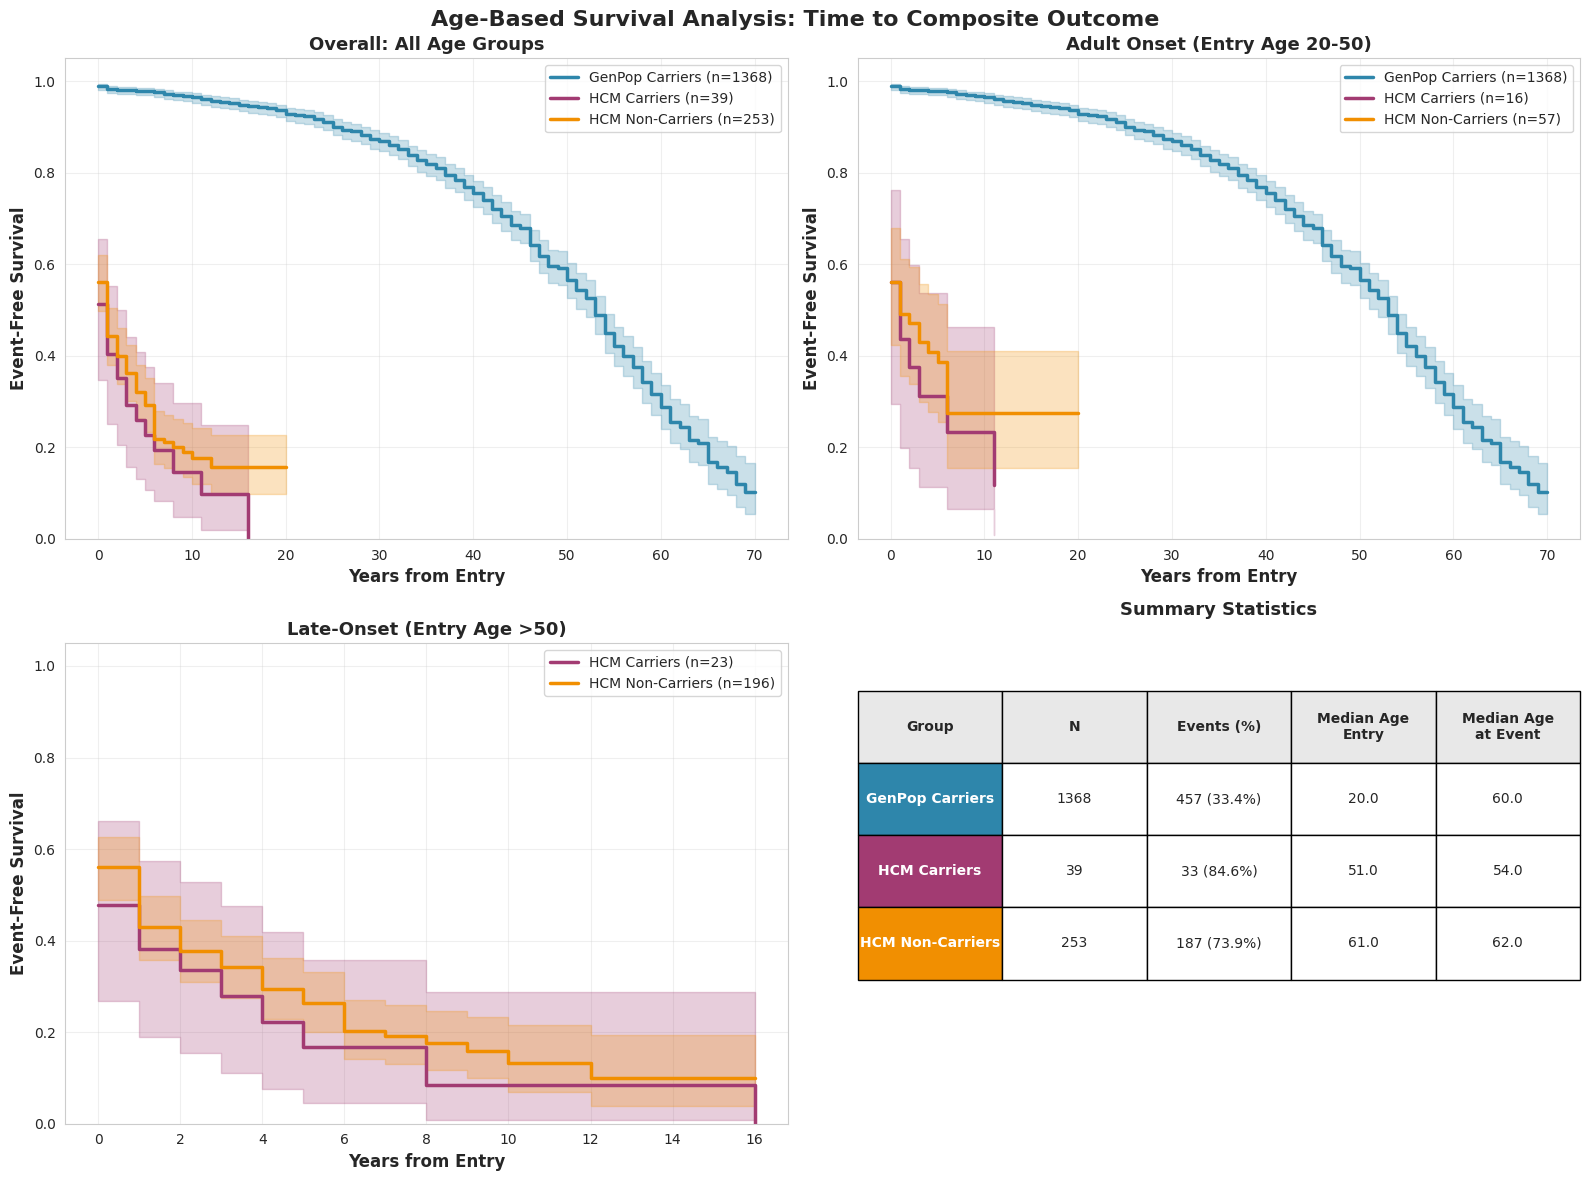

STEP 3: CALCULATING RMST (RESTRICTED MEAN SURVIVAL TIME)

RMST will be calculated at restriction times (tau):
  - τ = 5 years from entry
  - τ = 10 years from entry
  - τ = 20 years from entry
  - τ = 30 years from entry
RMST RESULTS BY GROUP AND RESTRICTION TIME

 Restriction Time τ = 5 years:
GenPop Carriers      | Mean Entry Age:  20.0 | RMST:   4.91 years
HCM Carriers         | Mean Entry Age:  48.2 | RMST:   1.68 years
HCM Non-Carriers     | Mean Entry Age:  59.6 | RMST:   1.95 years

 Restriction Time τ = 10 years:
GenPop Carriers      | Mean Entry Age:  20.0 | RMST:   9.76 years
HCM Carriers         | Mean Entry Age:  48.2 | RMST:   2.55 years
HCM Non-Carriers     | Mean Entry Age:  59.6 | RMST:   3.01 years

 Restriction Time τ = 20 years:
GenPop Carriers      | Mean Entry Age:  20.0 | RMST:  19.25 years
HCM Carriers         | Mean Entry Age:  48.2 | RMST:   2.86 years
HCM Non-Carriers     | Mean Entry Age:  59.6 | RMST:   4.61 years

 Restriction Time τ = 30 years:
GenPop Carr

/var/tmp/ipykernel_5108/1168272787.py:230: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_trunc, times_trunc)
/var/tmp/ipykernel_5108/1168272787.py:230: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_trunc, times_trunc)
/var/tmp/ipykernel_5108/1168272787.py:230: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_trunc, times_trunc)
/var/tmp/ipykernel_5108/1168272787.py:230: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_trunc, times_trunc)
/var/tmp/ipykernel_5108/1168272787.py:230: DeprecationWarning: `trapz` is deprecated. Use `trape

In [21]:
import numpy as np
from scipy import stats
from lifelines import KaplanMeierFitter
from lifelines.statistics import survival_difference_at_fixed_point_in_time_test
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# STEP 1: USE CLEANED DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 1: USING CLEANED DATA FOR RMST ANALYSIS")
print("="*80)

print(f"\nCombined clean dataset: {len(df_combined_clean)} patients")
print(f"  - GenPop Carriers: {len(df_genpop_carriers_clean)}")
print(f"  - HCM Carriers: {len(df_hcm_carriers_clean)}")
print(f"  - HCM Non-Carriers: {len(df_hcm_noncarriers_clean)}")

# Verify no NaN values
print(f"\n Data Quality Check:")
print(f"  NaN in followup_years: {df_combined_clean['followup_years'].isna().sum()}")
print(f"  NaN in composite_event: {df_combined_clean['composite_event'].isna().sum()}")
print(f"  NaN in age_at_entry: {df_combined_clean['age_at_entry'].isna().sum()}")

# ============================================================================
# STEP 2: KAPLAN-MEIER SURVIVAL CURVES
# ============================================================================

print("STEP 2: KAPLAN-MEIER SURVIVAL CURVES")

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Age-Based Survival Analysis: Time to Composite Outcome', fontsize=16, fontweight='bold')

# Define colors for groups
colors = {
    'GenPop Carriers': '#2E86AB',
    'HCM Carriers': '#A23B72',
    'HCM Non-Carriers': '#F18F01'
}

# ============================================================================
# SUBPLOT 1: Overall Survival (All Groups)
# ============================================================================

ax1 = axes[0, 0]
kmf = KaplanMeierFitter()

for group_name in ['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers']:
    df_group = df_combined_clean[df_combined_clean['group'] == group_name]
    
    durations = df_group['followup_years']
    events = df_group['composite_event']
    
    kmf.fit(durations, events, label=f'{group_name} (n={len(df_group)})')
    kmf.plot_survival_function(ax=ax1, ci_show=True, color=colors[group_name], linewidth=2.5)

ax1.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax1.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax1.set_title('Overall: All Age Groups', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_ylim([0, 1.05])

# ============================================================================
# SUBPLOT 2: Adult (20-50) Age Group
# ============================================================================

ax2 = axes[0, 1]

df_adult = df_combined_clean[df_combined_clean['age_group'] == 'Adult (20-50)']

for group_name in ['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers']:
    df_group = df_adult[df_adult['group'] == group_name]
    
    if len(df_group) > 0:
        durations = df_group['followup_years']
        events = df_group['composite_event']
        
        kmf.fit(durations, events, label=f'{group_name} (n={len(df_group)})')
        kmf.plot_survival_function(ax=ax2, ci_show=True, color=colors[group_name], linewidth=2.5)

ax2.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax2.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax2.set_title('Adult Onset (Entry Age 20-50)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)
ax2.set_ylim([0, 1.05])

# ============================================================================
# SUBPLOT 3: Late-Onset (>50) Age Group
# ============================================================================

ax3 = axes[1, 0]

df_late = df_combined_clean[df_combined_clean['age_group'] == 'Late-onset (>50)']

for group_name in ['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers']:
    df_group = df_late[df_late['group'] == group_name]
    
    if len(df_group) > 0:
        durations = df_group['followup_years']
        events = df_group['composite_event']
        
        kmf.fit(durations, events, label=f'{group_name} (n={len(df_group)})')
        kmf.plot_survival_function(ax=ax3, ci_show=True, color=colors[group_name], linewidth=2.5)

ax3.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax3.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax3.set_title('Late-Onset (Entry Age >50)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best', fontsize=10)
ax3.set_ylim([0, 1.05])

# ============================================================================
# SUBPLOT 4: Summary Statistics Table
# ============================================================================

ax4 = axes[1, 1]
ax4.axis('off')

# Create summary statistics
summary_stats = []
for group_name in ['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers']:
    df_group = df_combined_clean[df_combined_clean['group'] == group_name]
    
    n = len(df_group)
    events = df_group['composite_event'].sum()
    event_rate = 100 * events / n
    median_age_entry = df_group['age_at_entry'].median()
    median_age_event = df_group[df_group['composite_event']==1]['age_at_composite_end'].median()
    
    summary_stats.append([
        group_name,
        f"{n}",
        f"{events} ({event_rate:.1f}%)",
        f"{median_age_entry:.1f}",
        f"{median_age_event:.1f}" if not pd.isna(median_age_event) else "N/A"
    ])

# Create table
table = ax4.table(cellText=summary_stats,
                  colLabels=['Group', 'N', 'Events (%)', 'Median Age\nEntry', 'Median Age\nat Event'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0.3, 1, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(5):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color rows by group
for i, group_name in enumerate(['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers'], 1):
    table[(i, 0)].set_facecolor(colors[group_name])
    table[(i, 0)].set_text_props(color='white', weight='bold')

ax4.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('kmplot_3group_age_based.png', dpi=300, bbox_inches='tight')
print("\n Kaplan-Meier plots saved as 'kmplot_3group_age_based.png'")
plt.show()

# ============================================================================
# STEP 3: CALCULATE RMST (Restricted Mean Survival Time)
# ============================================================================

print("STEP 3: CALCULATING RMST (RESTRICTED MEAN SURVIVAL TIME)")

# Define restriction times (tau) for RMST calculation
tau_values = [5, 10, 20, 30]

print("\nRMST will be calculated at restriction times (tau):")
for tau in tau_values:
    print(f"  - τ = {tau} years from entry")

# Store RMST results
rmst_results = []

print("RMST RESULTS BY GROUP AND RESTRICTION TIME")

for tau in tau_values:
    print(f"\n Restriction Time τ = {tau} years:")
    
    for group_name in ['GenPop Carriers', 'HCM Carriers', 'HCM Non-Carriers']:
        df_group = df_combined_clean[df_combined_clean['group'] == group_name]
        
        durations = df_group['followup_years']
        events = df_group['composite_event']
        
        # Fit KM
        kmf = KaplanMeierFitter()
        kmf.fit(durations, events, label=group_name)
        
        # Calculate mean entry age for this group
        mean_entry = df_group['age_at_entry'].mean()
        
        try:
            # Calculate area under curve up to tau years from entry
            survival_func = kmf.survival_function_
            times = survival_func.index.values
            survival_probs = survival_func.iloc[:, 0].values
            
            # Truncate at tau
            mask = times <= tau
            times_trunc = times[mask]
            survival_trunc = survival_probs[mask]
            
            # Add point at tau if needed
            if len(times_trunc) == 0 or times_trunc[-1] < tau:
                if len(times_trunc) > 0:
                    last_surv = survival_trunc[-1] if len(survival_trunc) > 0 else 1.0
                else:
                    last_surv = 1.0
                times_trunc = np.append(times_trunc, tau)
                survival_trunc = np.append(survival_trunc, last_surv)
            
            # Calculate RMST as area under curve (trapezoidal integration)
            rmst = np.trapz(survival_trunc, times_trunc)
            
            print(f"{group_name:20s} | Mean Entry Age: {mean_entry:5.1f} | RMST: {rmst:6.2f} years")
            
            rmst_results.append({
                'tau': tau,
                'group': group_name,
                'n': len(df_group),
                'events': events.sum(),
                'mean_entry_age': mean_entry,
                'rmst_years': rmst
            })
            
        except Exception as e:
            print(f"{group_name:20s} | Could not calculate RMST: {str(e)}")
            rmst_results.append({
                'tau': tau,
                'group': group_name,
                'n': len(df_group),
                'events': events.sum(),
                'mean_entry_age': mean_entry,
                'rmst_years': np.nan
            })

# Create RMST summary dataframe
df_rmst = pd.DataFrame(rmst_results)

print("RMST SUMMARY TABLE")
print(df_rmst.to_string(index=False))

# ============================================================================
# STEP 4: PAIRWISE RMST COMPARISONS
# ============================================================================
print("STEP 4: PAIRWISE RMST DIFFERENCES")

comparisons = [
    ('HCM Carriers', 'GenPop Carriers'),
    ('HCM Non-Carriers', 'GenPop Carriers'),
    ('HCM Carriers', 'HCM Non-Carriers')
]

print("\nRMST Differences (Group1 - Group2):")

for tau in tau_values:
    print(f"\nAt τ = {tau} years:")
    df_tau = df_rmst[df_rmst['tau'] == tau]
    
    for group1, group2 in comparisons:
        rmst1 = df_tau[df_tau['group'] == group1]['rmst_years'].values
        rmst2 = df_tau[df_tau['group'] == group2]['rmst_years'].values
        
        if len(rmst1) > 0 and len(rmst2) > 0 and not np.isnan(rmst1[0]) and not np.isnan(rmst2[0]):
            diff = rmst1[0] - rmst2[0]
            pct_diff = 100 * diff / rmst2[0]
            print(f"  {group1:20s} vs {group2:20s}: {diff:+7.2f} years ({pct_diff:+6.1f}%)")

HCM CARRIERS vs NON-CARRIERS: COMPARATIVE OUTCOMES ANALYSIS
STEP 1: HCM COHORT CHARACTERISTICS

 Total HCM Patients: 292
  - Carriers: 39 (13.4%)
  - Non-Carriers: 253 (86.6%)
BASELINE CHARACTERISTICS
      Group   N  Mean_Age_Entry  SD_Age_Entry  Median_Age_Entry Female_%  Mean_Followup_Years  Median_Followup_Years  Max_Followup_Years
    Carrier  39            48.2          16.2              51.0      N/A                 2.38                    0.0                  16
Non-Carrier 253            59.6          13.8              61.0      N/A                 2.49                    1.0                  20

 Age at Entry Comparison:
  T-test p-value: 0.0000
  Mann-Whitney U p-value: 0.0000
STEP 2: EVENT RATES AND FIRST EVENT TYPES

Event Summary:
      Group   N  Events  Event_Rate_%  MACE_n  MACE_%  Intervention_n  Intervention_%  Death_n  Death_%
    Carrier  39      33          84.6      31    93.9               2             6.1        0      0.0
Non-Carrier 253     187          73.9

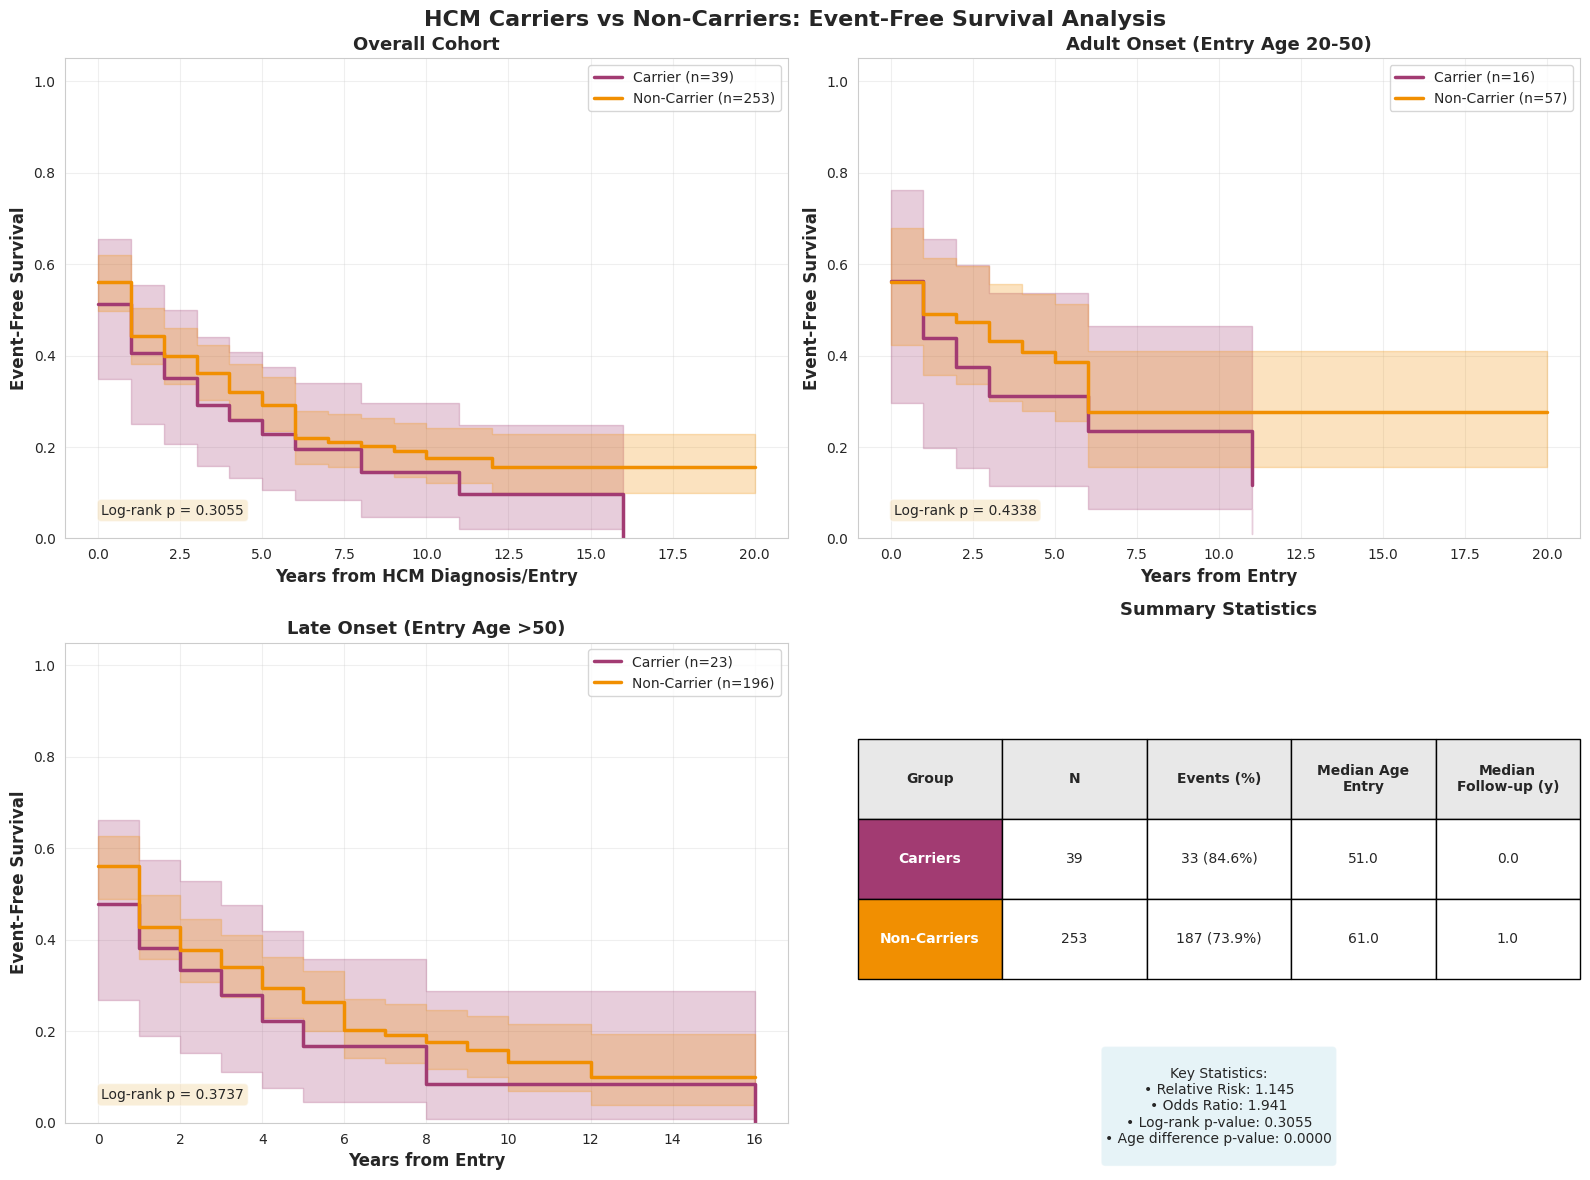

 KAPLAN-MEIER ANALYSIS COMPLETE


In [23]:
print("HCM CARRIERS vs NON-CARRIERS: COMPARATIVE OUTCOMES ANALYSIS")

import numpy as np
import pandas as pd
from scipy import stats
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# ============================================================================
# STEP 1: PREPARE HCM-ONLY DATASET
# ============================================================================
print("STEP 1: HCM COHORT CHARACTERISTICS")

# Create HCM-only combined dataset
df_hcm_only = pd.concat([
    df_hcm_carriers_clean.assign(carrier_status='Carrier'),
    df_hcm_noncarriers_clean.assign(carrier_status='Non-Carrier')
], ignore_index=True)

print(f"\n Total HCM Patients: {len(df_hcm_only)}")
print(f"  - Carriers: {len(df_hcm_carriers_clean)} ({100*len(df_hcm_carriers_clean)/len(df_hcm_only):.1f}%)")
print(f"  - Non-Carriers: {len(df_hcm_noncarriers_clean)} ({100*len(df_hcm_noncarriers_clean)/len(df_hcm_only):.1f}%)")

# Baseline characteristics comparison
print("BASELINE CHARACTERISTICS")

baseline_stats = []
for carrier_status in ['Carrier', 'Non-Carrier']:
    df_group = df_hcm_only[df_hcm_only['carrier_status'] == carrier_status]
    
    baseline_stats.append({
        'Group': carrier_status,
        'N': len(df_group),
        'Mean_Age_Entry': round(df_group['age_at_entry'].mean(), 1),
        'SD_Age_Entry': round(df_group['age_at_entry'].std(), 1),
        'Median_Age_Entry': round(df_group['age_at_entry'].median(), 1),
        'Female_%': round(100 * (df_group['sex'] == 'Female').mean(), 1) if 'sex' in df_group.columns else 'N/A',
        'Mean_Followup_Years': round(df_group['followup_years'].mean(), 2),
        'Median_Followup_Years': round(df_group['followup_years'].median(), 2),
        'Max_Followup_Years': round(df_group['followup_years'].max(), 2)
    })

df_baseline = pd.DataFrame(baseline_stats)
print(df_baseline.to_string(index=False))

# Statistical test for age difference
from scipy.stats import ttest_ind, mannwhitneyu

age_carriers = df_hcm_carriers_clean['age_at_entry']
age_noncarriers = df_hcm_noncarriers_clean['age_at_entry']

t_stat, p_val_ttest = ttest_ind(age_carriers, age_noncarriers)
u_stat, p_val_mw = mannwhitneyu(age_carriers, age_noncarriers)

print(f"\n Age at Entry Comparison:")
print(f"  T-test p-value: {p_val_ttest:.4f}")
print(f"  Mann-Whitney U p-value: {p_val_mw:.4f}")

# ============================================================================
# STEP 2: EVENT RATES AND TYPES
# ============================================================================

print("STEP 2: EVENT RATES AND FIRST EVENT TYPES")

event_summary = []
for carrier_status in ['Carrier', 'Non-Carrier']:
    df_group = df_hcm_only[df_hcm_only['carrier_status'] == carrier_status]
    
    n_events = df_group['composite_event'].sum()
    event_rate = 100 * n_events / len(df_group)
    
    # Event types
    events_by_type = df_group[df_group['composite_event'] == 1]['first_event_type'].value_counts()
    
    event_summary.append({
        'Group': carrier_status,
        'N': len(df_group),
        'Events': n_events,
        'Event_Rate_%': round(event_rate, 1),
        'MACE_n': events_by_type.get('MACE', 0),
        'MACE_%': round(100 * events_by_type.get('MACE', 0) / n_events, 1) if n_events > 0 else 0,
        'Intervention_n': events_by_type.get('Intervention', 0),
        'Intervention_%': round(100 * events_by_type.get('Intervention', 0) / n_events, 1) if n_events > 0 else 0,
        'Death_n': events_by_type.get('Death', 0),
        'Death_%': round(100 * events_by_type.get('Death', 0) / n_events, 1) if n_events > 0 else 0
    })

df_event_summary = pd.DataFrame(event_summary)
print("\nEvent Summary:")
print(df_event_summary.to_string(index=False))

# Chi-square test for event rate difference
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_hcm_only['carrier_status'], df_hcm_only['composite_event'])
chi2, p_val_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"\n Event Rate Comparison:")
print(f"  Chi-square test p-value: {p_val_chi2:.4f}")

# Relative risk and odds ratio
carriers_events = df_hcm_carriers_clean['composite_event'].sum()
carriers_total = len(df_hcm_carriers_clean)
noncarriers_events = df_hcm_noncarriers_clean['composite_event'].sum()
noncarriers_total = len(df_hcm_noncarriers_clean)

risk_carriers = carriers_events / carriers_total
risk_noncarriers = noncarriers_events / noncarriers_total
relative_risk = risk_carriers / risk_noncarriers

odds_carriers = carriers_events / (carriers_total - carriers_events)
odds_noncarriers = noncarriers_events / (noncarriers_total - noncarriers_events)
odds_ratio = odds_carriers / odds_noncarriers

print(f"\n Risk Metrics:")
print(f"  Carriers event rate: {100*risk_carriers:.1f}%")
print(f"  Non-Carriers event rate: {100*risk_noncarriers:.1f}%")
print(f"  Relative Risk (Carrier/Non-Carrier): {relative_risk:.3f}")
print(f"  Odds Ratio (Carrier/Non-Carrier): {odds_ratio:.3f}")

# ============================================================================
# STEP 3: KAPLAN-MEIER SURVIVAL ANALYSIS
# ============================================================================

print("STEP 3: KAPLAN-MEIER SURVIVAL ANALYSIS")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('HCM Carriers vs Non-Carriers: Event-Free Survival Analysis', 
             fontsize=16, fontweight='bold')

colors = {
    'Carrier': '#A23B72',
    'Non-Carrier': '#F18F01'
}

kmf = KaplanMeierFitter()

# ============================================================================
# SUBPLOT 1: Overall Survival
# ============================================================================

ax1 = axes[0, 0]

for carrier_status in ['Carrier', 'Non-Carrier']:
    df_group = df_hcm_only[df_hcm_only['carrier_status'] == carrier_status]
    
    kmf.fit(df_group['followup_years'], 
            df_group['composite_event'], 
            label=f'{carrier_status} (n={len(df_group)})')
    kmf.plot_survival_function(ax=ax1, ci_show=True, color=colors[carrier_status], linewidth=2.5)

ax1.set_xlabel('Years from HCM Diagnosis/Entry', fontsize=12, fontweight='bold')
ax1.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax1.set_title('Overall Cohort', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_ylim([0, 1.05])

# Log-rank test
results = logrank_test(
    df_hcm_carriers_clean['followup_years'],
    df_hcm_noncarriers_clean['followup_years'],
    df_hcm_carriers_clean['composite_event'],
    df_hcm_noncarriers_clean['composite_event']
)

ax1.text(0.05, 0.05, f'Log-rank p = {results.p_value:.4f}', 
         transform=ax1.transAxes, fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

print(f"\n Overall Log-rank Test:")
print(f"  Test statistic: {results.test_statistic:.3f}")
print(f"  P-value: {results.p_value:.4f}")

# ============================================================================
# SUBPLOT 2: Adult Onset (20-50)
# ============================================================================

ax2 = axes[0, 1]

df_adult = df_hcm_only[df_hcm_only['age_group'] == 'Adult (20-50)']

for carrier_status in ['Carrier', 'Non-Carrier']:
    df_group = df_adult[df_adult['carrier_status'] == carrier_status]
    
    if len(df_group) > 0:
        kmf.fit(df_group['followup_years'], 
                df_group['composite_event'], 
                label=f'{carrier_status} (n={len(df_group)})')
        kmf.plot_survival_function(ax=ax2, ci_show=True, color=colors[carrier_status], linewidth=2.5)

ax2.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax2.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax2.set_title('Adult Onset (Entry Age 20-50)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)
ax2.set_ylim([0, 1.05])

# Log-rank for adult subgroup
df_adult_carrier = df_adult[df_adult['carrier_status'] == 'Carrier']
df_adult_noncarrier = df_adult[df_adult['carrier_status'] == 'Non-Carrier']

if len(df_adult_carrier) > 0 and len(df_adult_noncarrier) > 0:
    results_adult = logrank_test(
        df_adult_carrier['followup_years'],
        df_adult_noncarrier['followup_years'],
        df_adult_carrier['composite_event'],
        df_adult_noncarrier['composite_event']
    )
    ax2.text(0.05, 0.05, f'Log-rank p = {results_adult.p_value:.4f}', 
             transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# SUBPLOT 3: Late Onset (>50)
# ============================================================================

ax3 = axes[1, 0]

df_late = df_hcm_only[df_hcm_only['age_group'] == 'Late-onset (>50)']

for carrier_status in ['Carrier', 'Non-Carrier']:
    df_group = df_late[df_late['carrier_status'] == carrier_status]
    
    if len(df_group) > 0:
        kmf.fit(df_group['followup_years'], 
                df_group['composite_event'], 
                label=f'{carrier_status} (n={len(df_group)})')
        kmf.plot_survival_function(ax=ax3, ci_show=True, color=colors[carrier_status], linewidth=2.5)

ax3.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax3.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax3.set_title('Late Onset (Entry Age >50)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best', fontsize=10)
ax3.set_ylim([0, 1.05])

# Log-rank for late-onset subgroup
df_late_carrier = df_late[df_late['carrier_status'] == 'Carrier']
df_late_noncarrier = df_late[df_late['carrier_status'] == 'Non-Carrier']

if len(df_late_carrier) > 0 and len(df_late_noncarrier) > 0:
    results_late = logrank_test(
        df_late_carrier['followup_years'],
        df_late_noncarrier['followup_years'],
        df_late_carrier['composite_event'],
        df_late_noncarrier['composite_event']
    )
    ax3.text(0.05, 0.05, f'Log-rank p = {results_late.p_value:.4f}', 
             transform=ax3.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# SUBPLOT 4: Summary Table
# ============================================================================

ax4 = axes[1, 1]
ax4.axis('off')

# Median survival times
median_survival_carrier = df_hcm_carriers_clean[df_hcm_carriers_clean['composite_event']==0]['followup_years'].median()
median_survival_noncarrier = df_hcm_noncarriers_clean[df_hcm_noncarriers_clean['composite_event']==0]['followup_years'].median()

summary_table_data = [
    ['Carriers', len(df_hcm_carriers_clean), 
     f"{df_hcm_carriers_clean['composite_event'].sum()} ({100*df_hcm_carriers_clean['composite_event'].mean():.1f}%)",
     f"{df_hcm_carriers_clean['age_at_entry'].median():.1f}",
     f"{df_hcm_carriers_clean['followup_years'].median():.1f}"],
    ['Non-Carriers', len(df_hcm_noncarriers_clean),
     f"{df_hcm_noncarriers_clean['composite_event'].sum()} ({100*df_hcm_noncarriers_clean['composite_event'].mean():.1f}%)",
     f"{df_hcm_noncarriers_clean['age_at_entry'].median():.1f}",
     f"{df_hcm_noncarriers_clean['followup_years'].median():.1f}"]
]

table = ax4.table(cellText=summary_table_data,
                  colLabels=['Group', 'N', 'Events (%)', 'Median Age\nEntry', 'Median\nFollow-up (y)'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0.3, 1, 0.5])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(5):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color rows
table[(1, 0)].set_facecolor(colors['Carrier'])
table[(1, 0)].set_text_props(color='white', weight='bold')
table[(2, 0)].set_facecolor(colors['Non-Carrier'])
table[(2, 0)].set_text_props(color='white', weight='bold')

# Add statistics below table
stats_text = f"""
Key Statistics:
• Relative Risk: {relative_risk:.3f}
• Odds Ratio: {odds_ratio:.3f}
• Log-rank p-value: {results.p_value:.4f}
• Age difference p-value: {p_val_mw:.4f}
"""

ax4.text(0.5, 0.15, stats_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

ax4.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('hcm_carriers_vs_noncarriers_survival.png', dpi=300, bbox_inches='tight')
print("\n Kaplan-Meier plot saved as 'hcm_carriers_vs_noncarriers_survival.png'")
plt.show()
print(" KAPLAN-MEIER ANALYSIS COMPLETE")

 PREPARING DATA FOR COX REGRESSION

 Data Quality Check:
  Total patients: 292
  Missing followup_years: 0
  Missing composite_event: 0
  Missing age_at_entry: 0
  Missing is_carrier: 0
 UNIVARIATE COX REGRESSION MODELS

 MODEL 1: Carrier Status (Unadjusted)
                coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                   
is_carrier  0.180242   1.197508  0.188905       -0.190005        0.550489   

                   p  
covariate             
is_carrier  0.340011  

Hazard Ratio (Carrier vs Non-Carrier): 1.198
95% CI: [0.827, 1.734]
P-value: 0.3400

 MODEL 2: Age at Entry (Unadjusted)
                  coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                     
age_at_entry  0.005302   1.005316  0.004459       -0.003437        0.014041   

                     p  
covariate               
age_at_entry  0.234396  

Haza

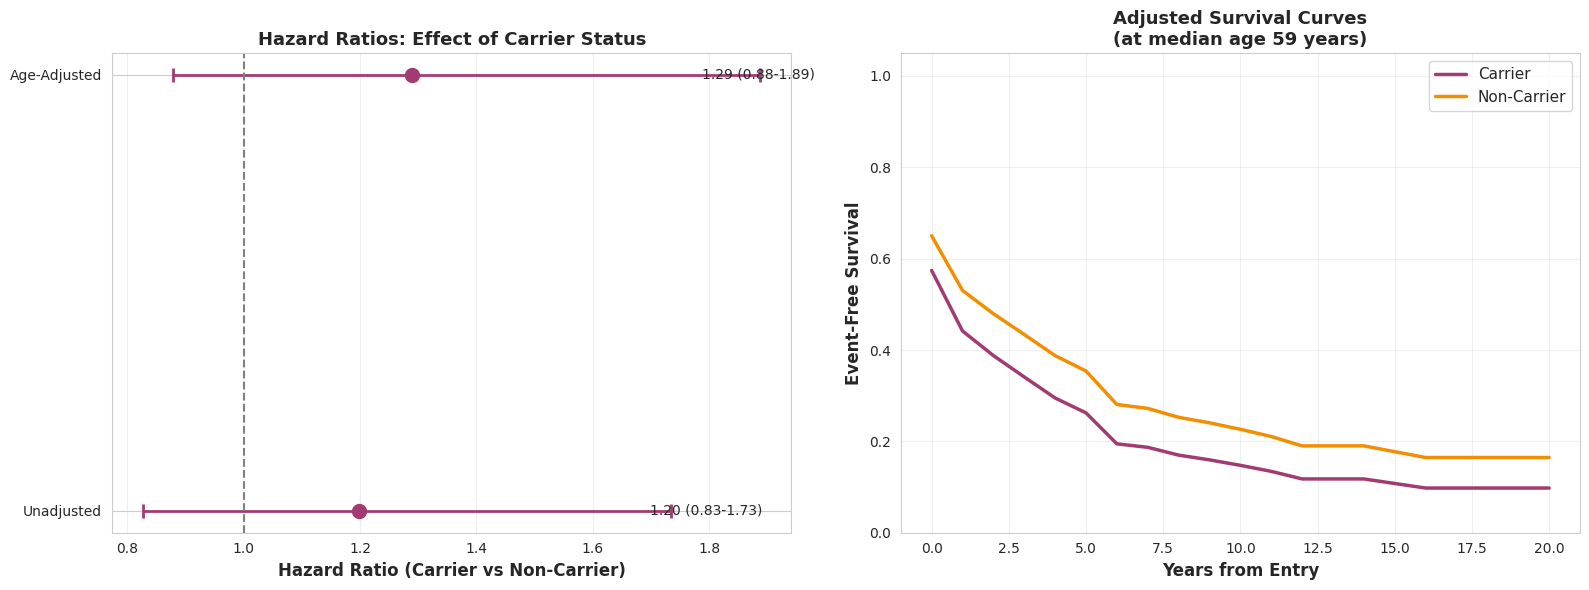


KEY FINDINGS:

1. UNADJUSTED ANALYSIS:
   - Carrier HR: 1.198 (95% CI: 0.827-1.734)
   - P-value: 0.3400
   - Interpretation: NOT significant

2. AGE-ADJUSTED ANALYSIS:
   - Carrier HR: 1.289 (95% CI: 0.879-1.888)
   - P-value: 0.1935
   - Interpretation: NOT significant
   
   - Age HR (per 10 years): 1.069 (95% CI: 0.977-1.169)
   - Age P-value: 0.1439



In [28]:

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import pandas as pd
import numpy as np

# ============================================================================
#  PREPARE DATA FOR COX REGRESSION
# ============================================================================
print(" PREPARING DATA FOR COX REGRESSION")

# Create analysis dataset
df_cox = df_hcm_only.copy()

# Create binary carrier variable (1 = Carrier, 0 = Non-Carrier)
df_cox['is_carrier'] = (df_cox['carrier_status'] == 'Carrier').astype(int)

# Check for missing values in key variables
print(f"\n Data Quality Check:")
print(f"  Total patients: {len(df_cox)}")
print(f"  Missing followup_years: {df_cox['followup_years'].isna().sum()}")
print(f"  Missing composite_event: {df_cox['composite_event'].isna().sum()}")
print(f"  Missing age_at_entry: {df_cox['age_at_entry'].isna().sum()}")
print(f"  Missing is_carrier: {df_cox['is_carrier'].isna().sum()}")

# ============================================================================
# UNIVARIATE COX MODELS
# ============================================================================
print(" UNIVARIATE COX REGRESSION MODELS")

# Model 1: Carrier status only (unadjusted)
print("\n MODEL 1: Carrier Status (Unadjusted)")
cph1 = CoxPHFitter()
cph1.fit(df_cox[['followup_years', 'composite_event', 'is_carrier']], 
         duration_col='followup_years', 
         event_col='composite_event')

print(cph1.summary[['coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'p']])
print(f"\nHazard Ratio (Carrier vs Non-Carrier): {cph1.summary.loc['is_carrier', 'exp(coef)']:.3f}")
print(f"95% CI: [{np.exp(cph1.summary.loc['is_carrier', 'coef lower 95%']):.3f}, {np.exp(cph1.summary.loc['is_carrier', 'coef upper 95%']):.3f}]")
print(f"P-value: {cph1.summary.loc['is_carrier', 'p']:.4f}")

# Model 2: Age only
print("\n MODEL 2: Age at Entry (Unadjusted)")

cph2 = CoxPHFitter()
cph2.fit(df_cox[['followup_years', 'composite_event', 'age_at_entry']], 
         duration_col='followup_years', 
         event_col='composite_event')

print(cph2.summary[['coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'p']])
print(f"\nHazard Ratio (per 1-year increase in age): {cph2.summary.loc['age_at_entry', 'exp(coef)']:.3f}")
print(f"95% CI: [{np.exp(cph2.summary.loc['age_at_entry', 'coef lower 95%']):.3f}, {np.exp(cph2.summary.loc['age_at_entry', 'coef upper 95%']):.3f}]")
print(f"P-value: {cph2.summary.loc['age_at_entry', 'p']:.4f}")

# Interpret per 10-year increase
hr_10year = cph2.summary.loc['age_at_entry', 'exp(coef)'] ** 10
hr_10year_lower = np.exp(cph2.summary.loc['age_at_entry', 'coef lower 95%']) ** 10
hr_10year_upper = np.exp(cph2.summary.loc['age_at_entry', 'coef upper 95%']) ** 10
print(f"\nHazard Ratio (per 10-year increase in age): {hr_10year:.3f}")
print(f"95% CI: [{hr_10year_lower:.3f}, {hr_10year_upper:.3f}]")

# ============================================================================
# MULTIVARIABLE COX MODEL (ADJUSTED FOR AGE)
# ============================================================================

print(" MULTIVARIABLE COX REGRESSION (AGE-ADJUSTED)")

print("\n MODEL 3: Carrier Status ADJUSTED for Age at Entry")

cph3 = CoxPHFitter()
cph3.fit(df_cox[['followup_years', 'composite_event', 'is_carrier', 'age_at_entry']], 
         duration_col='followup_years', 
         event_col='composite_event')

print(cph3.summary[['coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'p']])

print(f"\n ADJUSTED Results:")
print(f"\nCarrier Status (adjusted for age):")
print(f"  Hazard Ratio: {cph3.summary.loc['is_carrier', 'exp(coef)']:.3f}")
print(f"  95% CI: [{np.exp(cph3.summary.loc['is_carrier', 'coef lower 95%']):.3f}, {np.exp(cph3.summary.loc['is_carrier', 'coef upper 95%']):.3f}]")
print(f"  P-value: {cph3.summary.loc['is_carrier', 'p']:.4f}")

print(f"\nAge at Entry (adjusted for carrier status):")
print(f"  Hazard Ratio (per year): {cph3.summary.loc['age_at_entry', 'exp(coef)']:.3f}")
print(f"  95% CI: [{np.exp(cph3.summary.loc['age_at_entry', 'coef lower 95%']):.3f}, {np.exp(cph3.summary.loc['age_at_entry', 'coef upper 95%']):.3f}]")
print(f"  P-value: {cph3.summary.loc['age_at_entry', 'p']:.4f}")

# Interpret per 10-year increase for adjusted model
hr_10year_adj = cph3.summary.loc['age_at_entry', 'exp(coef)'] ** 10
hr_10year_lower_adj = np.exp(cph3.summary.loc['age_at_entry', 'coef lower 95%']) ** 10
hr_10year_upper_adj = np.exp(cph3.summary.loc['age_at_entry', 'coef upper 95%']) ** 10
print(f"\nAge at Entry (per 10-year increase):")
print(f"  Hazard Ratio: {hr_10year_adj:.3f}")
print(f"  95% CI: [{hr_10year_lower_adj:.3f}, {hr_10year_upper_adj:.3f}]")

# Model fit statistics
print(f"\n Model Fit Statistics:")
print(f"  Concordance Index: {cph3.concordance_index_:.3f}")
print(f"  Log-likelihood: {cph3.log_likelihood_:.2f}")
print(f"  Partial AIC: {cph3.AIC_partial_:.2f}")

# ============================================================================
#  CHECK PROPORTIONAL HAZARDS ASSUMPTION
# ============================================================================
print(" PROPORTIONAL HAZARDS ASSUMPTION TEST")

# Test proportional hazards assumption
ph_test = proportional_hazard_test(cph3, df_cox[['followup_years', 'composite_event', 'is_carrier', 'age_at_entry']], 
                                    time_transform='rank')

print("\n Schoenfeld Residuals Test:")
print(ph_test)

print("\n Interpretation:")
print("  - P-value > 0.05: Proportional hazards assumption is satisfied")
print("  - P-value < 0.05: May violate proportional hazards assumption")

# ============================================================================
# AGE-STRATIFIED ANALYSIS
# ============================================================================
print("AGE-STRATIFIED SUBGROUP ANALYSIS")

# Adult onset (20-50)
print("\n ADULT ONSET (Entry Age 20-50):")

df_adult = df_cox[df_cox['age_group'] == 'Adult (20-50)']
print(f"N = {len(df_adult)} (Carriers: {(df_adult['is_carrier']==1).sum()}, Non-Carriers: {(df_adult['is_carrier']==0).sum()})")

if len(df_adult) > 10 and df_adult['is_carrier'].sum() > 5:
    cph_adult = CoxPHFitter()
    cph_adult.fit(df_adult[['followup_years', 'composite_event', 'is_carrier', 'age_at_entry']], 
                  duration_col='followup_years', 
                  event_col='composite_event')
    
    print(f"Carrier HR (adjusted for age): {cph_adult.summary.loc['is_carrier', 'exp(coef)']:.3f}")
    print(f"95% CI: [{np.exp(cph_adult.summary.loc['is_carrier', 'coef lower 95%']):.3f}, {np.exp(cph_adult.summary.loc['is_carrier', 'coef upper 95%']):.3f}]")
    print(f"P-value: {cph_adult.summary.loc['is_carrier', 'p']:.4f}")
else:
    print("  Insufficient sample size for stratified analysis")

# Late onset (>50)
print("\n LATE ONSET (Entry Age >50):")

df_late = df_cox[df_cox['age_group'] == 'Late-onset (>50)']
print(f"N = {len(df_late)} (Carriers: {(df_late['is_carrier']==1).sum()}, Non-Carriers: {(df_late['is_carrier']==0).sum()})")

if len(df_late) > 10 and df_late['is_carrier'].sum() > 5:
    cph_late = CoxPHFitter()
    cph_late.fit(df_late[['followup_years', 'composite_event', 'is_carrier', 'age_at_entry']], 
                 duration_col='followup_years', 
                 event_col='composite_event')
    
    print(f"Carrier HR (adjusted for age): {cph_late.summary.loc['is_carrier', 'exp(coef)']:.3f}")
    print(f"95% CI: [{np.exp(cph_late.summary.loc['is_carrier', 'coef lower 95%']):.3f}, {np.exp(cph_late.summary.loc['is_carrier', 'coef upper 95%']):.3f}]")
    print(f"P-value: {cph_late.summary.loc['is_carrier', 'p']:.4f}")
else:
    print("  Insufficient sample size for stratified analysis")

# ============================================================================
#VISUALIZE COX REGRESSION RESULTS
# ============================================================================

print("VISUALIZING RESULTS")

# Create forest plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Hazard Ratios
ax1 = axes[0]

models = ['Unadjusted', 'Age-Adjusted']
hrs = [
    cph1.summary.loc['is_carrier', 'exp(coef)'],
    cph3.summary.loc['is_carrier', 'exp(coef)']
]
ci_lower = [
    np.exp(cph1.summary.loc['is_carrier', 'coef lower 95%']),
    np.exp(cph3.summary.loc['is_carrier', 'coef lower 95%'])
]
ci_upper = [
    np.exp(cph1.summary.loc['is_carrier', 'coef upper 95%']),
    np.exp(cph3.summary.loc['is_carrier', 'coef upper 95%'])
]

y_pos = np.arange(len(models))
ax1.errorbar(hrs, y_pos, xerr=[np.array(hrs) - np.array(ci_lower), np.array(ci_upper) - np.array(hrs)],
             fmt='o', markersize=10, capsize=5, capthick=2, linewidth=2, color='#A23B72')
ax1.axvline(x=1, color='gray', linestyle='--', linewidth=1.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models)
ax1.set_xlabel('Hazard Ratio (Carrier vs Non-Carrier)', fontsize=12, fontweight='bold')
ax1.set_title('Hazard Ratios: Effect of Carrier Status', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add HR values as text
for i, (hr, lower, upper) in enumerate(zip(hrs, ci_lower, ci_upper)):
    ax1.text(hr + 0.5, i, f'{hr:.2f} ({lower:.2f}-{upper:.2f})', 
             va='center', fontsize=10)

# Plot 2: Survival curves from Cox model
ax2 = axes[1]

# Create survival curves for carriers vs non-carriers at median age
median_age = df_cox['age_at_entry'].median()

# Carrier
df_carrier_predict = pd.DataFrame({'is_carrier': [1], 'age_at_entry': [median_age]})
carrier_surv = cph3.predict_survival_function(df_carrier_predict)

# Non-carrier
df_noncarrier_predict = pd.DataFrame({'is_carrier': [0], 'age_at_entry': [median_age]})
noncarrier_surv = cph3.predict_survival_function(df_noncarrier_predict)

ax2.plot(carrier_surv.index, carrier_surv.values[:, 0], 
         label='Carrier', color='#A23B72', linewidth=2.5)
ax2.plot(noncarrier_surv.index, noncarrier_surv.values[:, 0], 
         label='Non-Carrier', color='#F18F01', linewidth=2.5)

ax2.set_xlabel('Years from Entry', fontsize=12, fontweight='bold')
ax2.set_ylabel('Event-Free Survival', fontsize=12, fontweight='bold')
ax2.set_title(f'Adjusted Survival Curves\n(at median age {median_age:.0f} years)', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('cox_regression_results.png', dpi=300, bbox_inches='tight')
print("\n Cox regression plot saved as 'cox_regression_results.png'")
plt.show()

# ============================================================================
# SUMMARY OF FINDINGS
# ============================================================================

summary = f"""
KEY FINDINGS:

1. UNADJUSTED ANALYSIS:
   - Carrier HR: {cph1.summary.loc['is_carrier', 'exp(coef)']:.3f} (95% CI: {np.exp(cph1.summary.loc['is_carrier', 'coef lower 95%']):.3f}-{np.exp(cph1.summary.loc['is_carrier', 'coef upper 95%']):.3f})
   - P-value: {cph1.summary.loc['is_carrier', 'p']:.4f}
   - Interpretation: {"NOT significant" if cph1.summary.loc['is_carrier', 'p'] > 0.05 else "SIGNIFICANT"}

2. AGE-ADJUSTED ANALYSIS:
   - Carrier HR: {cph3.summary.loc['is_carrier', 'exp(coef)']:.3f} (95% CI: {np.exp(cph3.summary.loc['is_carrier', 'coef lower 95%']):.3f}-{np.exp(cph3.summary.loc['is_carrier', 'coef upper 95%']):.3f})
   - P-value: {cph3.summary.loc['is_carrier', 'p']:.4f}
   - Interpretation: {"NOT significant" if cph3.summary.loc['is_carrier', 'p'] > 0.05 else "SIGNIFICANT"}
   
   - Age HR (per 10 years): {hr_10year_adj:.3f} (95% CI: {hr_10year_lower_adj:.3f}-{hr_10year_upper_adj:.3f})
   - Age P-value: {cph3.summary.loc['age_at_entry', 'p']:.4f}
"""

print(summary)


In [29]:

print(" EVENT CATEGORIES IN HCM_ALL_COMPOSITE_EVENTS")

query_hcm_categories = f"""
SELECT 
    event_category,
    COUNT(*) as event_count,
    COUNT(DISTINCT person_id) as unique_patients
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_all_composite_events`
GROUP BY event_category
ORDER BY event_count DESC
"""

print("\n Querying HCM event categories...")
df_hcm_event_categories = client.query(query_hcm_categories).to_dataframe()

print(f"\nFound {len(df_hcm_event_categories)} unique event categories in HCM table:")
print("\n" + df_hcm_event_categories.to_string(index=False))

print("EVENT CATEGORIES IN GEN_POP_CARRIERS_ALL_COMPOSITE_EVENTS_DEDUP")

query_genpop_categories = f"""
SELECT 
    event_category,
    COUNT(*) as event_count,
    COUNT(DISTINCT person_id) as unique_patients
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
GROUP BY event_category
ORDER BY event_count DESC
"""

print("\n Querying Gen Pop Carrier event categories...")
df_genpop_event_categories = client.query(query_genpop_categories).to_dataframe()

print(f"\nFound {len(df_genpop_event_categories)} unique event categories in Gen Pop Carriers table:")
print("\n" + df_genpop_event_categories.to_string(index=False))

# ============================================================================
# STEP 3: SHOW ALL UNIQUE CATEGORIES ACROSS BOTH TABLES
# ============================================================================

print("STEP 3: ALL UNIQUE EVENT CATEGORIES (COMBINED)")
all_categories = pd.concat([
    df_hcm_event_categories[['event_category']],
    df_genpop_event_categories[['event_category']]
]).drop_duplicates().sort_values('event_category')

print(f"\nTotal unique event categories across both tables: {len(all_categories)}")
print("\n Complete list of event categories:")
for i, cat in enumerate(all_categories['event_category'].values, 1):
    print(f"{i}. {cat}")

 EVENT CATEGORIES IN HCM_ALL_COMPOSITE_EVENTS

 Querying HCM event categories...

Found 13 unique event categories in HCM table:

        event_category  event_count  unique_patients
         Heart Failure          155              155
   Atrial Fibrillation          137              137
Ventricular Arrhythmia           97               97
      ICD Implantation           61               61
      Pacemaker/Device           45               45
                 Death           43               43
      Septal Reduction           40               40
                Stroke           32               32
      Cardiac Ablation           25               25
        Cardiac Arrest           18               18
     Cardiogenic Shock           13               13
      Heart Transplant            9                9
              LVAD/VAD            3                3
EVENT CATEGORIES IN GEN_POP_CARRIERS_ALL_COMPOSITE_EVENTS_DEDUP

 Querying Gen Pop Carrier event categories...

Found 16 unique 

QUERYING EVENT COUNTS BY CARRIER STATUS

 Querying event counts by carrier status...

 Results:
 is_carrier         event_category  patients_with_event  total_events
      False    Atrial Fibrillation                  117           117
      False       Cardiac Ablation                   19            19
      False         Cardiac Arrest                   16            16
      False      Cardiogenic Shock                   10            10
      False                  Death                   38            38
      False          Heart Failure                  134           134
      False       Heart Transplant                    6             6
      False       ICD Implantation                   41            41
      False               LVAD/VAD                    2             2
      False       Pacemaker/Device                   38            38
      False       Septal Reduction                   32            32
      False                 Stroke                   26         

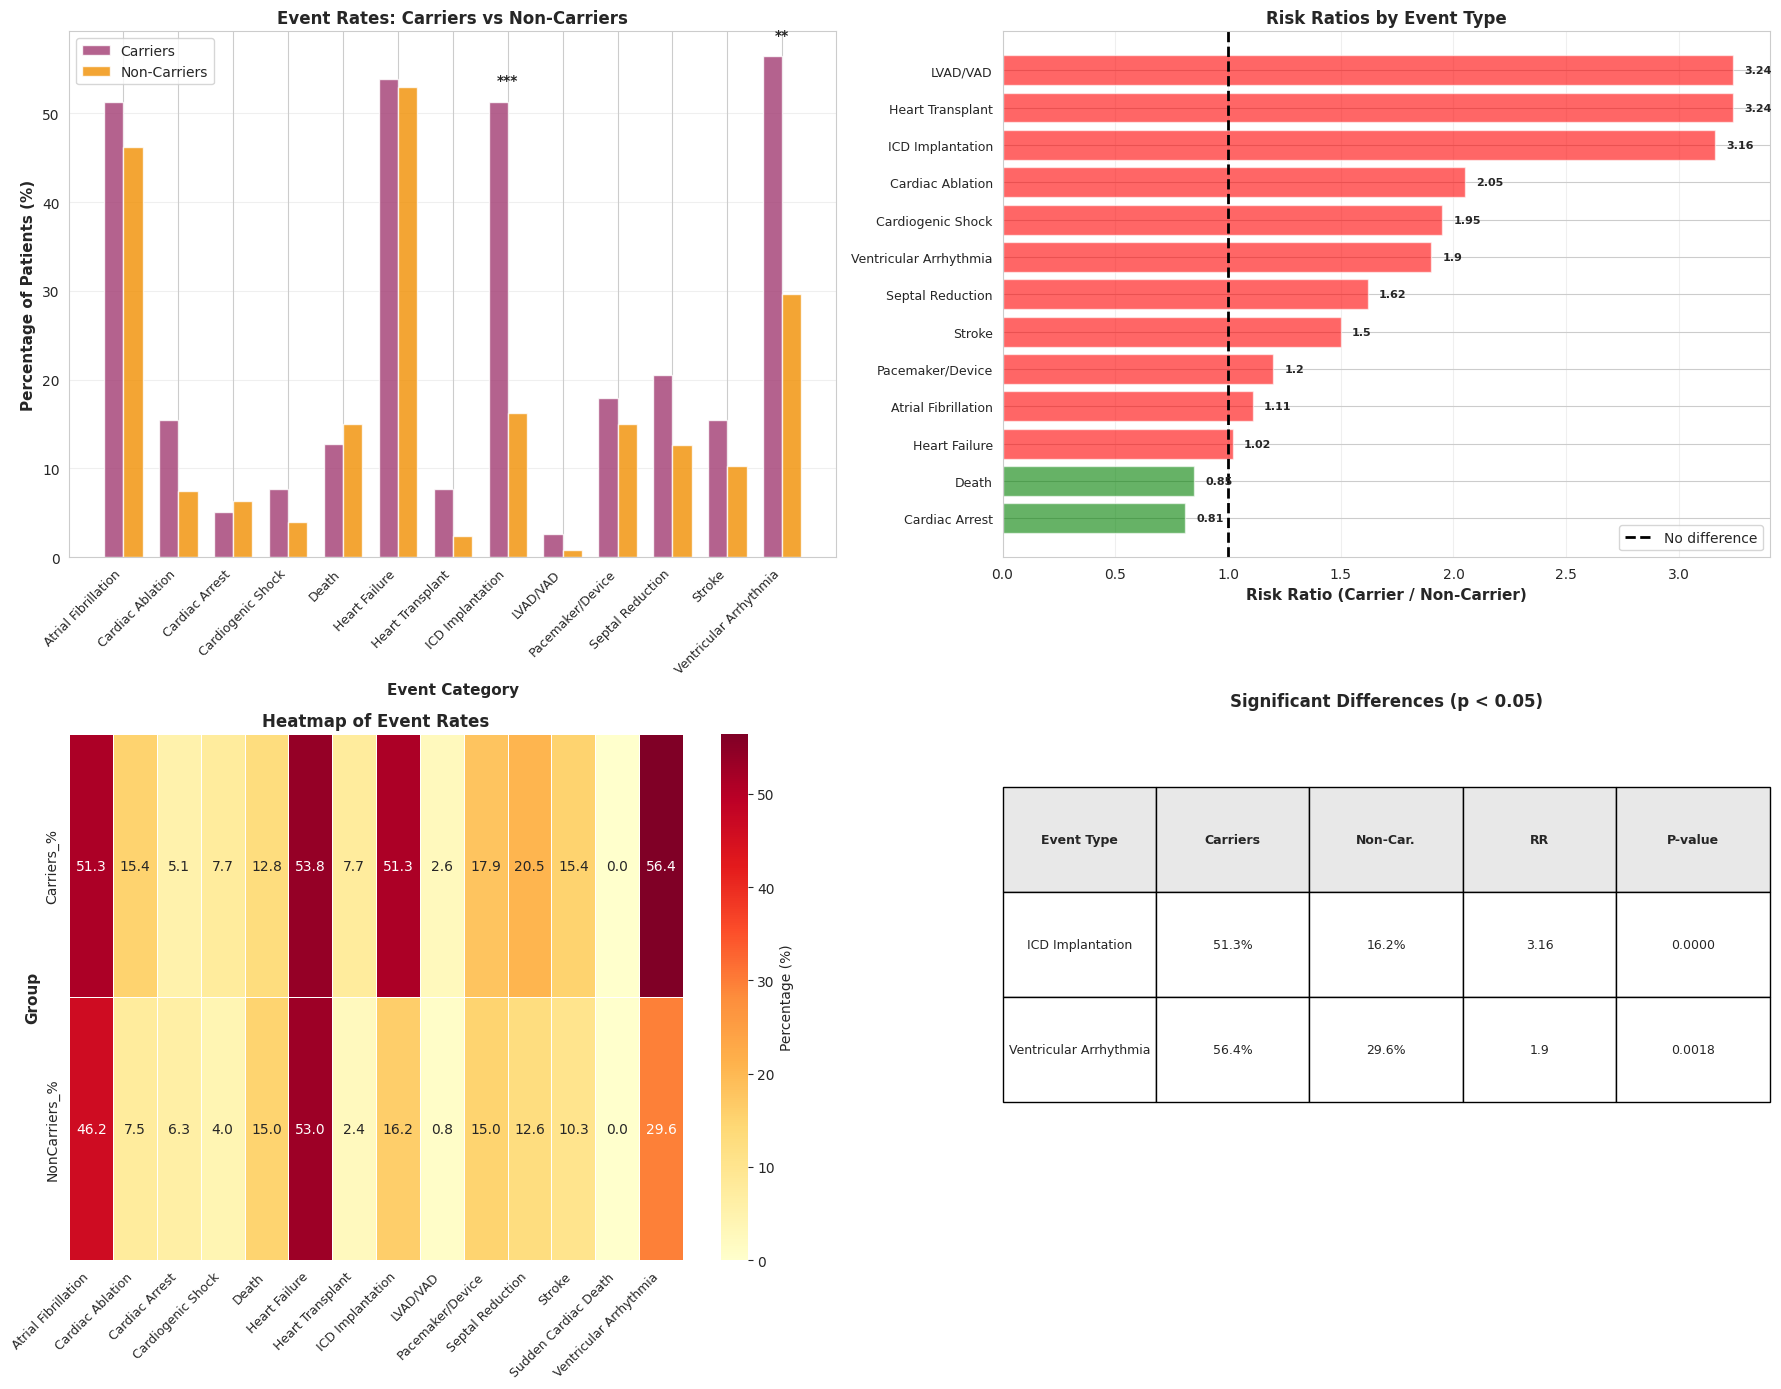


 COHORT SIZES:
  Carriers: 39
  Non-Carriers: 253

 SIGNIFICANT DIFFERENCES (p < 0.05):

  ICD Implantation:
    Carriers: 51.3% (20/39)
    Non-Carriers: 16.2% (41/253)
    Risk Ratio: 3.16 (HIGHER in carriers)
    P-value: 0.0 ***

  Ventricular Arrhythmia:
    Carriers: 56.4% (22/39)
    Non-Carriers: 29.6% (75/253)
    Risk Ratio: 1.9 (HIGHER in carriers)
    P-value: 0.0018 **

 TRENDS (not significant but notable, RR > 1.5 or < 0.67):

  Cardiac Ablation:
    Carriers: 15.4%, Non-Carriers: 7.5%
    Risk Ratio: 2.05 (p=0.1207)

  Cardiogenic Shock:
    Carriers: 7.7%, Non-Carriers: 4.0%
    Risk Ratio: 1.95 (p=0.3927)

  Heart Transplant:
    Carriers: 7.7%, Non-Carriers: 2.4%
    Risk Ratio: 3.24 (p=0.1045)

  LVAD/VAD:
    Carriers: 2.6%, Non-Carriers: 0.8%
    Risk Ratio: 3.24 (p=0.3506)

  Septal Reduction:
    Carriers: 20.5%, Non-Carriers: 12.6%
    Risk Ratio: 1.62 (p=0.2804)


/var/tmp/ipykernel_5108/3656248458.py:286: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trends['RR_num'] = pd.to_numeric(trends['Risk_Ratio'], errors='coerce')


In [30]:

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STEP 1: GET EVENT COUNTS BY CATEGORY AND CARRIER STATUS
# ============================================================================

print("QUERYING EVENT COUNTS BY CARRIER STATUS")

query_events_by_carrier = f"""
SELECT 
    is_carrier,
    event_category,
    COUNT(DISTINCT person_id) as patients_with_event,
    COUNT(*) as total_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_all_composite_events`
WHERE event_category IS NOT NULL 
  AND event_category != 'None'
GROUP BY is_carrier, event_category
ORDER BY is_carrier, event_category
"""

print("\n Querying event counts by carrier status...")
df_events_by_carrier = client.query(query_events_by_carrier).to_dataframe()

print("\n Results:")
print(df_events_by_carrier.to_string(index=False))

# ============================================================================
# GET TOTAL COHORT SIZES
# ============================================================================

print("STEP 2: COHORT SIZES")

n_carriers = len(df_hcm_carriers_clean)
n_noncarriers = len(df_hcm_noncarriers_clean)

print(f"\nCarriers: {n_carriers}")
print(f"Non-Carriers: {n_noncarriers}")

# ============================================================================
# STEP 3: CALCULATE RATES AND COMPARE
# ============================================================================

print("STEP 3: EVENT RATES BY CATEGORY")

# Convert is_carrier boolean to labels
df_events_by_carrier['carrier_status'] = df_events_by_carrier['is_carrier'].map({True: 'Carrier', False: 'Non-Carrier'})

# Pivot the data for easier analysis
df_pivot = df_events_by_carrier.pivot_table(
    index='event_category',
    columns='carrier_status',
    values='patients_with_event',
    fill_value=0
).reset_index()

print("\n Pivot table:")
print(df_pivot)

# Calculate rates and statistics
event_comparison = []

event_categories = [
    'Atrial Fibrillation',
    'Cardiac Ablation', 
    'Cardiac Arrest',
    'Cardiogenic Shock',
    'Death',
    'Heart Failure',
    'Heart Transplant',
    'ICD Implantation',
    'LVAD/VAD',
    'Pacemaker/Device',
    'Septal Reduction',
    'Stroke',
    'Sudden Cardiac Death',
    'Ventricular Arrhythmia'
]

for event_cat in event_categories:
    
    if event_cat in df_pivot['event_category'].values:
        row = df_pivot[df_pivot['event_category'] == event_cat]
        
        carriers_n = row['Carrier'].values[0] if 'Carrier' in df_pivot.columns else 0
        noncarriers_n = row['Non-Carrier'].values[0] if 'Non-Carrier' in df_pivot.columns else 0
    else:
        carriers_n = 0
        noncarriers_n = 0
    
    carriers_rate = 100 * carriers_n / n_carriers
    noncarriers_rate = 100 * noncarriers_n / n_noncarriers
    
    # Risk ratio
    if noncarriers_rate > 0:
        rr = carriers_rate / noncarriers_rate
    else:
        rr = np.inf if carriers_rate > 0 else np.nan
    
    # Statistical test (Fisher's exact for small counts, Chi-square otherwise)
    contingency = np.array([
        [carriers_n, n_carriers - carriers_n],
        [noncarriers_n, n_noncarriers - noncarriers_n]
    ])
    
    # Use Fisher's exact if any expected count < 5
    expected = (carriers_n + noncarriers_n) * np.array([n_carriers, n_noncarriers]) / (n_carriers + n_noncarriers)
    
    if np.any(expected < 5) or carriers_n + noncarriers_n < 10:
        _, p_val = fisher_exact(contingency)
        test_used = "Fisher"
    else:
        chi2, p_val, dof, exp = chi2_contingency(contingency)
        test_used = "Chi-sq"
    
    event_comparison.append({
        'Event_Category': event_cat,
        'Carriers_N': int(carriers_n),
        'Carriers_%': round(carriers_rate, 1),
        'NonCarriers_N': int(noncarriers_n),
        'NonCarriers_%': round(noncarriers_rate, 1),
        'Risk_Ratio': round(rr, 2) if not np.isnan(rr) and not np.isinf(rr) else 'N/A',
        'P_value': round(p_val, 4) if not np.isnan(p_val) else 'N/A',
        'Test': test_used,
        'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    })

df_event_comparison = pd.DataFrame(event_comparison)

# Sort by p-value
df_event_comparison_sorted = df_event_comparison.copy()
df_event_comparison_sorted['P_value_numeric'] = pd.to_numeric(df_event_comparison_sorted['P_value'], errors='coerce')
df_event_comparison_sorted = df_event_comparison_sorted.sort_values('P_value_numeric')

print("\n EVENT-SPECIFIC COMPARISON (sorted by p-value):")
print(f"{'Event Category':<25} {'Carriers':<12} {'Non-Carriers':<15} {'RR':<8} {'P-value':<10} {'Sig':<5}")
print(f"{'':25} {'N (%)':12} {'N (%)':15} {'':8} {'':10} {'':5}")

for _, row in df_event_comparison_sorted.iterrows():
    print(f"{row['Event_Category']:<25} "
          f"{row['Carriers_N']:>3} ({row['Carriers_%']:>5.1f}%)  "
          f"{row['NonCarriers_N']:>3} ({row['NonCarriers_%']:>5.1f}%)   "
          f"{str(row['Risk_Ratio']):>6}  "
          f"{str(row['P_value']):>8}  "
          f"{row['Significant']:>3}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")

# ============================================================================
# VISUALIZE THE COMPARISON
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Event rates comparison (bar chart)
ax1 = axes[0, 0]
df_plot = df_event_comparison.copy()
df_plot = df_plot[(df_plot['Carriers_N'] + df_plot['NonCarriers_N']) > 0]  # Only events that occurred

x = np.arange(len(df_plot))
width = 0.35

bars1 = ax1.bar(x - width/2, df_plot['Carriers_%'], width, label='Carriers', color='#A23B72', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_plot['NonCarriers_%'], width, label='Non-Carriers', color='#F18F01', alpha=0.8)

ax1.set_xlabel('Event Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Percentage of Patients (%)', fontsize=11, fontweight='bold')
ax1.set_title('Event Rates: Carriers vs Non-Carriers', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot['Event_Category'], rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add significance stars
for i, (idx, row) in enumerate(df_plot.iterrows()):
    if row['Significant']:
        max_height = max(row['Carriers_%'], row['NonCarriers_%'])
        ax1.text(i, max_height + 2, row['Significant'], ha='center', fontsize=10, fontweight='bold')

# Plot 2: Risk ratios (forest plot style)
ax2 = axes[0, 1]
df_plot_rr = df_event_comparison.copy()
df_plot_rr = df_plot_rr[df_plot_rr['Risk_Ratio'] != 'N/A']
df_plot_rr['Risk_Ratio_num'] = pd.to_numeric(df_plot_rr['Risk_Ratio'])
df_plot_rr = df_plot_rr.sort_values('Risk_Ratio_num')

y_pos = np.arange(len(df_plot_rr))
colors = ['red' if rr > 1 else 'green' for rr in df_plot_rr['Risk_Ratio_num']]

ax2.barh(y_pos, df_plot_rr['Risk_Ratio_num'], color=colors, alpha=0.6)
ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No difference')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_plot_rr['Event_Category'], fontsize=9)
ax2.set_xlabel('Risk Ratio (Carrier / Non-Carrier)', fontsize=11, fontweight='bold')
ax2.set_title('Risk Ratios by Event Type', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

# Add RR values on bars
for i, (idx, row) in enumerate(df_plot_rr.iterrows()):
    ax2.text(row['Risk_Ratio_num'] + 0.05, i, f"{row['Risk_Ratio']}", 
            va='center', fontsize=8, fontweight='bold')

# Plot 3: Heatmap of event rates
ax3 = axes[1, 0]
heatmap_data = df_event_comparison[['Event_Category', 'Carriers_%', 'NonCarriers_%']].set_index('Event_Category')
heatmap_data = heatmap_data.T

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax3, 
           cbar_kws={'label': 'Percentage (%)'}, linewidths=0.5)
ax3.set_title('Heatmap of Event Rates', fontsize=12, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Group', fontsize=11, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Plot 4: Summary table of significant findings
ax4 = axes[1, 1]
ax4.axis('off')

sig_findings = df_event_comparison_sorted[df_event_comparison_sorted['Significant'] != '']

if len(sig_findings) > 0:
    table_data = []
    for _, row in sig_findings.iterrows():
        table_data.append([
            row['Event_Category'],
            f"{row['Carriers_%']:.1f}%",
            f"{row['NonCarriers_%']:.1f}%",
            str(row['Risk_Ratio']),
            f"{row['P_value']:.4f}"
        ])
    
    table = ax4.table(cellText=table_data,
                     colLabels=['Event Type', 'Carriers', 'Non-Car.', 'RR', 'P-value'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0.3, 1, 0.6])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.5)
    
    for i in range(5):
        table[(0, i)].set_facecolor('#E8E8E8')
        table[(0, i)].set_text_props(weight='bold')
    
    ax4.set_title('Significant Differences (p < 0.05)', fontsize=12, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No Significant Differences Found\n(p < 0.05)', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax4.set_title('Significant Differences', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('event_category_specific_analysis.png', dpi=300, bbox_inches='tight')
print("\n Visualization saved as 'event_category_specific_analysis.png'")
plt.show()

# ============================================================================
#  SUMMARY AND INTERPRETATION
# ============================================================================

print(f"\n COHORT SIZES:")
print(f"  Carriers: {n_carriers}")
print(f"  Non-Carriers: {n_noncarriers}")

print(f"\n SIGNIFICANT DIFFERENCES (p < 0.05):")
if len(sig_findings) > 0:
    for _, row in sig_findings.iterrows():
        direction = "HIGHER" if pd.to_numeric(row['Risk_Ratio']) > 1 else "LOWER"
        print(f"\n  {row['Event_Category']}:")
        print(f"    Carriers: {row['Carriers_%']}% ({row['Carriers_N']}/{n_carriers})")
        print(f"    Non-Carriers: {row['NonCarriers_%']}% ({row['NonCarriers_N']}/{n_noncarriers})")
        print(f"    Risk Ratio: {row['Risk_Ratio']} ({direction} in carriers)")
        print(f"    P-value: {row['P_value']} {row['Significant']}")
else:
    print("  None - No event types show significant differences between carriers and non-carriers")

print(f"\n TRENDS (not significant but notable, RR > 1.5 or < 0.67):")
trends = df_event_comparison[(df_event_comparison['Significant'] == '') & 
                            (df_event_comparison['Risk_Ratio'] != 'N/A')]
trends['RR_num'] = pd.to_numeric(trends['Risk_Ratio'], errors='coerce')
notable_trends = trends[(trends['RR_num'] > 1.5) | (trends['RR_num'] < 0.67)]

if len(notable_trends) > 0:
    for _, row in notable_trends.iterrows():
        print(f"\n  {row['Event_Category']}:")
        print(f"    Carriers: {row['Carriers_%']}%, Non-Carriers: {row['NonCarriers_%']}%")
        print(f"    Risk Ratio: {row['Risk_Ratio']} (p={row['P_value']})")
else:
    print("  No notable trends identified")